# Student Annotation Analysis

Analyzing 3 student annotator sets across 8 GEO papers (excluding GSE130339, GSE155750)

In [50]:
# Cell 1: Load + normalize student data
import pandas as pd
import numpy as np
import re
from collections import Counter

STUDENT_FILE = "manual_review_annotated.xlsx"
EXCLUDE_GEO = {"GSE130339", "GSE155750"}

QUESTION_COLS = {
    4:  "Supervisor/Contact/Corresponding author name",
    5:  "Supervisor/Contact/Corresponding author email",
    6:  "Main topic of the publication",
    7:  "Pregnancy trimester (1st, 2nd, 3rd, term, premature)",
    8:  "Birthweight of offspring provided (yes/no)",
    9:  "Gestational Age at delivery provided (yes/no)",
    10: "GA at delivery (weeks)",
    11: "Gestational Age at sample collection provided (yes/no)",
    12: "GA at sample collection (weeks)",
    13: "Sex of Offspring Provided (yes/no)",
    14: "Parity provided (yes/no)",
    15: "Gravidity provided (yes/no)",
    16: "Number of offspring per pregnancy provided (yes/no)",
    17: "Self-reported race/ethnicity of mother provided (yes/no)",
    18: "Genetic ancestry or genetic strain provided (yes/no)",
    19: "Maternal Height provided (yes/no)",
    20: "Maternal Pre-pregnancy Weight provided (yes/no)",
    21: "Paternal Height provided (yes/no)",
    22: "Paternal Weight provided (yes/no)",
    23: "Maternal age at sample collection provided (yes/no)",
    24: "Paternal age at sample collection provided (yes/no)",
    25: "Samples from pregnancy complications collected",
    26: "Mode of delivery provided (yes/no)",
    27: "Pregnancy complications in data set (list)",
    28: "Fetal complications listed (yes/no)",
    29: "Fetal complications in data set (list)",
    30: "Other Phenotypes Provided (list)",
    31: "Hospital/Center where samples were collected",
    32: "Country where samples were collected",
}

YESNO_QUESTIONS = [
    "Birthweight of offspring provided (yes/no)",
    "Gestational Age at delivery provided (yes/no)",
    "Gestational Age at sample collection provided (yes/no)",
    "Sex of Offspring Provided (yes/no)",
    "Parity provided (yes/no)",
    "Gravidity provided (yes/no)",
    "Number of offspring per pregnancy provided (yes/no)",
    "Self-reported race/ethnicity of mother provided (yes/no)",
    "Genetic ancestry or genetic strain provided (yes/no)",
    "Maternal Height provided (yes/no)",
    "Maternal Pre-pregnancy Weight provided (yes/no)",
    "Paternal Height provided (yes/no)",
    "Paternal Weight provided (yes/no)",
    "Maternal age at sample collection provided (yes/no)",
    "Paternal age at sample collection provided (yes/no)",
    "Samples from pregnancy complications collected",
    "Mode of delivery provided (yes/no)",
    "Fetal complications listed (yes/no)",
]
GA_QUESTIONS = ["GA at delivery (weeks)", "GA at sample collection (weeks)"]
LIST_QUESTIONS = ["Pregnancy complications in data set (list)", "Fetal complications in data set (list)", "Other Phenotypes Provided (list)"]
TRIMESTER_QUESTION = "Pregnancy trimester (1st, 2nd, 3rd, term, premature)"
COUNTRY_QUESTION = "Country where samples were collected"

# --- Normalizers ---
def norm_yesno(val):
    s = str(val).strip().lower()
    if s in {"nan", "none", "", "n/a", "not provided", "na"}: return "No"
    if any(w in s for w in ["yes", "true", "provided", "reported"]): return "Yes"
    if s == "no": return "No"
    if len(s) > 3 and s not in {"false", "none", "n/a"}: return "Yes"
    return "No"

COUNTRY_ALIASES = {"usa": "USA", "united states": "USA", "us": "USA", "u.s.": "USA",
    "america": "USA", "uk": "UK", "united kingdom": "UK", "belgium": "Belgium",
    "belgian": "Belgium", "canada": "Canada", "pakistan": "Pakistan", "hungary": "Hungary"}

def norm_country(val):
    s = str(val).strip()
    if s.lower() in {"nan", "none", "", "n/a", "not provided", "na"}: return "Not Provided"
    return COUNTRY_ALIASES.get(s.lower(), s.title())

TRIMESTER_MAP = {"1st": {"1","1st","first","first trimester"}, "2nd": {"2","2nd","second","second trimester"},
    "3rd": {"3","3rd","third","third trimester"}, "Term": {"term","full-term","full term","at term"},
    "Premature": {"premature","preterm","pre-term","ptb"}}

def norm_trimester_single(s):
    s = s.strip().lower()
    for canon, variants in TRIMESTER_MAP.items():
        if s in variants: return canon
    if "1" in s or "first" in s: return "1st"
    if "2" in s or "second" in s: return "2nd"
    if "3" in s or "third" in s: return "3rd"
    if "term" in s and "pre" not in s: return "Term"
    if "pre" in s or "premature" in s: return "Premature"
    return None

def norm_trimester(val):
    s = str(val).strip()
    if s.lower() in {"nan","none","","n/a","not provided","na"}: return "Not Provided"
    tokens = re.split(r"[,/]+|\band\b", s.lower())
    results = [norm_trimester_single(t.strip()) for t in tokens if t.strip()]
    results = [r for r in results if r]
    return ", ".join(sorted(set(results))) if results else "Not Provided"

def norm_ga(val):
    s = str(val).strip()
    if s.lower() in {"nan","none","","n/a","not provided","na","no"}: return "Not Provided"
    nums = re.findall(r"\d+\.?\d*", s)
    return round(np.mean([float(n) for n in nums]), 1) if nums else "Not Provided"

def norm_list(val):
    s = str(val).strip()
    if s.lower() in {"nan","none","","n/a","not provided","na","no","[]"}: return []
    items = re.split(r"[;,\n]+", s)
    return sorted(set(i.strip().lower() for i in items if i.strip().lower() not in {"nan","none","n/a","na",""}))

def norm_freetext(val):
    s = str(val).strip()
    if s.lower() in {"nan","none","","n/a","not provided","na","unknown"}: return "Not Provided"
    return s

def normalize_answer(question, val):
    if question in YESNO_QUESTIONS: return norm_yesno(val)
    elif question == TRIMESTER_QUESTION: return norm_trimester(val)
    elif question in GA_QUESTIONS: return norm_ga(val)
    elif question in LIST_QUESTIONS: return norm_list(val)
    elif question == COUNTRY_QUESTION: return norm_country(val)
    else: return norm_freetext(val)

# --- Load ---
student_sets = {}  # raw
student_normalized = {}  # normalized
for sheet in ["Set1", "Set2", "Set3"]:
    df = pd.read_excel(STUDENT_FILE, sheet_name=sheet, header=None)
    raw_records = {}
    norm_records = {}
    for row_idx in range(2, df.shape[0]):
        geo_id = str(df.iloc[row_idx, 0]).strip()
        if geo_id in EXCLUDE_GEO: continue
        raw_ans = {}
        norm_ans = {}
        for col_idx, q_name in QUESTION_COLS.items():
            val = df.iloc[row_idx, col_idx]
            raw_ans[q_name] = val
            norm_ans[q_name] = normalize_answer(q_name, val)
        raw_records[geo_id] = raw_ans
        norm_records[geo_id] = norm_ans
    student_sets[sheet] = raw_records
    student_normalized[sheet] = norm_records
    print(f"{sheet}: {len(raw_records)} papers")

PAPERS = sorted(set.intersection(*[set(s.keys()) for s in student_sets.values()]))
print(f"\nWorking with {len(PAPERS)} papers: {PAPERS}")

Set1: 8 papers
Set2: 8 papers
Set3: 8 papers

Working with 8 papers: ['GSE128381', 'GSE131729', 'GSE145357', 'GSE154829', 'GSE215421', 'GSE220877', 'GSE234729', 'GSE98224']


In [2]:
# Cell 2: Per-question agreement table (Yes/No only)

rows = []
for q in YESNO_QUESTIONS:
    short_q = q.replace(" provided (yes/no)", "").replace(" (yes/no)", "")
    unanimous = 0
    majority = 0
    disagree_papers = []
    
    for geo_id in PAPERS:
        vals = [student_normalized[sn][geo_id][q] for sn in ["Set1", "Set2", "Set3"]]
        if len(set(vals)) == 1:
            unanimous += 1
            majority += 1
        elif Counter(vals).most_common(1)[0][1] >= 2:
            majority += 1
            # Find who disagrees
            maj_val = Counter(vals).most_common(1)[0][0]
            outliers = [sn for sn, v in zip(["S1","S2","S3"], vals) if v != maj_val]
            disagree_papers.append(f"{geo_id} ({','.join(outliers)} differs)")
        else:
            disagree_papers.append(f"{geo_id} (3-way split)")
    
    rows.append({
        "Question": short_q,
        "Unanimous (3/3)": f"{unanimous}/{len(PAPERS)}",
        "Majority (2/3+)": f"{majority}/{len(PAPERS)}",
        "Agreement %": f"{100*unanimous/len(PAPERS):.0f}%",
        "Disagreement Details": "; ".join(disagree_papers) if disagree_papers else "None",
    })

q_table = pd.DataFrame(rows)
q_table = q_table.sort_values("Agreement %").reset_index(drop=True)

print("PER-QUESTION AGREEMENT TABLE (Yes/No questions, sorted hardest first)")
print()
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
display(q_table)

PER-QUESTION AGREEMENT TABLE (Yes/No questions, sorted hardest first)



,Question,Unanimous (3/3),Majority (2/3+),Agreement %,Disagreement Details
0,Paternal Weight,8/8,8/8,100%,None
1,Paternal Height,8/8,8/8,100%,None
2,Maternal age at sample collection,4/8,8/8,50%,GSE145357 (S3 differs); GSE215421 (S2 differs); GSE234729 (S1 differs); GSE9...
3,Number of offspring per pregnancy,4/8,8/8,50%,GSE145357 (S1 differs); GSE154829 (S2 differs); GSE215421 (S1 differs); GSE2...
4,Maternal Pre-pregnancy Weight,4/8,8/8,50%,GSE131729 (S2 differs); GSE145357 (S2 differs); GSE154829 (S3 differs); GSE2...
5,Fetal complications listed,5/8,8/8,62%,GSE145357 (S2 differs); GSE220877 (S2 differs); GSE98224 (S2 differs)
6,Gestational Age at delivery,5/8,8/8,62%,GSE128381 (S1 differs); GSE131729 (S3 differs); GSE220877 (S3 differs)
7,Gestational Age at sample collection,5/8,8/8,62%,GSE128381 (S3 differs); GSE220877 (S3 differs); GSE234729 (S1 differs)
8,Samples from pregnancy complications collected,5/8,8/8,62%,GSE128381 (S3 differs); GSE154829 (S2 differs); GSE220877 (S3 differs)
9,Parity,5/8,8/8,62%,GSE131729 (S1 differs); GSE145357 (S3 differs); GSE98224 (S1 differs)


In [ ]:
# Cell 3: Per-paper agreement table (Yes/No only)

rows = []
for geo_id in PAPERS:
    unanimous = 0
    majority = 0
    disagree_qs = []
    
    for q in YESNO_QUESTIONS:
        vals = [student_normalized[sn][geo_id][q] for sn in ["Set1", "Set2", "Set3"]]
        if len(set(vals)) == 1:
            unanimous += 1
            majority += 1
        elif Counter(vals).most_common(1)[0][1] >= 2:
            majority += 1
            short_q = q.replace(" provided (yes/no)", "").replace(" (yes/no)", "")[:35]
            disagree_qs.append(short_q)
        else:
            short_q = q.replace(" provided (yes/no)", "").replace(" (yes/no)", "")[:35]
            disagree_qs.append(f"{short_q} (3-way)")
    
    rows.append({
        "GEO ID": geo_id,
        "Unanimous (3/3)": f"{unanimous}/{len(YESNO_QUESTIONS)}",
        "Majority (2/3+)": f"{majority}/{len(YESNO_QUESTIONS)}",
        "Agreement %": f"{100*unanimous/len(YESNO_QUESTIONS):.0f}%",
        "Questions with Disagreement": "; ".join(disagree_qs) if disagree_qs else "None",
    })

p_table = pd.DataFrame(rows)
p_table = p_table.sort_values("Agreement %").reset_index(drop=True)

print("PER-PAPER AGREEMENT TABLE (Yes/No questions, sorted hardest first)")
print()
display(p_table)

In [ ]:
# Cell 4: Non-yes/no fields — raw answers comparison table

NON_YESNO = [TRIMESTER_QUESTION, COUNTRY_QUESTION] + GA_QUESTIONS + LIST_QUESTIONS + [
    "Supervisor/Contact/Corresponding author name",
    "Supervisor/Contact/Corresponding author email",
    "Hospital/Center where samples were collected",
]

rows = []
for geo_id in PAPERS:
    for q in NON_YESNO:
        raw_vals = []
        norm_vals = []
        for sn in ["Set1", "Set2", "Set3"]:
            rv = str(student_sets[sn][geo_id][q]).strip()
            raw_vals.append(rv if rv not in {"nan", ""} else "-")
            norm_vals.append(str(student_normalized[sn][geo_id][q]))
        
        all_same = len(set(norm_vals)) == 1
        
        short_q = q.replace(" (1st, 2nd, 3rd, term, premature)", "")
        short_q = short_q.replace(" in data set (list)", " (list)")
        short_q = short_q.replace("Supervisor/Contact/Corresponding author ", "Author ")
        short_q = short_q.replace("Hospital/Center where samples were collected", "Hospital")
        short_q = short_q.replace("Country where samples were collected", "Country")
        
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "Set1 (raw)": raw_vals[0][:60],
            "Set2 (raw)": raw_vals[1][:60],
            "Set3 (raw)": raw_vals[2][:60],
            "Agree?": "Yes" if all_same else "NO",
        })

raw_table = pd.DataFrame(rows)

print("NON-YES/NO FIELDS — All Answers (raw)")
print(f"Total: {len(raw_table)} rows, {(raw_table['Agree?'] == 'NO').sum()} disagreements")
print()
pd.set_option('display.max_colwidth', 65)
display(raw_table)

In [3]:
# Cell 5: Show ONLY the disagreements for non-yes/no fields

disagree_only = raw_table[raw_table["Agree?"] == "NO"].reset_index(drop=True)

print(f"NON-YES/NO DISAGREEMENTS ONLY ({len(disagree_only)} rows)")
print()
display(disagree_only)

NameError: name 'raw_table' is not defined

## Chapter 2: Why Do Students Disagree?

For every yes/no disagreement, we look at what each student actually wrote (raw) to understand the cause.

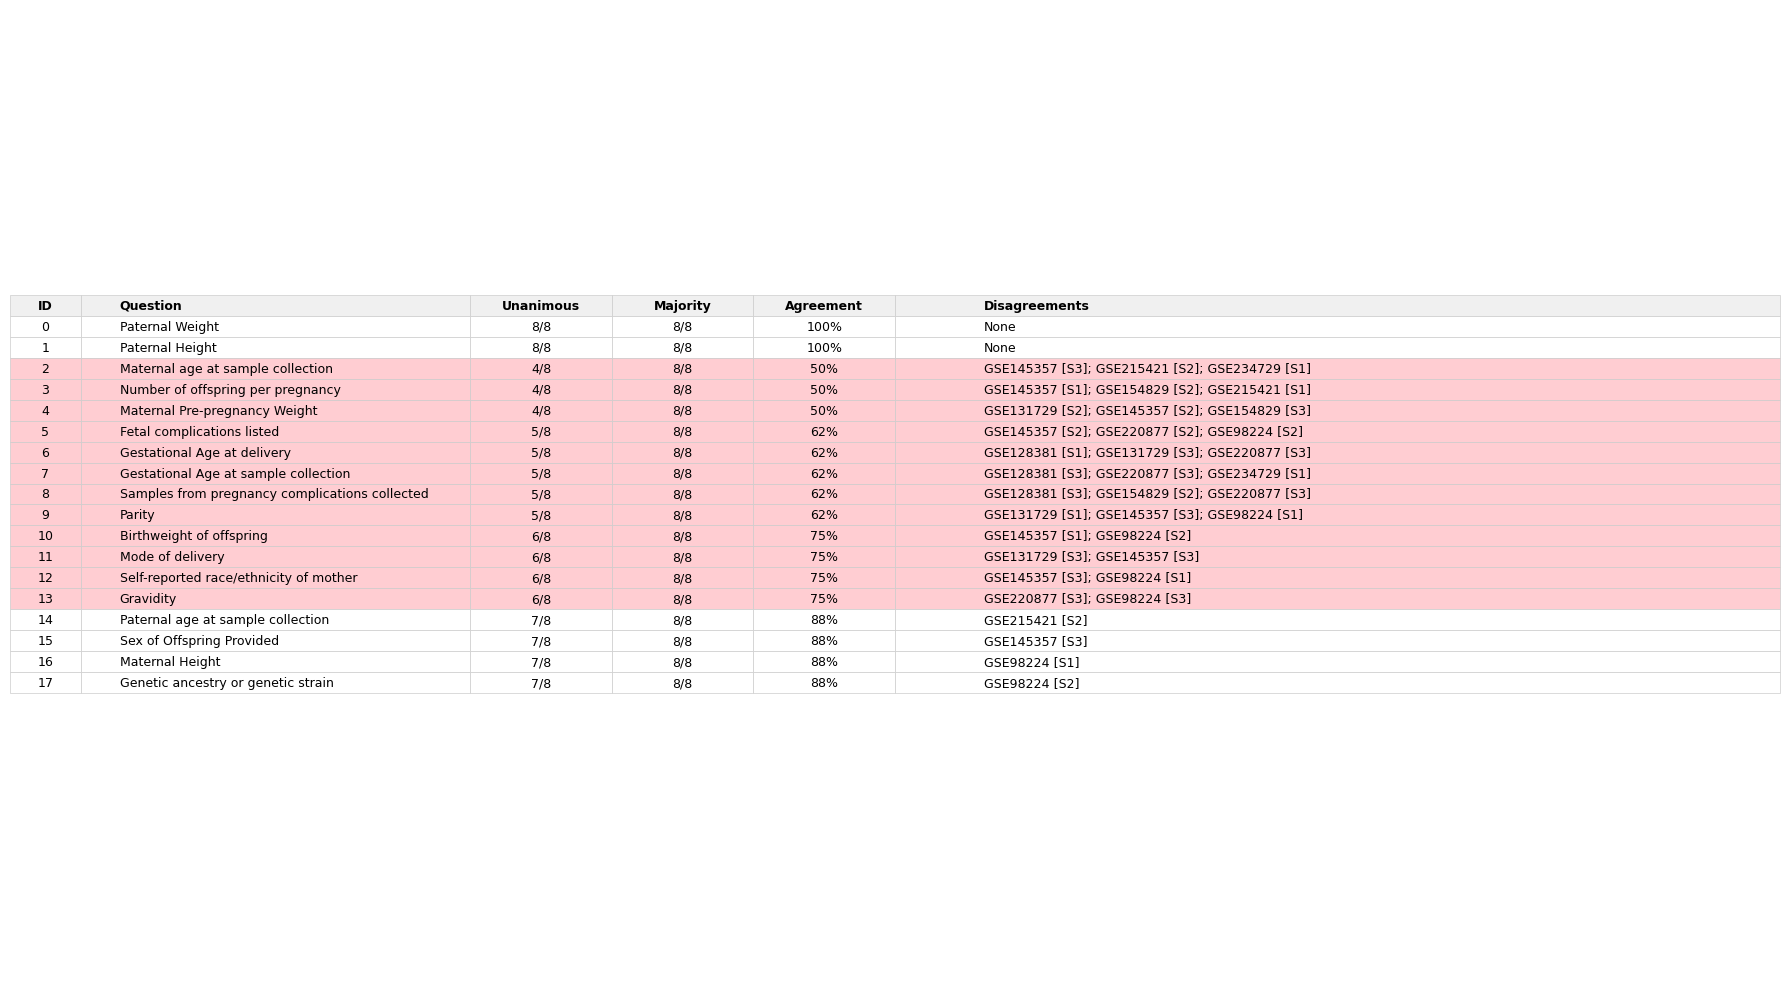

Saved as table.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    [0, "Paternal Weight", "8/8", "8/8", "100%", "None"],
    [1, "Paternal Height", "8/8", "8/8", "100%", "None"],
    [2, "Maternal age at sample collection", "4/8", "8/8", "50%", "GSE145357 [S3]; GSE215421 [S2]; GSE234729 [S1]"],
    [3, "Number of offspring per pregnancy", "4/8", "8/8", "50%", "GSE145357 [S1]; GSE154829 [S2]; GSE215421 [S1]"],
    [4, "Maternal Pre-pregnancy Weight", "4/8", "8/8", "50%", "GSE131729 [S2]; GSE145357 [S2]; GSE154829 [S3]"],
    [5, "Fetal complications listed", "5/8", "8/8", "62%", "GSE145357 [S2]; GSE220877 [S2]; GSE98224 [S2]"],
    [6, "Gestational Age at delivery", "5/8", "8/8", "62%", "GSE128381 [S1]; GSE131729 [S3]; GSE220877 [S3]"],
    [7, "Gestational Age at sample collection", "5/8", "8/8", "62%", "GSE128381 [S3]; GSE220877 [S3]; GSE234729 [S1]"],
    [8, "Samples from pregnancy complications collected", "5/8", "8/8", "62%", "GSE128381 [S3]; GSE154829 [S2]; GSE220877 [S3]"],
    [9, "Parity", "5/8", "8/8", "62%", "GSE131729 [S1]; GSE145357 [S3]; GSE98224 [S1]"],
    [10, "Birthweight of offspring", "6/8", "8/8", "75%", "GSE145357 [S1]; GSE98224 [S2]"],
    [11, "Mode of delivery", "6/8", "8/8", "75%", "GSE131729 [S3]; GSE145357 [S3]"],
    [12, "Self-reported race/ethnicity of mother", "6/8", "8/8", "75%", "GSE145357 [S3]; GSE98224 [S1]"],
    [13, "Gravidity", "6/8", "8/8", "75%", "GSE220877 [S3]; GSE98224 [S3]"],
    [14, "Paternal age at sample collection", "7/8", "8/8", "88%", "GSE215421 [S2]"],
    [15, "Sex of Offspring Provided", "7/8", "8/8", "88%", "GSE145357 [S3]"],
    [16, "Maternal Height", "7/8", "8/8", "88%", "GSE98224 [S1]"],
    [17, "Genetic ancestry or genetic strain", "7/8", "8/8", "88%", "GSE98224 [S2]"],
]

df = pd.DataFrame(data, columns=["ID", "Question", "Unanimous", "Majority", "Agreement", "Disagreements"])

col_widths = [0.04, 0.22, 0.08, 0.08, 0.08, 0.50]
headers = ["ID", "Question", "Unanimous", "Majority", "Agreement", "Disagreements"]

fig, ax = plt.subplots(figsize=(18, 10))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=headers,
    cellLoc="center",
    loc="center",
    colWidths=col_widths,
)

table.auto_set_font_size(False)
table.set_fontsize(9)

red_rows = {"50%", "62%", "75%"}

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#cccccc")
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold", color="black")
    else:
        agreement_val = df.iloc[row - 1]["Agreement"]
        if agreement_val in red_rows:
            cell.set_facecolor("#ffcdd2")
        else:
            cell.set_facecolor("white")
        cell.set_text_props(color="black")

    if col in [1, 5]:
        cell.set_text_props(ha="left")
        cell._loc = "left"

plt.tight_layout()
plt.savefig("table.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved as table.png")

In [ ]:
# Chapter 2: Every yes/no disagreement — raw answers + who is the outlier
import matplotlib.pyplot as plt

rows = []
for geo_id in PAPERS:
    for q in YESNO_QUESTIONS:
        vals = [student_normalized[sn][geo_id][q] for sn in ["Set1", "Set2", "Set3"]]
        if len(set(vals)) == 1:
            continue  # all agree, skip
        
        raw_vals = []
        for sn in ["Set1", "Set2", "Set3"]:
            rv = str(student_sets[sn][geo_id][q]).strip()
            raw_vals.append(rv if rv not in {"nan", ""} else "-")
        
        # Who is the outlier?
        c = Counter(vals)
        if c.most_common(1)[0][1] >= 2:
            majority_val = c.most_common(1)[0][0]
            outlier = [f"S{i+1}" for i, v in enumerate(vals) if v != majority_val]
            split_type = "2 vs 1"
        else:
            outlier = ["all differ"]
            majority_val = "?"
            split_type = "3-way"
        
        short_q = q.replace(" provided (yes/no)", "").replace(" (yes/no)", "")
        
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "S1 raw": raw_vals[0][:20],
            "S2 raw": raw_vals[1][:20],
            "S3 raw": raw_vals[2][:20],
            "S1 norm": vals[0],
            "S2 norm": vals[1],
            "S3 norm": vals[2],
            "Split": split_type,
            "Outlier": ", ".join(outlier),
            "Majority": majority_val,
        })

disagree_df = pd.DataFrame(rows)
print(f"YES/NO DISAGREEMENTS — {len(disagree_df)} total across {len(PAPERS)} papers x {len(YESNO_QUESTIONS)} questions")
print()

pd.set_option('display.max_colwidth', 25)
pd.set_option('display.width', 220)
display(disagree_df)

In [ ]:
# Chapter 2b: Which student is the outlier most often?

outlier_counts = {"S1": 0, "S2": 0, "S3": 0}
for _, row in disagree_df.iterrows():
    for s in ["S1", "S2", "S3"]:
        if s in row["Outlier"]:
            outlier_counts[s] += 1

total_disagree = len(disagree_df)

print("WHO IS THE OUTLIER?")
print("=" * 50)
print(f"\nOut of {total_disagree} yes/no disagreements:\n")
for s, count in sorted(outlier_counts.items(), key=lambda x: -x[1]):
    bar = "*" * count
    print(f"  {s}: {count:2d} times the outlier ({100*count/total_disagree:.0f}%)  {bar}")

# Also: when they're the outlier, do they say Yes or No?
print("\nWhen each student is the outlier, what do they say?")
for s_idx, s_name in enumerate(["S1", "S2", "S3"]):
    yes_out = 0
    no_out = 0
    for _, row in disagree_df.iterrows():
        if s_name in row["Outlier"]:
            if row[f"{s_name} norm"] == "Yes":
                yes_out += 1
            else:
                no_out += 1
    if yes_out + no_out > 0:
        print(f"  {s_name}: says Yes {yes_out}x, says No {no_out}x — {'more thorough (finds data others miss)' if yes_out > no_out else 'more conservative (says No where others say Yes)'}")

---
## Chapter 3: AI Model Analysis

Same analysis as students but for 4 AI models. Where do models agree/disagree with each other?

In [51]:
# Load all 4 AI model results
import json as _json
import os

BENCHMARK_DIR = "benchmark_results"
NEW_MODELS = ["gemini-3.0-flash-preview", "gpt-5.4", "claude-sonnet-4.6"]

model_results = {}

# Load 3 new models
for model_name in NEW_MODELS:
    model_results[model_name] = {}
    model_dir = os.path.join(BENCHMARK_DIR, model_name)
    for geo_id in PAPERS:
        fpath = os.path.join(model_dir, f"{geo_id}.json")
        if os.path.exists(fpath):
            with open(fpath) as f:
                raw = _json.load(f)
            normed = {}
            for q in QUESTION_COLS.values():
                entry = raw.get(q, {})
                raw_ans = entry.get("answer", "Not Provided") if isinstance(entry, dict) else entry
                normed[q] = normalize_answer(q, raw_ans)
            model_results[model_name][geo_id] = normed
    print(f"{model_name}: {len(model_results[model_name])}/8 papers")

# Load old Gemini 2.0 Flash from ai.xlsx
old_ai = pd.read_excel("ai.xlsx")
geo_col = old_ai.columns[1]

AI_COL_MAP = {
    "Supervisor/Contact/Corresponding author name": "Supervisor/Contact/Corresponding author name",
    "Supervisor/Contact/Corresponding author email": "Supervisor/Contact/Corresponding author email",
    "Main topic of the publication": "Main topic of the publication",
    "Pregnancy trimester": "Pregnancy trimester (1st, 2nd, 3rd, term, premature)",
    "Birthweight of offspring provided (yes/no)": "Birthweight of offspring provided (yes/no)",
    "Gestational Age at delivery provided (yes/no)": "Gestational Age at delivery provided (yes/no)",
    "GA at delivery (weeks)": "GA at delivery (weeks)",
    "Gestational Age at sample collection provided (yes/no)": "Gestational Age at sample collection provided (yes/no)",
    "GA at sample collection (weeks)": "GA at sample collection (weeks)",
    "Sex of Offspring Provided (yes/no)": "Sex of Offspring Provided (yes/no)",
    "Parity provided (yes/no)": "Parity provided (yes/no)",
    "Gravidity provided (yes/no)": "Gravidity provided (yes/no)",
    "Number of offspring per pregnancy provided (yes/no)": "Number of offspring per pregnancy provided (yes/no)",
    "Self-reported race/ethnicity of mother provided (yes/no)": "Self-reported race/ethnicity of mother provided (yes/no)",
    "Genetic ancestry or genetic strain provided (yes/no)": "Genetic ancestry or genetic strain provided (yes/no)",
    "Maternal Height provided (yes/no)": "Maternal Height provided (yes/no)",
    "Maternal Pre-pregnancy Weight provided (yes/no)": "Maternal Pre-pregnancy Weight provided (yes/no)",
    "Paternal Height provided (yes/no)": "Paternal Height provided (yes/no)",
    "Paternal Weight provided (yes/no)": "Paternal Weight provided (yes/no)",
    "Maternal age at sample collection provided (yes/no)": "Maternal age at sample collection provided (yes/no)",
    "Paternal age at sample collection provided (yes/no)": "Paternal age at sample collection provided (yes/no)",
    "Samples from pregnancy complications collected": "Samples from pregnancy complications collected",
    "Mode of delivery provided (yes/no)": "Mode of delivery provided (yes/no)",
    "Pregnancy complications in data set (list)": "Pregnancy complications in data set (list)",
    "Fetal complications listed (yes/no)": "Fetal complications listed (yes/no)",
    "Fetal complications in data set (list)": "Fetal complications in data set (list)",
    "Other Phenotypes Provided (list)": "Other Phenotypes Provided (list)",
    "Hospital/Center where samples were collected": "Hospital/Center where samples were collected",
    "Country where samples were collected": "Country where samples were collected",
}

model_results["gemini-2.0-flash"] = {}
for geo_id in PAPERS:
    row = old_ai[old_ai[geo_col].astype(str).str.strip() == geo_id]
    if len(row) == 0: continue
    row = row.iloc[0]
    normed = {}
    for ai_col, q_name in AI_COL_MAP.items():
        if ai_col in old_ai.columns:
            normed[q_name] = normalize_answer(q_name, row[ai_col])
        else:
            normed[q_name] = "Not Provided"
    model_results["gemini-2.0-flash"][geo_id] = normed

print(f"gemini-2.0-flash: {len(model_results['gemini-2.0-flash'])}/8 papers")

ALL_MODELS = ["gemini-2.0-flash", "gemini-3.0-flash-preview", "gpt-5.4", "claude-sonnet-4.6"]
print(f"\nAll models: {ALL_MODELS}")

gemini-3.0-flash-preview: 8/8 papers
gpt-5.4: 8/8 papers
claude-sonnet-4.6: 8/8 papers
gemini-2.0-flash: 8/8 papers

All models: ['gemini-2.0-flash', 'gemini-3.0-flash-preview', 'gpt-5.4', 'claude-sonnet-4.6']


In [52]:
# Chapter 3a: Per-question agreement across AI models

rows = []
for q in YESNO_QUESTIONS:
    short_q = q.replace(" provided (yes/no)", "").replace(" (yes/no)", "")
    unanimous = 0
    majority = 0
    disagree_papers = []
    
    for geo_id in PAPERS:
        vals = [model_results[m][geo_id][q] for m in ALL_MODELS]
        if len(set(vals)) == 1:
            unanimous += 1
            majority += 1
        elif Counter(vals).most_common(1)[0][1] >= 3:
            majority += 1
            maj_val = Counter(vals).most_common(1)[0][0]
            outliers = [m.replace('gemini-','G').replace('claude-sonnet-','C').replace('gpt-','GPT')
                        for m, v in zip(ALL_MODELS, vals) if v != maj_val]
            disagree_papers.append(f"{geo_id} ({','.join(outliers)})")
        elif Counter(vals).most_common(1)[0][1] >= 2:
            majority += 1
            maj_val = Counter(vals).most_common(1)[0][0]
            outliers = [m.replace('gemini-','G').replace('claude-sonnet-','C').replace('gpt-','GPT')
                        for m, v in zip(ALL_MODELS, vals) if v != maj_val]
            disagree_papers.append(f"{geo_id} ({','.join(outliers)})")
        else:
            disagree_papers.append(f"{geo_id} (split)")
    
    rows.append({
        "Question": short_q,
        "All 4 agree": f"{unanimous}/{len(PAPERS)}",
        "3+ agree": f"{majority}/{len(PAPERS)}",
        "Agreement %": f"{100*unanimous/len(PAPERS):.0f}%",
        "Disagreement Details": "; ".join(disagree_papers) if disagree_papers else "None",
    })

ai_q_table = pd.DataFrame(rows)
ai_q_table = ai_q_table.sort_values("Agreement %").reset_index(drop=True)

print("AI MODELS — PER-QUESTION AGREEMENT (Yes/No, sorted hardest first)")
print()
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
display(ai_q_table)

AI MODELS — PER-QUESTION AGREEMENT (Yes/No, sorted hardest first)



,Question,All 4 agree,3+ agree,Agreement %,Disagreement Details
0,Paternal Weight,8/8,8/8,100%,None
1,Paternal Height,8/8,8/8,100%,None
2,Maternal Pre-pregnancy Weight,8/8,8/8,100%,None
3,Maternal Height,8/8,8/8,100%,None
4,Genetic ancestry or genetic strain,5/8,8/8,62%,GSE131729 (G2.0-flash); GSE145357 (G2.0-flash); GSE234729 (G2.0-flash)
5,Maternal age at sample collection,5/8,8/8,62%,GSE131729 (G2.0-flash); GSE145357 (GPT5.4); GSE215421 (GPT5.4)
6,Self-reported race/ethnicity of mother,5/8,8/8,62%,GSE128381 (GPT5.4); GSE145357 (GPT5.4); GSE234729 (GPT5.4)
7,Fetal complications listed,5/8,8/8,62%,"GSE128381 (GPT5.4,C4.6); GSE220877 (G3.0-flash-preview); GSE98224 (GPT5.4,C4.6)"
8,Gestational Age at sample collection,5/8,8/8,62%,GSE128381 (C4.6); GSE145357 (G2.0-flash); GSE98224 (G3.0-flash-preview)
9,Gestational Age at delivery,5/8,8/8,62%,GSE131729 (G2.0-flash); GSE220877 (G3.0-flash-preview); GSE98224 (G3.0-flash...


In [53]:
# Chapter 3b: Per-paper agreement across AI models

rows = []
for geo_id in PAPERS:
    unanimous = 0
    majority = 0
    disagree_qs = []
    
    for q in YESNO_QUESTIONS:
        vals = [model_results[m][geo_id][q] for m in ALL_MODELS]
        if len(set(vals)) == 1:
            unanimous += 1
            majority += 1
        elif Counter(vals).most_common(1)[0][1] >= 2:
            majority += 1
            short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')[:35]
            disagree_qs.append(short_q)
        else:
            short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')[:35]
            disagree_qs.append(f"{short_q} (split)")
    
    rows.append({
        "GEO ID": geo_id,
        "All 4 agree": f"{unanimous}/{len(YESNO_QUESTIONS)}",
        "3+ agree": f"{majority}/{len(YESNO_QUESTIONS)}",
        "Agreement %": f"{100*unanimous/len(YESNO_QUESTIONS):.0f}%",
        "Questions with Disagreement": "; ".join(disagree_qs) if disagree_qs else "None",
    })

ai_p_table = pd.DataFrame(rows)
ai_p_table = ai_p_table.sort_values("Agreement %").reset_index(drop=True)

print("AI MODELS — PER-PAPER AGREEMENT (Yes/No, sorted hardest first)")
print()
display(ai_p_table)

AI MODELS — PER-PAPER AGREEMENT (Yes/No, sorted hardest first)



,GEO ID,All 4 agree,3+ agree,Agreement %,Questions with Disagreement
0,GSE154829,18/18,18/18,100%,None
1,GSE145357,10/18,18/18,56%,Birthweight of offspring; Gestational Age at sample collectio; Parity; Gravi...
2,GSE131729,11/18,18/18,61%,Birthweight of offspring; Gestational Age at delivery; Parity; Number of off...
3,GSE98224,14/18,18/18,78%,Gestational Age at delivery; Gestational Age at sample collectio; Sex of Off...
4,GSE128381,15/18,18/18,83%,Gestational Age at sample collectio; Self-reported race/ethnicity of mot; Fe...
5,GSE215421,15/18,18/18,83%,Sex of Offspring Provided; Maternal age at sample collection; Paternal age a...
6,GSE220877,16/18,18/18,89%,Gestational Age at delivery; Fetal complications listed
7,GSE234729,16/18,18/18,89%,Self-reported race/ethnicity of mot; Genetic ancestry or genetic strain


In [54]:
# Chapter 3d: Every AI disagreement + which model is the outlier

ai_disagree_rows = []
for geo_id in PAPERS:
    for q in YESNO_QUESTIONS:
        vals = [model_results[m][geo_id][q] for m in ALL_MODELS]
        if len(set(vals)) == 1: continue
        
        c = Counter(vals)
        if c.most_common(1)[0][1] >= 3:
            maj_val = c.most_common(1)[0][0]
            outliers = [m for m, v in zip(ALL_MODELS, vals) if v != maj_val]
            split = "3 vs 1"
        elif c.most_common(1)[0][1] >= 2:
            maj_val = c.most_common(1)[0][0]
            outliers = [m for m, v in zip(ALL_MODELS, vals) if v != maj_val]
            split = "2 vs 2" if len(outliers) == 2 else "2 vs 1"
        else:
            maj_val = "?"
            outliers = ALL_MODELS[:]
            split = "4-way"
        
        short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')
        short_outliers = [m.replace('gemini-','G').replace('claude-sonnet-','C').replace('gpt-','GPT') for m in outliers]
        
        ai_disagree_rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "G2.0": vals[0],
            "G3.0": vals[1],
            "GPT5.4": vals[2],
            "Claude": vals[3],
            "Split": split,
            "Outlier(s)": ", ".join(short_outliers),
        })

ai_disagree_df = pd.DataFrame(ai_disagree_rows)
print(f"AI MODEL DISAGREEMENTS — {len(ai_disagree_df)} total")
print()
pd.set_option('display.max_colwidth', 40)
display(ai_disagree_df)

AI MODEL DISAGREEMENTS — 29 total



,GEO ID,Question,G2.0,G3.0,GPT5.4,Claude,Split,Outlier(s)
0,GSE128381,Gestational Age at sample collection,Yes,Yes,Yes,No,3 vs 1,C4.6
1,GSE128381,Self-reported race/ethnicity of mother,Yes,Yes,No,Yes,3 vs 1,GPT5.4
2,GSE128381,Fetal complications listed,No,No,Yes,Yes,2 vs 2,"GPT5.4, C4.6"
3,GSE131729,Birthweight of offspring,Yes,Yes,Yes,No,3 vs 1,C4.6
4,GSE131729,Gestational Age at delivery,Yes,No,No,No,3 vs 1,G2.0-flash
5,GSE131729,Parity,No,No,Yes,Yes,2 vs 2,"GPT5.4, C4.6"
6,GSE131729,Number of offspring per pregnancy,No,Yes,Yes,Yes,3 vs 1,G2.0-flash
7,GSE131729,Genetic ancestry or genetic strain,No,Yes,Yes,Yes,3 vs 1,G2.0-flash
8,GSE131729,Maternal age at sample collection,No,Yes,Yes,Yes,3 vs 1,G2.0-flash
9,GSE131729,Samples from pregnancy complications...,Yes,Yes,Yes,No,3 vs 1,C4.6


In [55]:
# Chapter 3d-2: AI model raw answers for NON-yes/no fields (side-by-side)
import json as _json

# Load RAW (unnormalized) answers from JSON files + ai.xlsx for non-yes/no fields
NON_YESNO_AI = [TRIMESTER_QUESTION, COUNTRY_QUESTION] + GA_QUESTIONS + LIST_QUESTIONS + [
    "Supervisor/Contact/Corresponding author name",
    "Hospital/Center where samples were collected",
]

# Get raw answers from JSON files for new models
def get_raw_ai_answer(model_name, geo_id, question):
    if model_name == "gemini-2.0-flash":
        old_ai_df = pd.read_excel("ai.xlsx")
        geo_col = old_ai_df.columns[1]
        row = old_ai_df[old_ai_df[geo_col].astype(str).str.strip() == geo_id]
        if len(row) == 0:
            return "-"
        row = row.iloc[0]
        # Reverse lookup: find the ai.xlsx column name
        reverse_map = {v: k for k, v in AI_COL_MAP.items()}
        ai_col = reverse_map.get(question, question)
        if ai_col in old_ai_df.columns:
            val = str(row[ai_col]).strip()
            return val if val not in {"nan", ""} else "-"
        return "-"
    else:
        fpath = os.path.join(BENCHMARK_DIR, model_name, f"{geo_id}.json")
        if not os.path.exists(fpath):
            return "-"
        with open(fpath) as f:
            raw = _json.load(f)
        entry = raw.get(question, {})
        if isinstance(entry, dict):
            val = str(entry.get("answer", "Not Provided")).strip()
        else:
            val = str(entry).strip()
        return val if val not in {"nan", ""} else "-"

# Cache old ai.xlsx to avoid re-reading per call
_old_ai_cache = pd.read_excel("ai.xlsx")
_old_geo_col = _old_ai_cache.columns[1]

def get_raw_ai_fast(model_name, geo_id, question):
    if model_name == "gemini-2.0-flash":
        row = _old_ai_cache[_old_ai_cache[_old_geo_col].astype(str).str.strip() == geo_id]
        if len(row) == 0: return "-"
        row = row.iloc[0]
        reverse_map = {v: k for k, v in AI_COL_MAP.items()}
        ai_col = reverse_map.get(question, question)
        if ai_col in _old_ai_cache.columns:
            val = str(row[ai_col]).strip()
            return val if val not in {"nan", ""} else "-"
        return "-"
    else:
        fpath = os.path.join(BENCHMARK_DIR, model_name, f"{geo_id}.json")
        if not os.path.exists(fpath): return "-"
        with open(fpath) as f:
            raw = _json.load(f)
        entry = raw.get(question, {})
        val = str(entry.get("answer", "Not Provided")).strip() if isinstance(entry, dict) else str(entry).strip()
        return val if val not in {"nan", ""} else "-"

# Build comparison table
rows = []
for geo_id in PAPERS:
    for q in NON_YESNO_AI:
        raw_vals = [get_raw_ai_fast(m, geo_id, q) for m in ALL_MODELS]
        norm_vals = [str(model_results[m][geo_id].get(q, "Not Provided")) for m in ALL_MODELS]
        
        all_same = len(set(norm_vals)) == 1
        
        short_q = q.replace(" (1st, 2nd, 3rd, term, premature)", "")
        short_q = short_q.replace(" in data set (list)", " (list)")
        short_q = short_q.replace("Supervisor/Contact/Corresponding author ", "Author ")
        short_q = short_q.replace("Hospital/Center where samples were collected", "Hospital")
        short_q = short_q.replace("Country where samples were collected", "Country")
        
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "G2.0 Flash": raw_vals[0][:55],
            "G3.0 Flash": raw_vals[1][:55],
            "GPT-5.4": raw_vals[2][:55],
            "Claude S4.6": raw_vals[3][:55],
            "Agree?": "Yes" if all_same else "NO",
        })

ai_raw_table = pd.DataFrame(rows)

print("AI MODELS — NON-YES/NO FIELDS (Raw Answers Side-by-Side)")
print(f"Total: {len(ai_raw_table)} rows, {(ai_raw_table['Agree?'] == 'NO').sum()} disagreements")
print()
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 240)
display(ai_raw_table)

# Now show ONLY disagreements
ai_raw_disagree = ai_raw_table[ai_raw_table["Agree?"] == "NO"].reset_index(drop=True)
print(f"\n\nNON-YES/NO DISAGREEMENTS ONLY ({len(ai_raw_disagree)} rows)")
print()
display(ai_raw_disagree)

AI MODELS — NON-YES/NO FIELDS (Raw Answers Side-by-Side)
Total: 72 rows, 42 disagreements



,GEO ID,Question,G2.0 Flash,G3.0 Flash,GPT-5.4,Claude S4.6,Agree?
0,GSE128381,Pregnancy trimester,Term,Term,Term,Term,Yes
1,GSE128381,Country,Belgium,Belgium,Belgium,Belgium,Yes
2,GSE128381,GA at delivery (weeks),38.9,38.9,38.9,38.9,Yes
3,GSE128381,GA at sample collection (weeks),Not Provided,38.9,38.9,Not Provided,NO
4,GSE128381,Pregnancy complications (list),"Gestational diabetes, Gestational hypertension","['Gestational diabetes', 'Gestational hypertension']","['Gestational diabetes', 'Gestational hypertension']","['Gestational diabetes', 'Gestational hypertension']",NO
...,...,...,...,...,...,...,...
67,GSE98224,Pregnancy complications (list),Preeclampsia,"['Preeclampsia', 'Early-onset preeclampsia', 'Chrom...",['Preeclampsia'],['Preeclampsia'],NO
68,GSE98224,Fetal complications (list),-,[],"['Chromosomal abnormalities', 'Small-for-gestationa...","['Chromosomal abnormalities', 'Small-for-gestationa...",NO
69,GSE98224,Other Phenotypes Provided (list),-,"['DNA methylation', 'Placental gene expression', 'T...","['Placental gene expression subtypes/clusters', 'DN...","['DNA methylation', 'Gene expression', 'Placental t...",NO
70,GSE98224,Author name,Brian J. Cox,Brian J. Cox,Brian J. Cox,Brian J. Cox,Yes




NON-YES/NO DISAGREEMENTS ONLY (42 rows)



,GEO ID,Question,G2.0 Flash,G3.0 Flash,GPT-5.4,Claude S4.6,Agree?
0,GSE128381,GA at sample collection (weeks),Not Provided,38.9,38.9,Not Provided,NO
1,GSE128381,Pregnancy complications (list),"Gestational diabetes, Gestational hypertension","['Gestational diabetes', 'Gestational hypertension']","['Gestational diabetes', 'Gestational hypertension']","['Gestational diabetes', 'Gestational hypertension']",NO
2,GSE128381,Fetal complications (list),-,[],"['Low birth weight', 'High birth weight']","['Low birth weight', 'High birth weight']",NO
3,GSE128381,Other Phenotypes Provided (list),"Maternal smoking status, Weight gain during pregnancy","['Maternal pre-pregnancy BMI', 'Maternal smoking st...","['Maternal pre-pregnancy BMI', 'Gestational weight ...","['Maternal pre-pregnancy BMI', 'Gestational weight ...",NO
4,GSE131729,Pregnancy trimester,Term,"['1st', '2nd', '3rd', 'Term']","['1st', '2nd', '3rd', 'Term']",Term,NO
5,GSE131729,GA at delivery (weeks),18.5,Not Provided,Not Provided,Not Provided,NO
6,GSE131729,GA at sample collection (weeks),8.5,Not Provided,18.5,Not Provided,NO
7,GSE131729,Pregnancy complications (list),Malnutrition,"['Maternal low protein diet', 'Maternal malnutritio...","['maternal low-protein diet', 'maternal malnutritio...",[],NO
8,GSE131729,Fetal complications (list),Intrauterine growth restriction,['Intrauterine growth restriction (IUGR)'],"['intrauterine growth restriction (IUGR)', 'fetal g...",['Intrauterine growth restriction (IUGR)'],NO
9,GSE131729,Other Phenotypes Provided (list),-,"['Placental weight', 'Placental efficiency (F:P rat...","['placental weight', 'maternal weight', 'placental ...","['Placental weight', 'Fetal weight', 'Placental eff...",NO


In [56]:
# Chapter 3c: Pairwise model agreement

n_models = len(ALL_MODELS)
pair_data = []

for i, m1 in enumerate(ALL_MODELS):
    for j, m2 in enumerate(ALL_MODELS):
        if j <= i: continue
        match = total = 0
        for geo_id in PAPERS:
            for q in YESNO_QUESTIONS:
                match += int(model_results[m1][geo_id][q] == model_results[m2][geo_id][q])
                total += 1
        pair_data.append({
            "Model 1": m1,
            "Model 2": m2,
            "Agree": f"{match}/{total}",
            "Agreement %": f"{100*match/total:.1f}%",
        })

pair_table = pd.DataFrame(pair_data).sort_values("Agreement %", ascending=False).reset_index(drop=True)

print("PAIRWISE MODEL AGREEMENT (Yes/No questions)")
print()
display(pair_table)

PAIRWISE MODEL AGREEMENT (Yes/No questions)



,Model 1,Model 2,Agree,Agreement %
0,gemini-2.0-flash,gemini-3.0-flash-preview,131/144,91.0%
1,gemini-3.0-flash-preview,claude-sonnet-4.6,131/144,91.0%
2,gemini-2.0-flash,claude-sonnet-4.6,130/144,90.3%
3,gpt-5.4,claude-sonnet-4.6,130/144,90.3%
4,gemini-3.0-flash-preview,gpt-5.4,127/144,88.2%
5,gemini-2.0-flash,gpt-5.4,124/144,86.1%


In [57]:
# Chapter 3e: Which model is the outlier most often?

model_outlier_counts = {m: 0 for m in ALL_MODELS}
model_outlier_yes = {m: 0 for m in ALL_MODELS}
model_outlier_no = {m: 0 for m in ALL_MODELS}

for _, row in ai_disagree_df.iterrows():
    short_to_full = {"G2.0": "gemini-2.0-flash", "G3.0": "gemini-3.0-flash-preview",
                     "GPT5.4": "gpt-5.4", "Claude": "claude-sonnet-4.6"}
    col_map = {"gemini-2.0-flash": "G2.0", "gemini-3.0-flash-preview": "G3.0",
               "gpt-5.4": "GPT5.4", "claude-sonnet-4.6": "Claude"}
    
    for m in ALL_MODELS:
        short_m = m.replace('gemini-','G').replace('claude-sonnet-','C').replace('gpt-','GPT')
        # Check if this model's short name appears in Outlier(s)
        col = col_map[m]
        outlier_str = row["Outlier(s)"]
        # Match by checking the model's answer differs from majority
        all_vals = [row["G2.0"], row["G3.0"], row["GPT5.4"], row["Claude"]]
        c = Counter(all_vals)
        if c.most_common(1)[0][1] >= 2:
            maj = c.most_common(1)[0][0]
            if row[col] != maj:
                model_outlier_counts[m] += 1
                if row[col] == "Yes":
                    model_outlier_yes[m] += 1
                else:
                    model_outlier_no[m] += 1

total = len(ai_disagree_df)
print("WHICH AI MODEL IS THE OUTLIER MOST OFTEN?")
print("=" * 60)
print(f"\nOut of {total} disagreements:\n")

for m in sorted(ALL_MODELS, key=lambda m: -model_outlier_counts[m]):
    cnt = model_outlier_counts[m]
    y = model_outlier_yes[m]
    n = model_outlier_no[m]
    bar = "*" * cnt
    bias = ""
    if y + n > 0:
        if y > n: bias = f"(leans Yes — finds data others miss?)"
        elif n > y: bias = f"(leans No — more conservative)"
        else: bias = f"(balanced)"
    print(f"  {m:30s}: {cnt:2d}x outlier  Yes:{y} No:{n}  {bias}  {bar}")

WHICH AI MODEL IS THE OUTLIER MOST OFTEN?

Out of 29 disagreements:

  gpt-5.4                       : 13x outlier  Yes:11 No:2  (leans Yes — finds data others miss?)  *************
  gemini-2.0-flash              :  7x outlier  Yes:1 No:6  (leans No — more conservative)  *******
  claude-sonnet-4.6             :  7x outlier  Yes:3 No:4  (leans No — more conservative)  *******
  gemini-3.0-flash-preview      :  6x outlier  Yes:2 No:4  (leans No — more conservative)  ******


In [58]:
# Chapter 3f: Gemini improvement — 2.0 vs 3.0

print("GEMINI 2.0 Flash vs 3.0 Flash Preview — What Changed?")
print("=" * 70)

flips = []
for geo_id in PAPERS:
    for q in YESNO_QUESTIONS:
        old_v = model_results["gemini-2.0-flash"][geo_id][q]
        new_v = model_results["gemini-3.0-flash-preview"][geo_id][q]
        if old_v != new_v:
            short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')
            flips.append({
                "GEO ID": geo_id,
                "Question": short_q,
                "Gemini 2.0": old_v,
                "Gemini 3.0": new_v,
            })

if flips:
    flip_df = pd.DataFrame(flips)
    print(f"\n{len(flips)} answers changed between Gemini 2.0 and 3.0:\n")
    display(flip_df)
else:
    print("\nNo changes — identical answers.")

GEMINI 2.0 Flash vs 3.0 Flash Preview — What Changed?

13 answers changed between Gemini 2.0 and 3.0:



,GEO ID,Question,Gemini 2.0,Gemini 3.0
0,GSE131729,Gestational Age at delivery,Yes,No
1,GSE131729,Number of offspring per pregnancy,No,Yes
2,GSE131729,Genetic ancestry or genetic strain,No,Yes
3,GSE131729,Maternal age at sample collection,No,Yes
4,GSE145357,Gestational Age at sample collection,No,Yes
5,GSE145357,Genetic ancestry or genetic strain,No,Yes
6,GSE145357,Mode of delivery,No,Yes
7,GSE220877,Gestational Age at delivery,Yes,No
8,GSE220877,Fetal complications listed,No,Yes
9,GSE234729,Genetic ancestry or genetic strain,No,Yes


---
## Chapter 3g: Gemini 2.0 vs 3.0 — Heatmap + Accuracy vs Students

Did Gemini 3.0 actually improve? We compare both versions against **student majority vote** as ground truth.

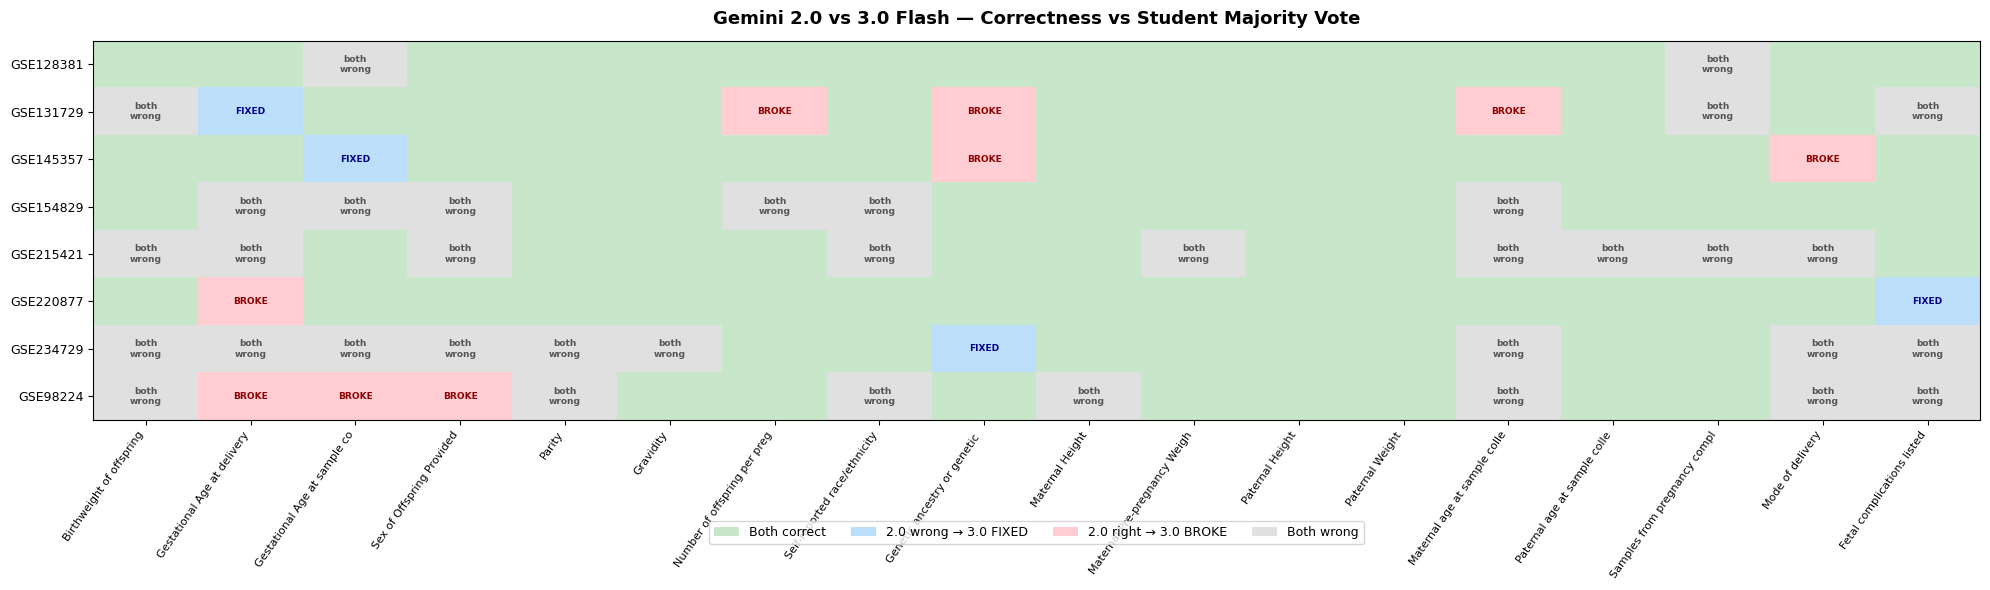


Summary: 95 both correct, 4 FIXED by 3.0, 9 BROKE by 3.0, 36 both wrong
Gemini 2.0 accuracy: 104/144 = 72.2%
Gemini 3.0 accuracy: 99/144 = 68.8%
Net change: regressed (4 fixed vs 9 broke)


In [59]:
# Figure 1: Gemini 2.0 vs 3.0 Heatmap — color by correctness vs student majority
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Build student majority vote ground truth (yes/no only)
student_majority = {}
for geo_id in PAPERS:
    student_majority[geo_id] = {}
    for q in YESNO_QUESTIONS:
        vals = [student_normalized[sn][geo_id][q] for sn in ["Set1", "Set2", "Set3"]]
        c = Counter(vals)
        student_majority[geo_id][q] = c.most_common(1)[0][0]

# Build heatmap data: for each paper x question, classify the outcome
# 0 = both correct, 1 = 2.0 wrong → 3.0 fixed, 2 = 2.0 right → 3.0 broke, 3 = both wrong
short_qs = [q.replace(' provided (yes/no)', '').replace(' (yes/no)', '') for q in YESNO_QUESTIONS]
short_qs_display = [q[:28] for q in short_qs]

heat_data = []
annotations = []
for geo_id in PAPERS:
    row_data = []
    row_annot = []
    for q in YESNO_QUESTIONS:
        gt = student_majority[geo_id][q]
        old = model_results["gemini-2.0-flash"][geo_id][q]
        new = model_results["gemini-3.0-flash-preview"][geo_id][q]
        
        old_correct = (old == gt)
        new_correct = (new == gt)
        
        if old_correct and new_correct:
            row_data.append(0)
            row_annot.append("")
        elif not old_correct and new_correct:
            row_data.append(1)
            row_annot.append("FIXED")
        elif old_correct and not new_correct:
            row_data.append(2)
            row_annot.append("BROKE")
        else:
            row_data.append(3)
            row_annot.append("both\nwrong")
    heat_data.append(row_data)
    annotations.append(row_annot)

heat_arr = np.array(heat_data)

# Custom colormap: green=both correct, blue=fixed, red=broke, gray=both wrong
cmap = mcolors.ListedColormap(["#c8e6c9", "#bbdefb", "#ffcdd2", "#e0e0e0"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(heat_arr, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(YESNO_QUESTIONS)))
ax.set_xticklabels(short_qs_display, rotation=55, ha='right', fontsize=8)
ax.set_yticks(range(len(PAPERS)))
ax.set_yticklabels(PAPERS, fontsize=9)

# Add text annotations
for i in range(len(PAPERS)):
    for j in range(len(YESNO_QUESTIONS)):
        if annotations[i][j]:
            color = "darkblue" if heat_data[i][j] == 1 else ("darkred" if heat_data[i][j] == 2 else "#555")
            ax.text(j, i, annotations[i][j], ha='center', va='center', fontsize=6.5, fontweight='bold', color=color)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c8e6c9', label='Both correct'),
    Patch(facecolor='#bbdefb', label='2.0 wrong → 3.0 FIXED'),
    Patch(facecolor='#ffcdd2', label='2.0 right → 3.0 BROKE'),
    Patch(facecolor='#e0e0e0', label='Both wrong'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=9)

ax.set_title("Gemini 2.0 vs 3.0 Flash — Correctness vs Student Majority Vote", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("gemini_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Summary stats
fixed = np.sum(heat_arr == 1)
broke = np.sum(heat_arr == 2)
both_right = np.sum(heat_arr == 0)
both_wrong = np.sum(heat_arr == 3)
total = heat_arr.size
print(f"\nSummary: {both_right} both correct, {fixed} FIXED by 3.0, {broke} BROKE by 3.0, {both_wrong} both wrong")
print(f"Gemini 2.0 accuracy: {(both_right + broke)}/{total} = {100*(both_right + broke)/total:.1f}%")
print(f"Gemini 3.0 accuracy: {(both_right + fixed)}/{total} = {100*(both_right + fixed)/total:.1f}%")
print(f"Net change: {'improved' if fixed > broke else 'regressed'} ({fixed} fixed vs {broke} broke)")

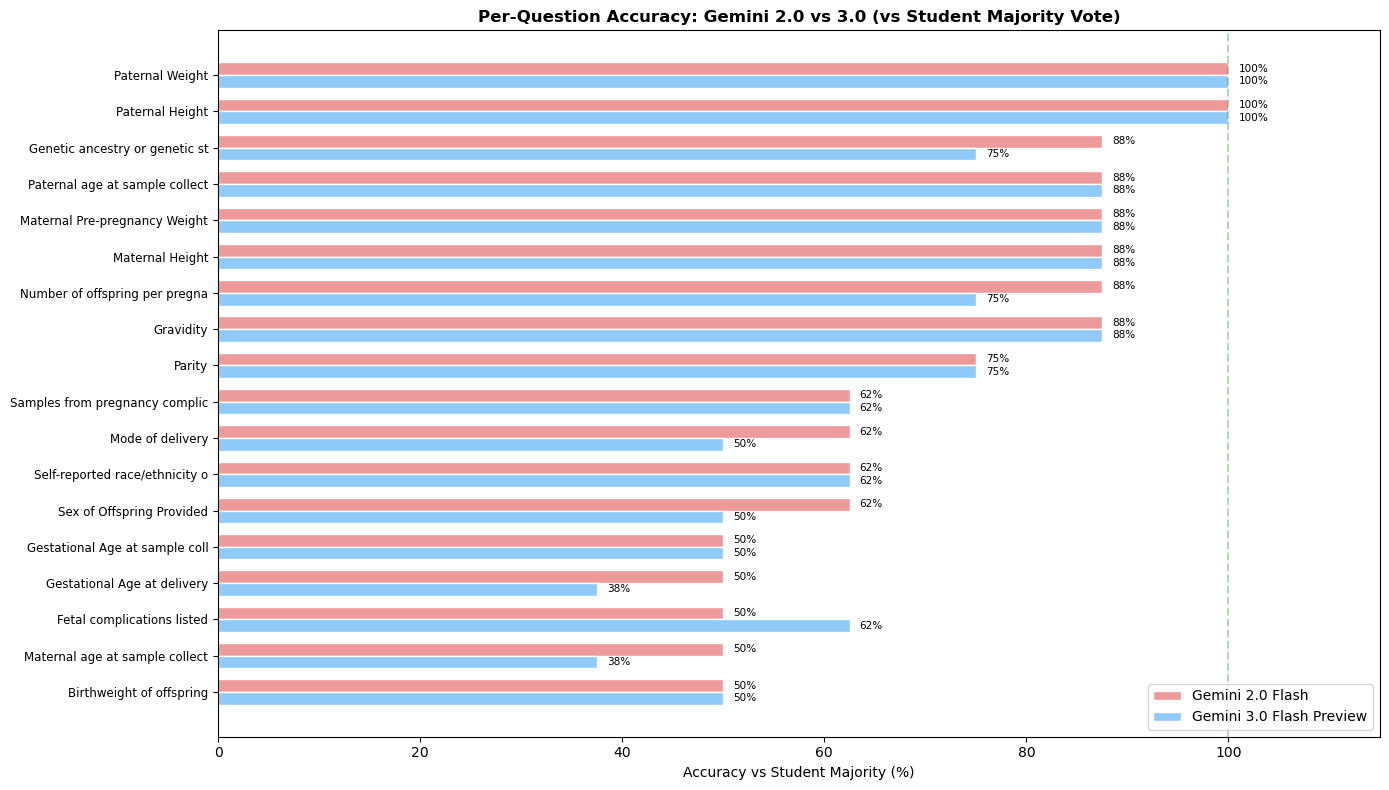


PER-QUESTION ACCURACY vs STUDENT MAJORITY
Question                                G2.0     G3.0   Change
--------------------------------------------------------------
  Birthweight of offspring                50%     50%    +0%
  Maternal age at sample collect          50%     38%   -12%
  Fetal complications listed              50%     62% +  +12%
  Gestational Age at delivery             50%     38%   -12%
  Gestational Age at sample coll          50%     50%    +0%
  Sex of Offspring Provided               62%     50%   -12%
  Self-reported race/ethnicity o          62%     62%    +0%
  Mode of delivery                        62%     50%   -12%
  Samples from pregnancy complic          62%     62%    +0%
  Parity                                  75%     75%    +0%
  Gravidity                               88%     88%    +0%
  Number of offspring per pregna          88%     75%   -12%
  Maternal Height                         88%     88%    +0%
  Maternal Pre-pregnancy Weight      

In [60]:
# Figure 2: Three-way comparison — Student Majority vs Gemini 2.0 vs Gemini 3.0
# Per-question accuracy bar chart

short_qs = []
g20_acc = []
g30_acc = []

for q in YESNO_QUESTIONS:
    short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')
    short_qs.append(short_q[:30])
    
    correct_20 = 0
    correct_30 = 0
    for geo_id in PAPERS:
        gt = student_majority[geo_id][q]
        if model_results["gemini-2.0-flash"][geo_id][q] == gt:
            correct_20 += 1
        if model_results["gemini-3.0-flash-preview"][geo_id][q] == gt:
            correct_30 += 1
    g20_acc.append(100 * correct_20 / len(PAPERS))
    g30_acc.append(100 * correct_30 / len(PAPERS))

# Sort by G2.0 accuracy (worst first)
order = np.argsort(g20_acc)
short_qs = [short_qs[i] for i in order]
g20_acc = [g20_acc[i] for i in order]
g30_acc = [g30_acc[i] for i in order]

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(short_qs))
bar_h = 0.35

bars1 = ax.barh(y + bar_h/2, g20_acc, bar_h, label='Gemini 2.0 Flash', color='#ef9a9a', edgecolor='white')
bars2 = ax.barh(y - bar_h/2, g30_acc, bar_h, label='Gemini 3.0 Flash Preview', color='#90caf9', edgecolor='white')

# Add value labels
for bar in bars1:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.0f}%', va='center', fontsize=7.5)
for bar in bars2:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.0f}%', va='center', fontsize=7.5)

ax.set_yticks(y)
ax.set_yticklabels(short_qs, fontsize=8.5)
ax.set_xlabel('Accuracy vs Student Majority (%)')
ax.set_title('Per-Question Accuracy: Gemini 2.0 vs 3.0 (vs Student Majority Vote)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 115)
ax.axvline(x=100, color='green', linestyle='--', alpha=0.3, label='Perfect')

plt.tight_layout()
plt.savefig("gemini_accuracy_bars.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Print summary table
print("\nPER-QUESTION ACCURACY vs STUDENT MAJORITY")
print(f"{'Question':<35s} {'G2.0':>8s} {'G3.0':>8s} {'Change':>8s}")
print("-" * 62)
for i in range(len(short_qs)):
    diff = g30_acc[i] - g20_acc[i]
    arrow = "+" if diff > 0 else ("" if diff == 0 else "")
    print(f"  {short_qs[i]:<35s} {g20_acc[i]:>6.0f}% {g30_acc[i]:>6.0f}% {arrow}{diff:>+5.0f}%")

print(f"\n  {'OVERALL':<35s} {np.mean(g20_acc):>6.1f}% {np.mean(g30_acc):>6.1f}% {np.mean(g30_acc)-np.mean(g20_acc):>+5.1f}%")

In [61]:
# Figure 3: Deep Dive — Specific questions where G2.0 and G3.0 differ
# Show Student Majority, G2.0, G3.0 raw answers side-by-side for every disagreement

rows = []
for geo_id in PAPERS:
    for q in YESNO_QUESTIONS:
        gt = student_majority[geo_id][q]
        old = model_results["gemini-2.0-flash"][geo_id][q]
        new = model_results["gemini-3.0-flash-preview"][geo_id][q]
        
        # Only show rows where at least one model differs from student majority
        if old == gt and new == gt:
            continue
        
        short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')
        
        # Classify
        if old != gt and new == gt:
            status = "3.0 FIXED"
        elif old == gt and new != gt:
            status = "3.0 BROKE"
        elif old != gt and new != gt and old == new:
            status = "Both wrong (same)"
        elif old != gt and new != gt:
            status = "Both wrong (diff)"
        else:
            status = "?"
        
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "Student Majority": gt,
            "Gemini 2.0": old,
            "Gemini 3.0": new,
            "Status": status,
        })

deep_df = pd.DataFrame(rows)

print("DEEP DIVE: Every Question Where Gemini Disagrees with Students")
print(f"({len(deep_df)} cases across {len(PAPERS)} papers)")
print()
pd.set_option('display.max_colwidth', 45)

# Style the table with color
def color_status(val):
    if "FIXED" in str(val): return 'background-color: #bbdefb'
    if "BROKE" in str(val): return 'background-color: #ffcdd2'
    if "Both wrong" in str(val): return 'background-color: #e0e0e0'
    return ''

styled = deep_df.style.map(color_status, subset=['Status'])
display(styled)

# Summary by status
print("\nBreakdown:")
for status, count in deep_df["Status"].value_counts().items():
    print(f"  {status}: {count}")

# Which questions are hardest for BOTH Gemini versions?
print("\nQuestions where BOTH Gemini versions got it wrong:")
both_wrong = deep_df[deep_df["Status"].str.startswith("Both wrong")]
if len(both_wrong) > 0:
    for _, r in both_wrong.iterrows():
        print(f"  {r['GEO ID']} — {r['Question']}: Students={r['Student Majority']}, G2.0={r['Gemini 2.0']}, G3.0={r['Gemini 3.0']}")
else:
    print("  None — at least one version always matches students!")

DEEP DIVE: Every Question Where Gemini Disagrees with Students
(49 cases across 8 papers)



,GEO ID,Question,Student Majority,Gemini 2.0,Gemini 3.0,Status
0,GSE128381,Gestational Age at sample collection,No,Yes,Yes,Both wrong (same)
1,GSE128381,Samples from pregnancy complications collected,No,Yes,Yes,Both wrong (same)
2,GSE131729,Birthweight of offspring,No,Yes,Yes,Both wrong (same)
3,GSE131729,Gestational Age at delivery,No,Yes,No,3.0 FIXED
4,GSE131729,Number of offspring per pregnancy,No,No,Yes,3.0 BROKE
5,GSE131729,Genetic ancestry or genetic strain,No,No,Yes,3.0 BROKE
6,GSE131729,Maternal age at sample collection,No,No,Yes,3.0 BROKE
7,GSE131729,Samples from pregnancy complications collected,No,Yes,Yes,Both wrong (same)
8,GSE131729,Fetal complications listed,No,Yes,Yes,Both wrong (same)
9,GSE145357,Gestational Age at sample collection,Yes,No,Yes,3.0 FIXED



Breakdown:
  Both wrong (same): 36
  3.0 BROKE: 9
  3.0 FIXED: 4

Questions where BOTH Gemini versions got it wrong:
  GSE128381 — Gestational Age at sample collection: Students=No, G2.0=Yes, G3.0=Yes
  GSE128381 — Samples from pregnancy complications collected: Students=No, G2.0=Yes, G3.0=Yes
  GSE131729 — Birthweight of offspring: Students=No, G2.0=Yes, G3.0=Yes
  GSE131729 — Samples from pregnancy complications collected: Students=No, G2.0=Yes, G3.0=Yes
  GSE131729 — Fetal complications listed: Students=No, G2.0=Yes, G3.0=Yes
  GSE154829 — Gestational Age at delivery: Students=Yes, G2.0=No, G3.0=No
  GSE154829 — Gestational Age at sample collection: Students=Yes, G2.0=No, G3.0=No
  GSE154829 — Sex of Offspring Provided: Students=Yes, G2.0=No, G3.0=No
  GSE154829 — Number of offspring per pregnancy: Students=Yes, G2.0=No, G3.0=No
  GSE154829 — Self-reported race/ethnicity of mother: Students=Yes, G2.0=No, G3.0=No
  GSE154829 — Maternal age at sample collection: Students=Yes, G2.0=No

In [62]:
# Non-Yes/No fields: 3 Student Sets vs Gemini 2.0 vs Gemini 3.0 — raw answers side-by-side

NON_YESNO_COMPARE = [TRIMESTER_QUESTION, COUNTRY_QUESTION] + GA_QUESTIONS + LIST_QUESTIONS + [
    "Supervisor/Contact/Corresponding author name",
    "Hospital/Center where samples were collected",
]

rows = []
for geo_id in PAPERS:
    for q in NON_YESNO_COMPARE:
        # Student raw answers
        s_raw = []
        s_norm = []
        for sn in ["Set1", "Set2", "Set3"]:
            rv = str(student_sets[sn][geo_id][q]).strip()
            s_raw.append(rv if rv not in {"nan", ""} else "-")
            s_norm.append(str(student_normalized[sn][geo_id][q]))
        
        # Gemini raw answers
        g20_raw = get_raw_ai_fast("gemini-2.0-flash", geo_id, q)
        g30_raw = get_raw_ai_fast("gemini-3.0-flash-preview", geo_id, q)
        g20_norm = str(model_results["gemini-2.0-flash"][geo_id].get(q, "Not Provided"))
        g30_norm = str(model_results["gemini-3.0-flash-preview"][geo_id].get(q, "Not Provided"))
        
        # Check agreement: do all 5 sources agree after normalization?
        all_norms = s_norm + [g20_norm, g30_norm]
        all_agree = len(set(all_norms)) == 1
        # Students agree among themselves?
        students_agree = len(set(s_norm)) == 1
        # Geminis agree with each other?
        geminis_agree = g20_norm == g30_norm
        # Student majority
        s_majority = Counter(s_norm).most_common(1)[0][0]
        # Gemini vs student majority
        g20_match = g20_norm == s_majority
        g30_match = g30_norm == s_majority
        
        short_q = q.replace(" (1st, 2nd, 3rd, term, premature)", "")
        short_q = short_q.replace(" in data set (list)", " (list)")
        short_q = short_q.replace("Supervisor/Contact/Corresponding author ", "Author ")
        short_q = short_q.replace("Hospital/Center where samples were collected", "Hospital")
        short_q = short_q.replace("Country where samples were collected", "Country")
        
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "S1": s_raw[0][:40],
            "S2": s_raw[1][:40],
            "S3": s_raw[2][:40],
            "G2.0 Flash": g20_raw[:40],
            "G3.0 Flash": g30_raw[:40],
            "Students Agree?": "Yes" if students_agree else "No",
            "G2.0=Stud?": "Yes" if g20_match else "NO",
            "G3.0=Stud?": "Yes" if g30_match else "NO",
        })

compare_df = pd.DataFrame(rows)

print("NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0")
print(f"Total: {len(compare_df)} rows")
print(f"Students disagree among themselves: {(compare_df['Students Agree?'] == 'No').sum()} rows")
print(f"Gemini 2.0 differs from student majority: {(compare_df['G2.0=Stud?'] == 'NO').sum()} rows")
print(f"Gemini 3.0 differs from student majority: {(compare_df['G3.0=Stud?'] == 'NO').sum()} rows")
print()

pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 280)
display(compare_df)

# Now show ONLY rows where something is off
disagree_mask = (compare_df["Students Agree?"] == "No") | (compare_df["G2.0=Stud?"] == "NO") | (compare_df["G3.0=Stud?"] == "NO")
disagree_compare = compare_df[disagree_mask].reset_index(drop=True)

print(f"\n\nDISAGREEMENTS ONLY — {len(disagree_compare)} rows where students disagree OR Gemini differs from student majority")
print()
display(disagree_compare)

NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0
Total: 72 rows
Students disagree among themselves: 50 rows
Gemini 2.0 differs from student majority: 48 rows
Gemini 3.0 differs from student majority: 47 rows



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash,Students Agree?,G2.0=Stud?,G3.0=Stud?
0,GSE128381,Pregnancy trimester,Term,term,Term,Term,Term,Yes,Yes,Yes
1,GSE128381,Country,Belgium,Belgian,Belgium,Belgium,Belgium,Yes,Yes,Yes
2,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9,No,NO,NO
3,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9,No,Yes,NO
4,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy",Yes,Yes,NO
...,...,...,...,...,...,...,...,...,...,...
67,GSE98224,Pregnancy complications (list),"preclampsia, fetal growth restriction","Preeclampsia, HELLP, Fetal growth restri","Preeclampsia, proteinuria, HELLP, chorio",Preeclampsia,"['Preeclampsia', 'Early-onset preeclamps",No,NO,NO
68,GSE98224,Fetal complications (list),"Fetal growth restriction, small-for-gest",-,"Intrauterine growth restriction, NICU tr",-,[],No,NO,NO
69,GSE98224,Other Phenotypes Provided (list),"Gestational age at delivery, fetal sex,",-,"Maternal BMI, maternal blood type, previ",-,"['DNA methylation', 'Placental gene expr",No,NO,NO
70,GSE98224,Author name,Brian J Cox,Brian Cox,Brian Cox,Brian J. Cox,Brian J. Cox,No,NO,NO




DISAGREEMENTS ONLY — 63 rows where students disagree OR Gemini differs from student majority



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash,Students Agree?,G2.0=Stud?,G3.0=Stud?
0,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9,No,NO,NO
1,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9,No,Yes,NO
2,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy",Yes,Yes,NO
3,GSE128381,Other Phenotypes Provided (list),-,no,-,"Maternal smoking status, Weight gain dur","['Maternal pre-pregnancy BMI', 'Maternal",Yes,NO,NO
4,GSE128381,Author name,Tim S Nawrot,Tim S Nawrot,Tim S. Nawrot,Tim S. Nawrot,Tim S. Nawrot,No,NO,NO
...,...,...,...,...,...,...,...,...,...,...
58,GSE98224,Pregnancy complications (list),"preclampsia, fetal growth restriction","Preeclampsia, HELLP, Fetal growth restri","Preeclampsia, proteinuria, HELLP, chorio",Preeclampsia,"['Preeclampsia', 'Early-onset preeclamps",No,NO,NO
59,GSE98224,Fetal complications (list),"Fetal growth restriction, small-for-gest",-,"Intrauterine growth restriction, NICU tr",-,[],No,NO,NO
60,GSE98224,Other Phenotypes Provided (list),"Gestational age at delivery, fetal sex,",-,"Maternal BMI, maternal blood type, previ",-,"['DNA methylation', 'Placental gene expr",No,NO,NO
61,GSE98224,Author name,Brian J Cox,Brian Cox,Brian Cox,Brian J. Cox,Brian J. Cox,No,NO,NO


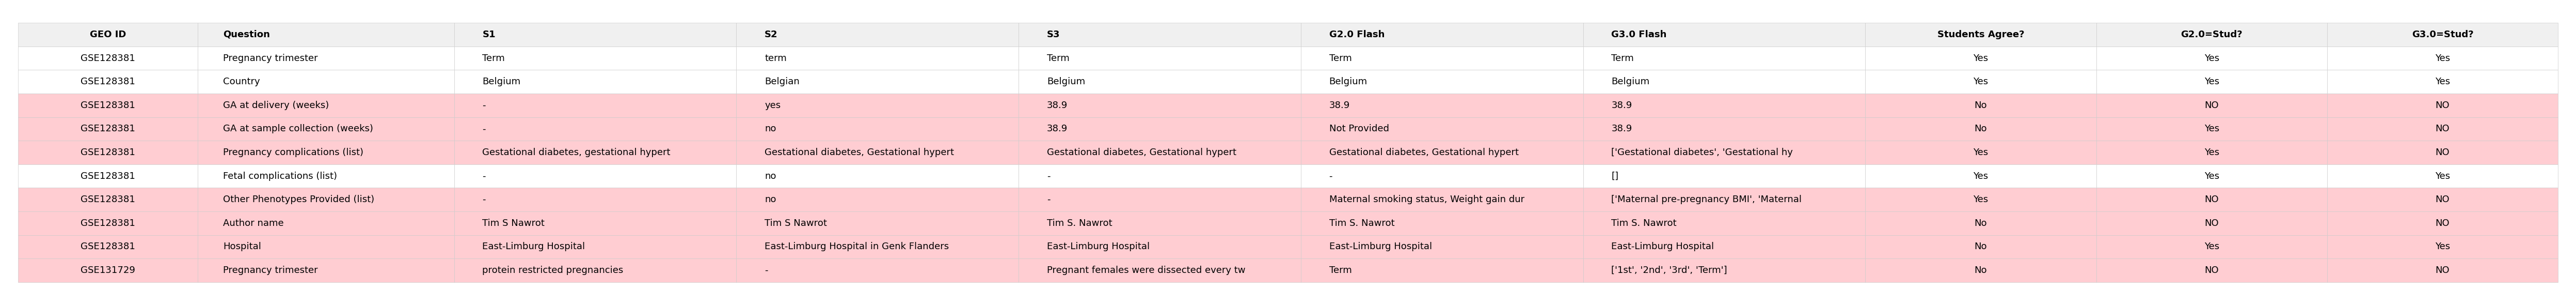

Saved as compare_all_top10.png


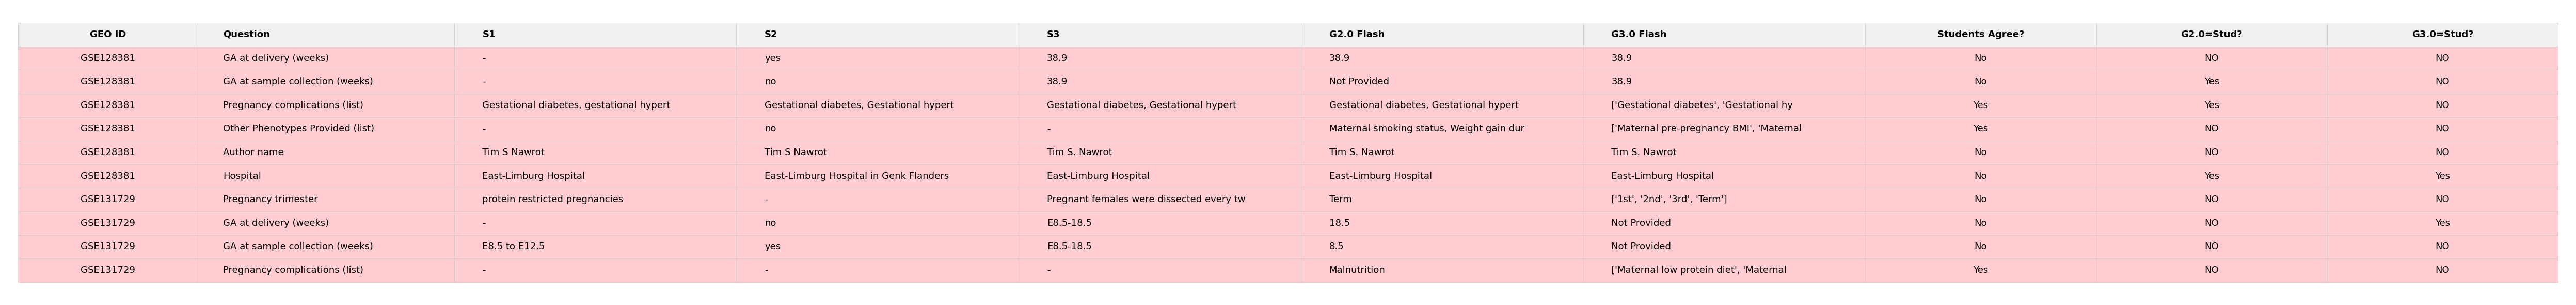

Saved as compare_disagree_top10.png


In [65]:
def save_compare_table(df, filename):
    n_rows = len(df)
    fig_height = max(6, n_rows * 0.5)  # 0.5 inches per row, minimum 6
    fig, ax = plt.subplots(figsize=(50, fig_height))
    ax.axis("off")

    col_widths = [0.07, 0.10, 0.11, 0.11, 0.11, 0.11, 0.11, 0.09, 0.09, 0.09]

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns.tolist(),
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(13)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        cell.set_linewidth(0.5)
        cell.set_height(0.8 / n_rows)  # row height scales with number of rows

        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold", color="black")
        else:
            r = df.iloc[row - 1]
            is_bad = (r["Students Agree?"] == "No") or (r["G2.0=Stud?"] == "NO") or (r["G3.0=Stud?"] == "NO")
            cell.set_facecolor("#ffcdd2" if is_bad else "white")
            cell.set_text_props(color="black")

        if col in [1, 2, 3, 4, 5, 6]:
            cell.set_text_props(ha="left")
            cell._loc = "left"

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved as {filename}")


save_compare_table(compare_df.head(10), "compare_all_top10.png")
save_compare_table(disagree_compare.head(10), "compare_disagree_top10.png")

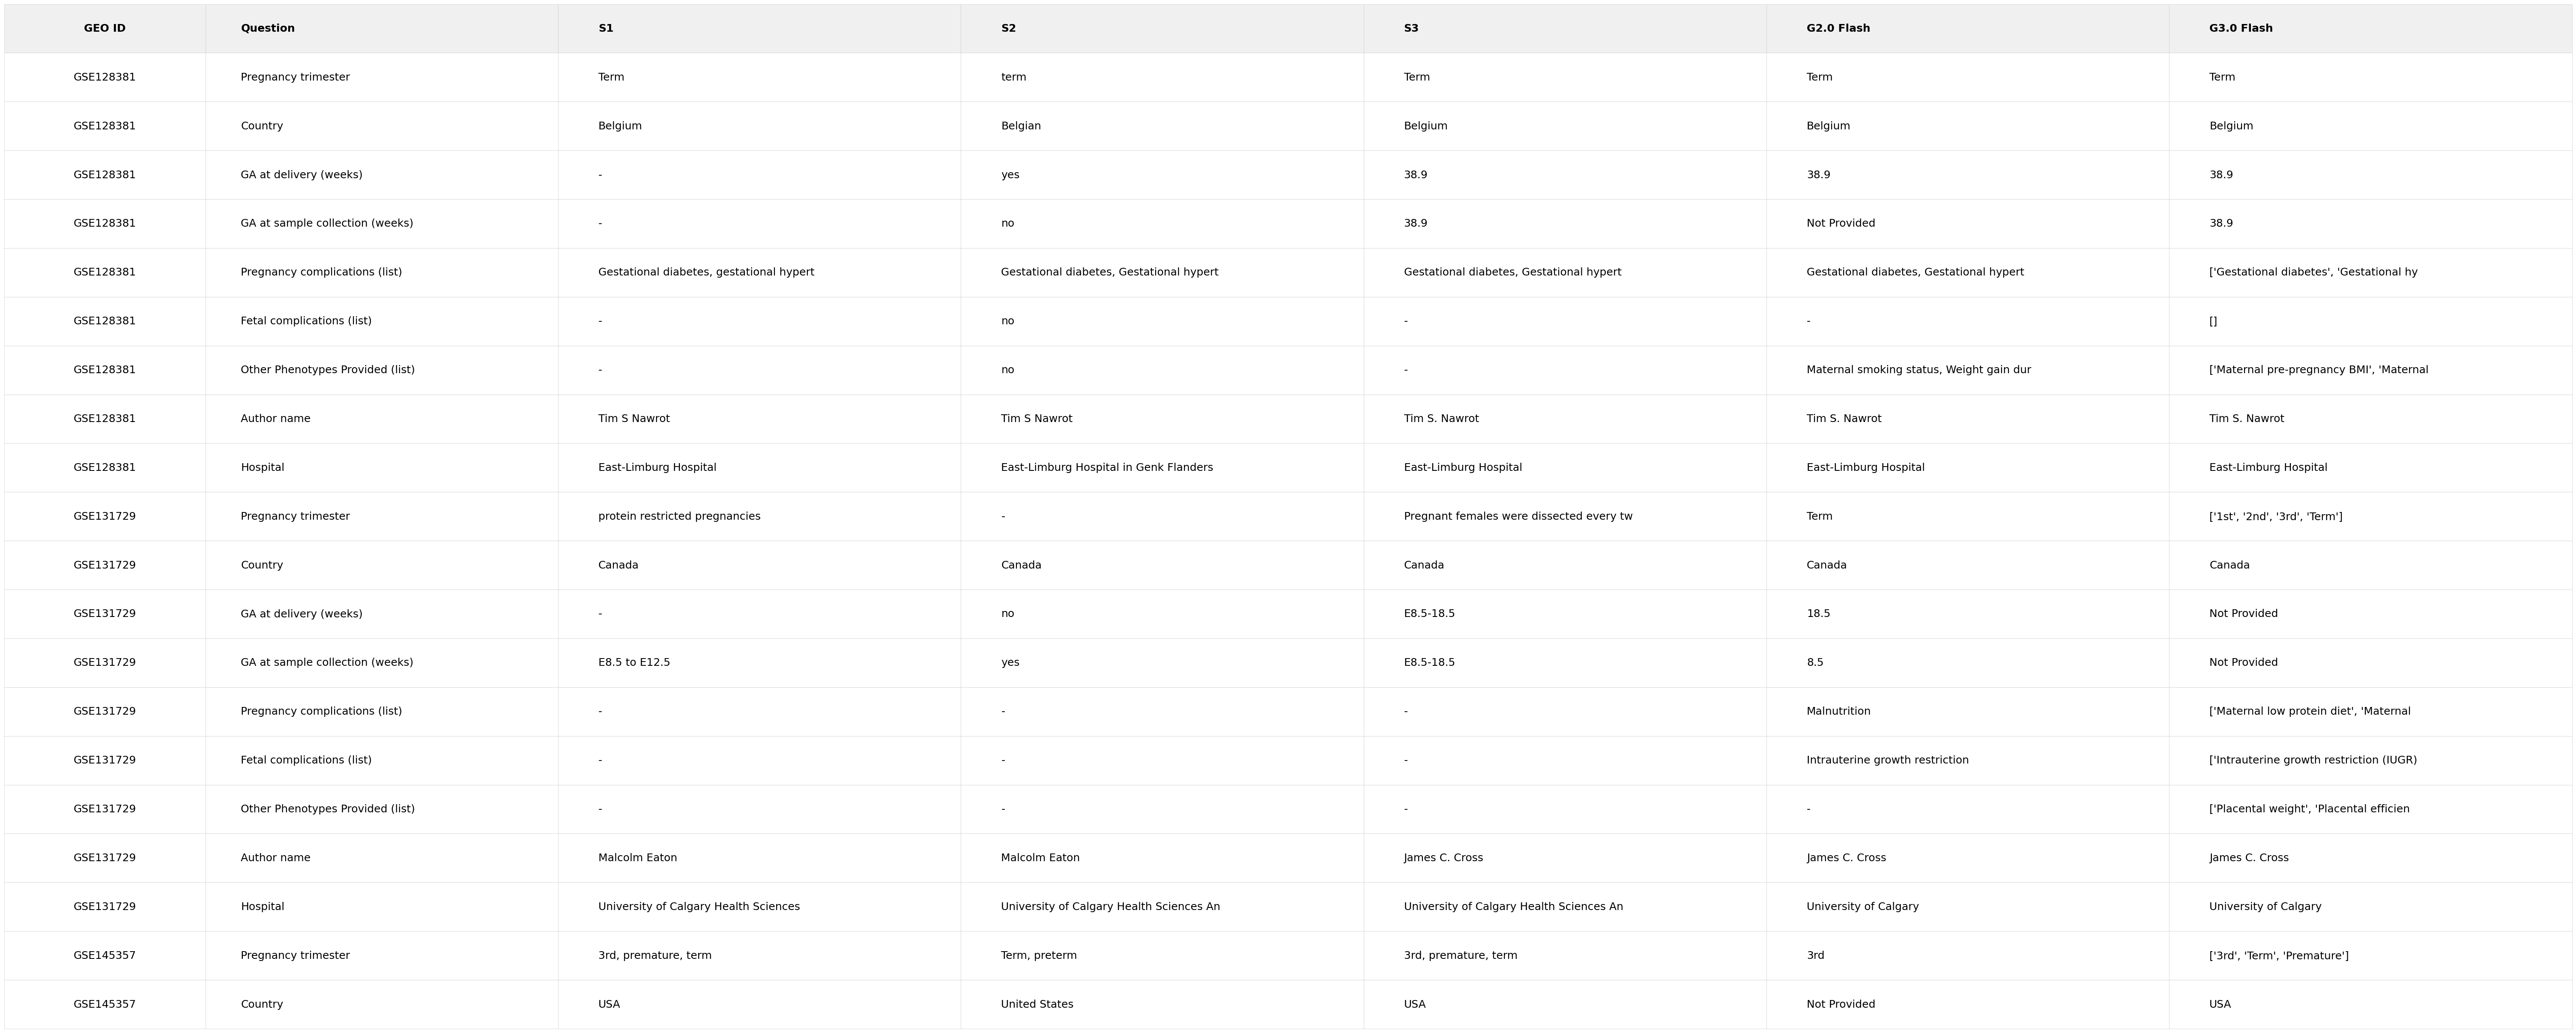

Saved as compare_all_top20.png


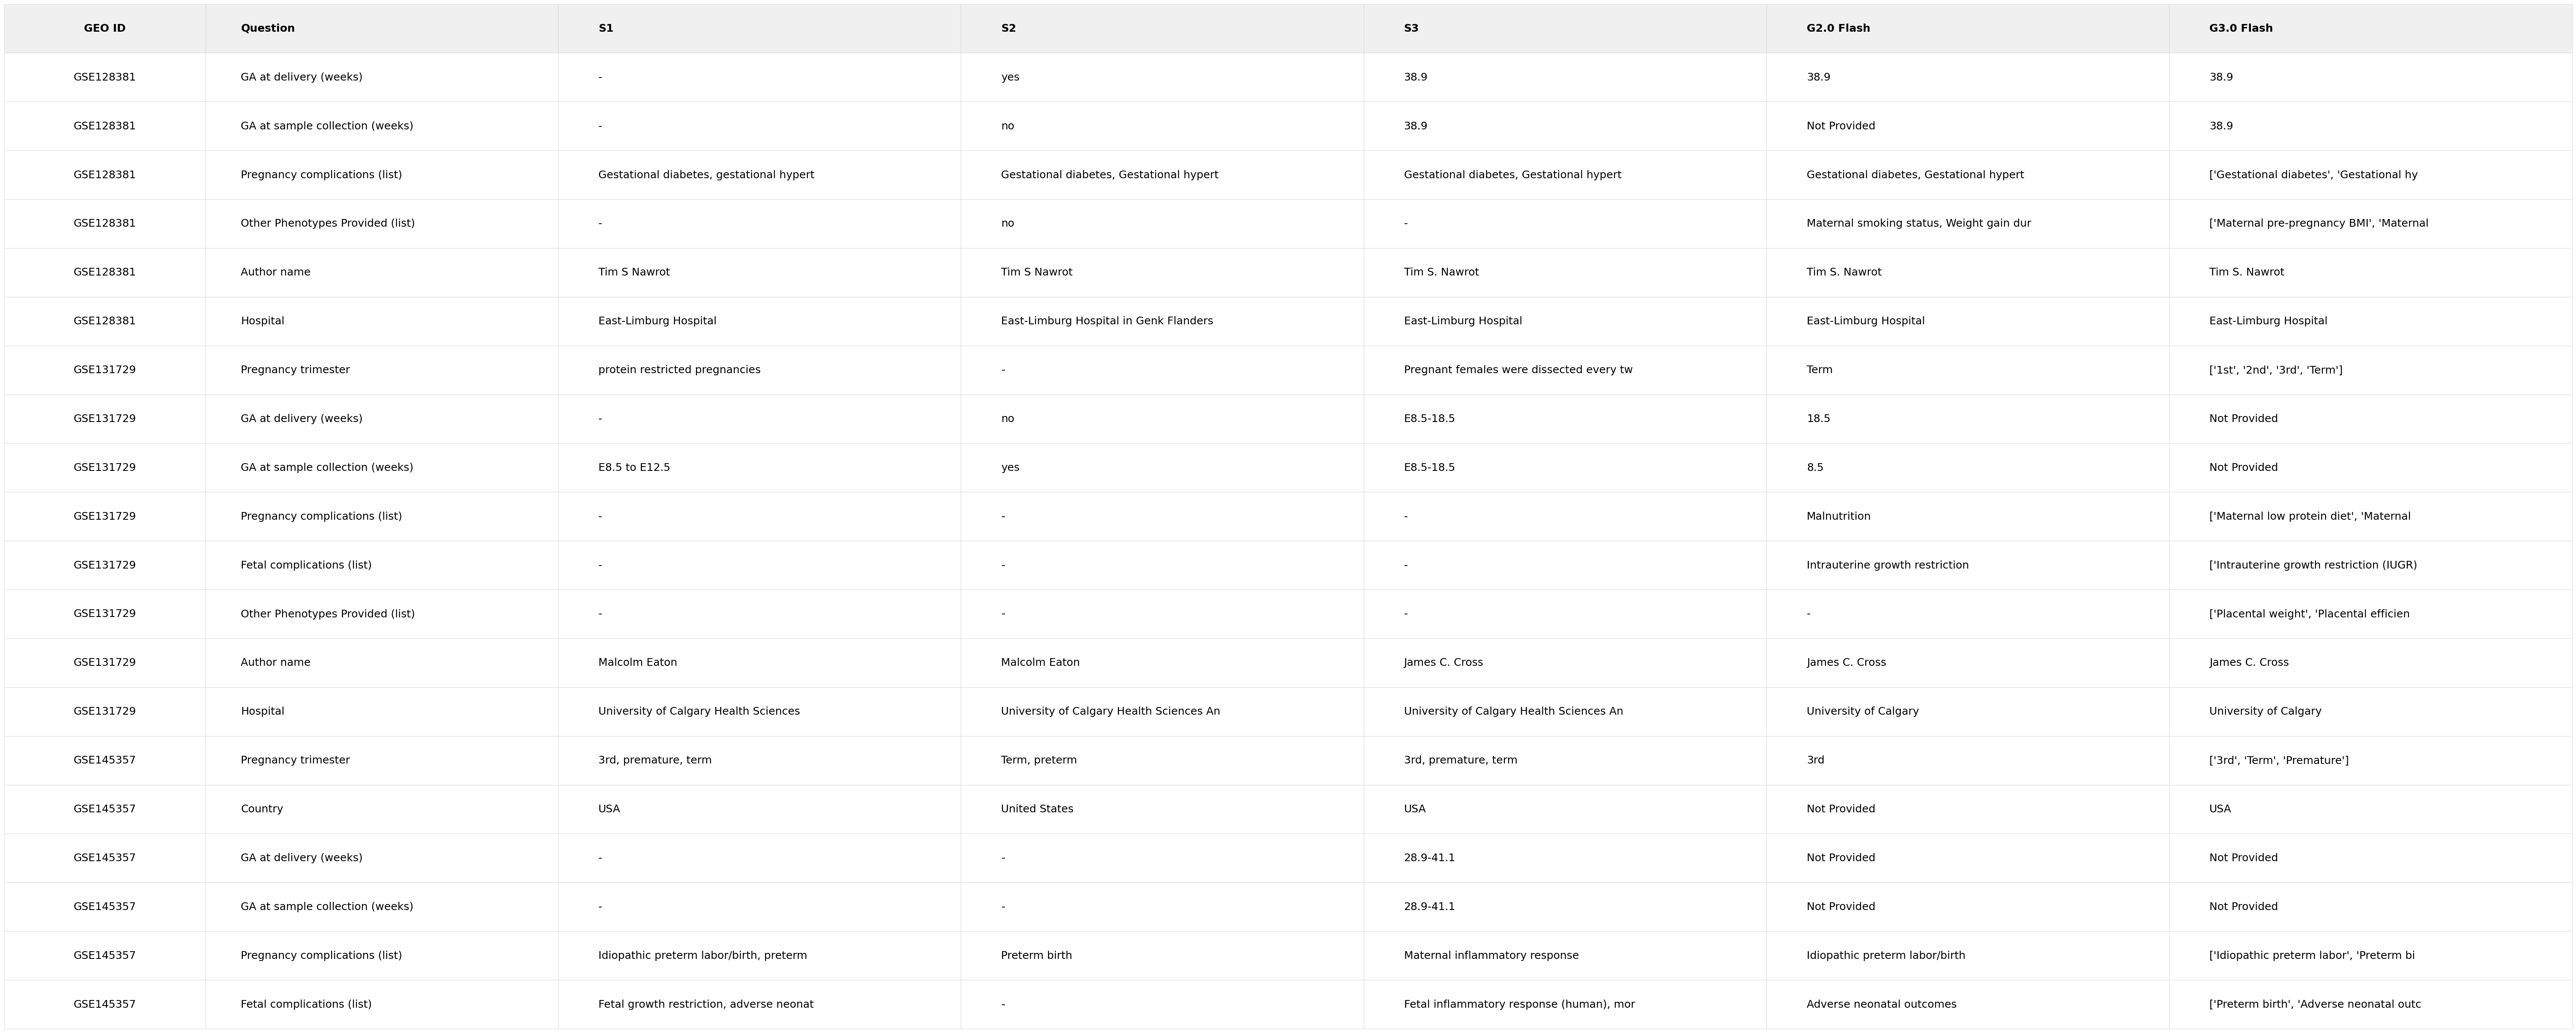

Saved as compare_disagree_top20.png


In [67]:
def save_compare_table(df, filename):
    n_rows = len(df)
    fig_height = max(8, n_rows * 1.2)
    fig, ax = plt.subplots(figsize=(60, fig_height))
    ax.axis("off")

    col_widths = [0.08, 0.14, 0.16, 0.16, 0.16, 0.16, 0.16]

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns.tolist(),
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(18)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        cell.set_linewidth(0.5)
        cell.set_height(1.0 / n_rows)

        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold", color="black")
        else:
            cell.set_facecolor("white")
            cell.set_text_props(color="black")

        if col in [1, 2, 3, 4, 5, 6]:
            cell.set_text_props(ha="left")
            cell._loc = "left"

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved as {filename}")


# drop the agreement columns
cols_to_show = ["GEO ID", "Question", "S1", "S2", "S3", "G2.0 Flash", "G3.0 Flash"]

save_compare_table(compare_df[cols_to_show].head(20), "compare_all_top20.png")
save_compare_table(disagree_compare[cols_to_show].head(20), "compare_disagree_top20.png")

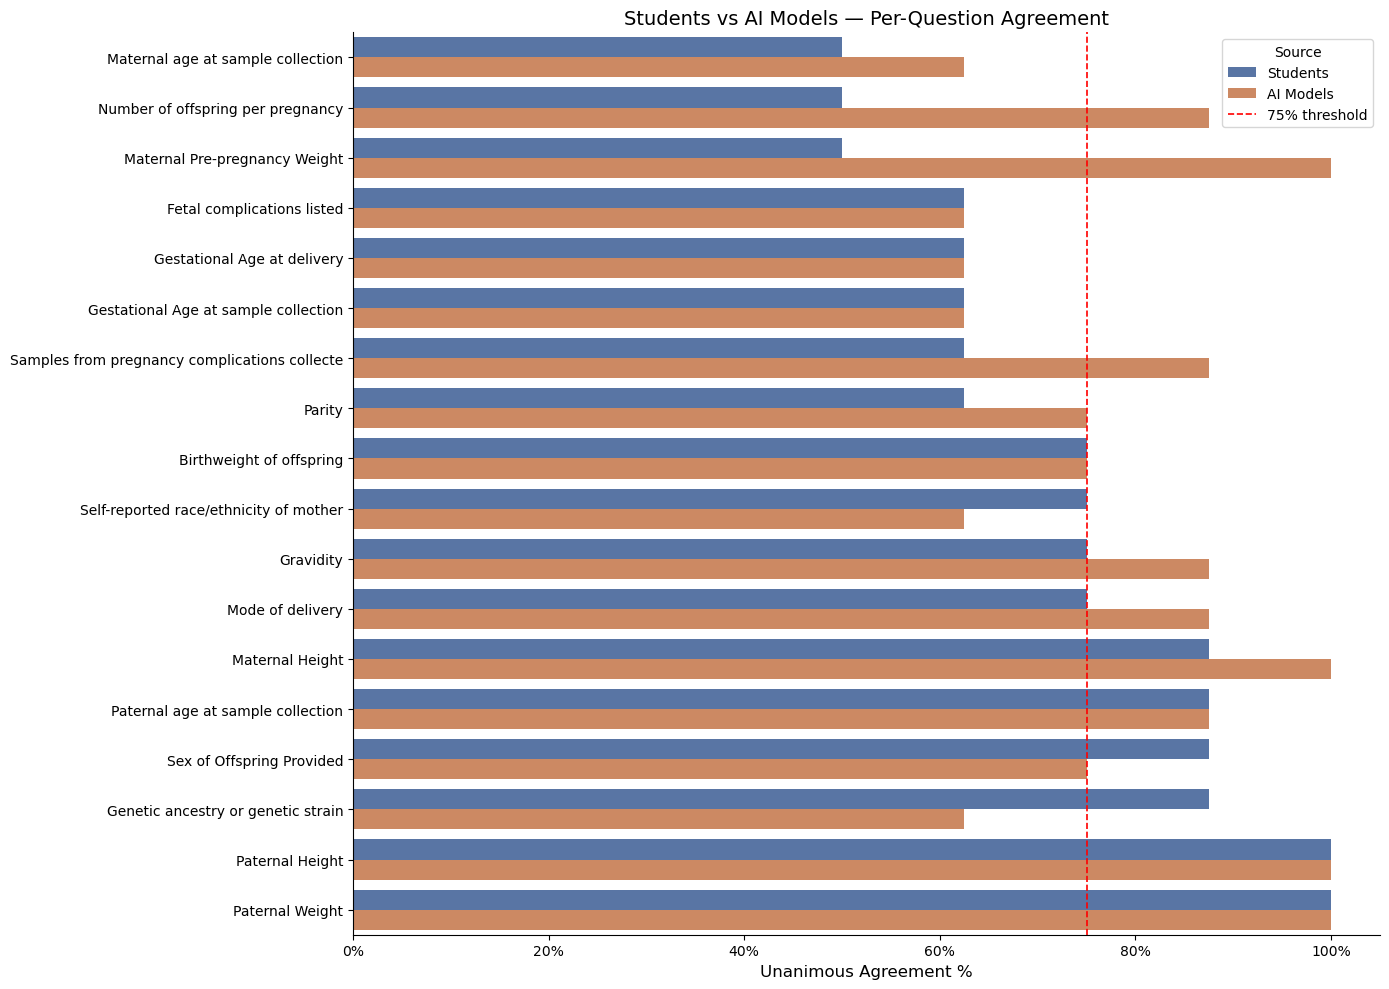

Saved as students_vs_ai_bar.png


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── collect data ──────────────────────────────────────────────────────────────
rows = []
for q in YESNO_QUESTIONS:
    s_agrees = [1 for geo in PAPERS if len(set(student_normalized[sn][geo][q] for sn in ['Set1','Set2','Set3'])) == 1]
    s_rate = len(s_agrees) / len(PAPERS)
    a_agrees = [1 for geo in PAPERS if len(set(model_results[m][geo][q] for m in ALL_MODELS)) == 1]
    a_rate = len(a_agrees) / len(PAPERS)
    short_q = q.replace(' provided (yes/no)', '').replace(' (yes/no)', '')[:45]
    rows.append({"Question": short_q, "Students": s_rate, "AI Models": a_rate})

plot_df = pd.DataFrame(rows).sort_values("Students").reset_index(drop=True)
plot_df_melted = plot_df.melt(id_vars="Question", var_name="Source", value_name="Agreement %")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

sns.barplot(data=plot_df_melted, y="Question", x="Agreement %",
            hue="Source", palette=["#4c72b0", "#dd8452"], ax=ax)

ax.axvline(0.75, color="red", linewidth=1.2, linestyle="--", label="75% threshold")
ax.set_xlabel("Unanimous Agreement %", fontsize=12)
ax.set_ylabel("")
ax.set_title("Students vs AI Models — Per-Question Agreement", fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(title="Source", fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig("students_vs_ai_bar.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved as students_vs_ai_bar.png")

NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0
Total: 72 rows
Students disagree among themselves: 50 rows
Gemini 2.0 differs from student majority: 48 rows
Gemini 3.0 differs from student majority: 47 rows



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash,Students Agree?,G2.0=Stud?,G3.0=Stud?
0,GSE128381,Pregnancy trimester,Term,term,Term,Term,Term,Yes,Yes,Yes
1,GSE128381,Country,Belgium,Belgian,Belgium,Belgium,Belgium,Yes,Yes,Yes
2,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9,No,NO,NO
3,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9,No,Yes,NO
4,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy",Yes,Yes,NO
5,GSE128381,Fetal complications (list),-,no,-,-,[],Yes,Yes,Yes
6,GSE128381,Other Phenotypes Provided (list),-,no,-,"Maternal smoking status, Weight gain dur","['Maternal pre-pregnancy BMI', 'Maternal",Yes,NO,NO
7,GSE128381,Author name,Tim S Nawrot,Tim S Nawrot,Tim S. Nawrot,Tim S. Nawrot,Tim S. Nawrot,No,NO,NO
8,GSE128381,Hospital,East-Limburg Hospital,East-Limburg Hospital in Genk Flanders,East-Limburg Hospital,East-Limburg Hospital,East-Limburg Hospital,No,Yes,Yes
9,GSE131729,Pregnancy trimester,protein restricted pregnancies,-,Pregnant females were dissected every tw,Term,"['1st', '2nd', '3rd', 'Term']",No,NO,NO




DISAGREEMENTS ONLY — 63 rows



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash,Students Agree?,G2.0=Stud?,G3.0=Stud?
0,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9,No,NO,NO
1,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9,No,Yes,NO
2,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy",Yes,Yes,NO
3,GSE128381,Other Phenotypes Provided (list),-,no,-,"Maternal smoking status, Weight gain dur","['Maternal pre-pregnancy BMI', 'Maternal",Yes,NO,NO
4,GSE128381,Author name,Tim S Nawrot,Tim S Nawrot,Tim S. Nawrot,Tim S. Nawrot,Tim S. Nawrot,No,NO,NO
5,GSE128381,Hospital,East-Limburg Hospital,East-Limburg Hospital in Genk Flanders,East-Limburg Hospital,East-Limburg Hospital,East-Limburg Hospital,No,Yes,Yes
6,GSE131729,Pregnancy trimester,protein restricted pregnancies,-,Pregnant females were dissected every tw,Term,"['1st', '2nd', '3rd', 'Term']",No,NO,NO
7,GSE131729,GA at delivery (weeks),-,no,E8.5-18.5,18.5,Not Provided,No,NO,Yes
8,GSE131729,GA at sample collection (weeks),E8.5 to E12.5,yes,E8.5-18.5,8.5,Not Provided,No,NO,NO
9,GSE131729,Pregnancy complications (list),-,-,-,Malnutrition,"['Maternal low protein diet', 'Maternal",Yes,NO,NO


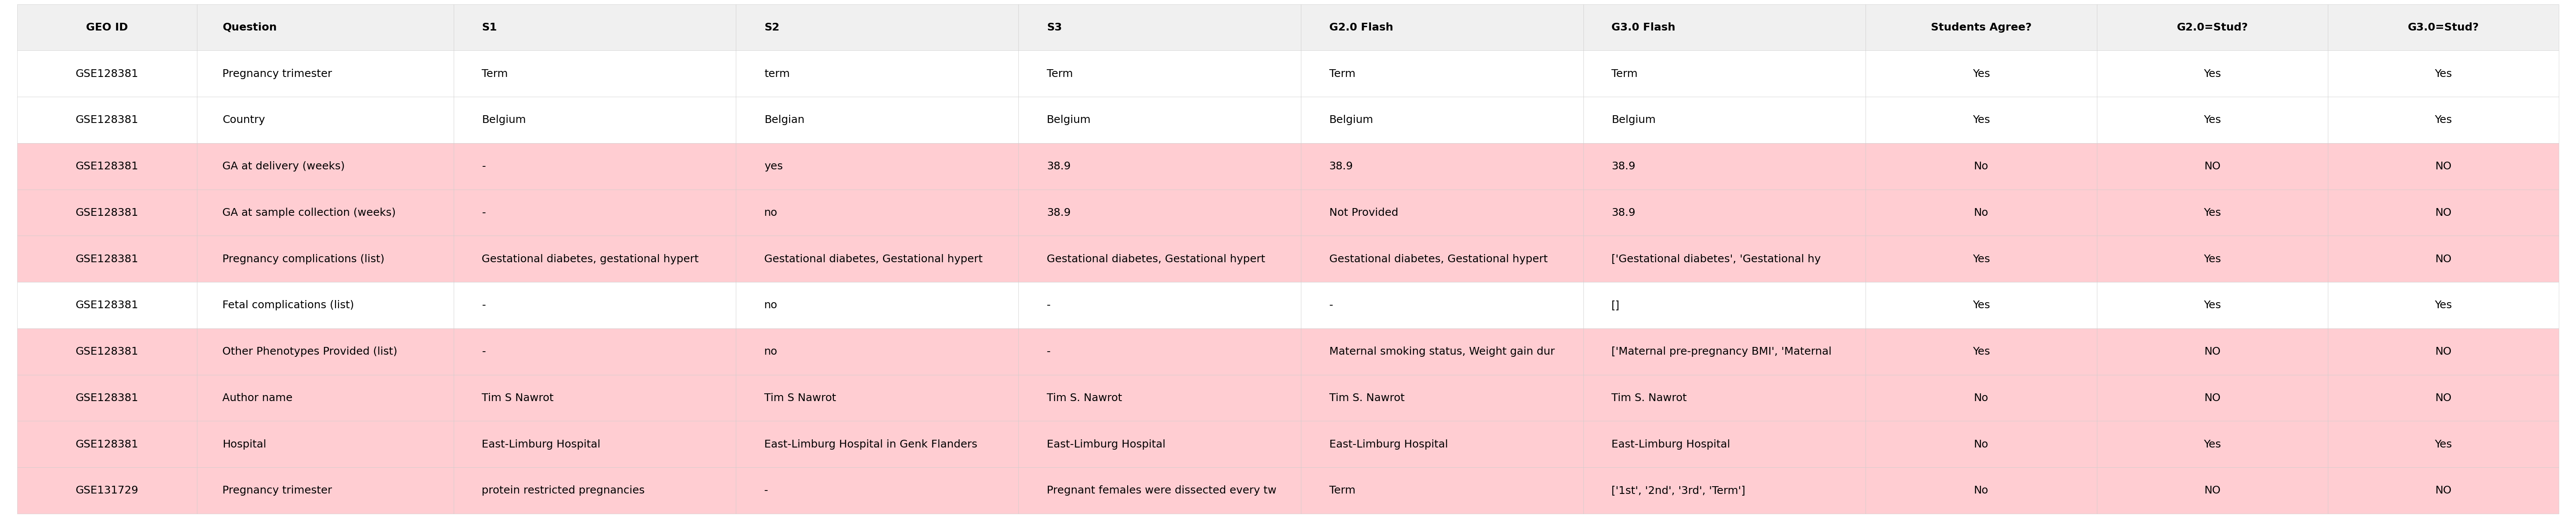

Saved as compare_all_top10.png


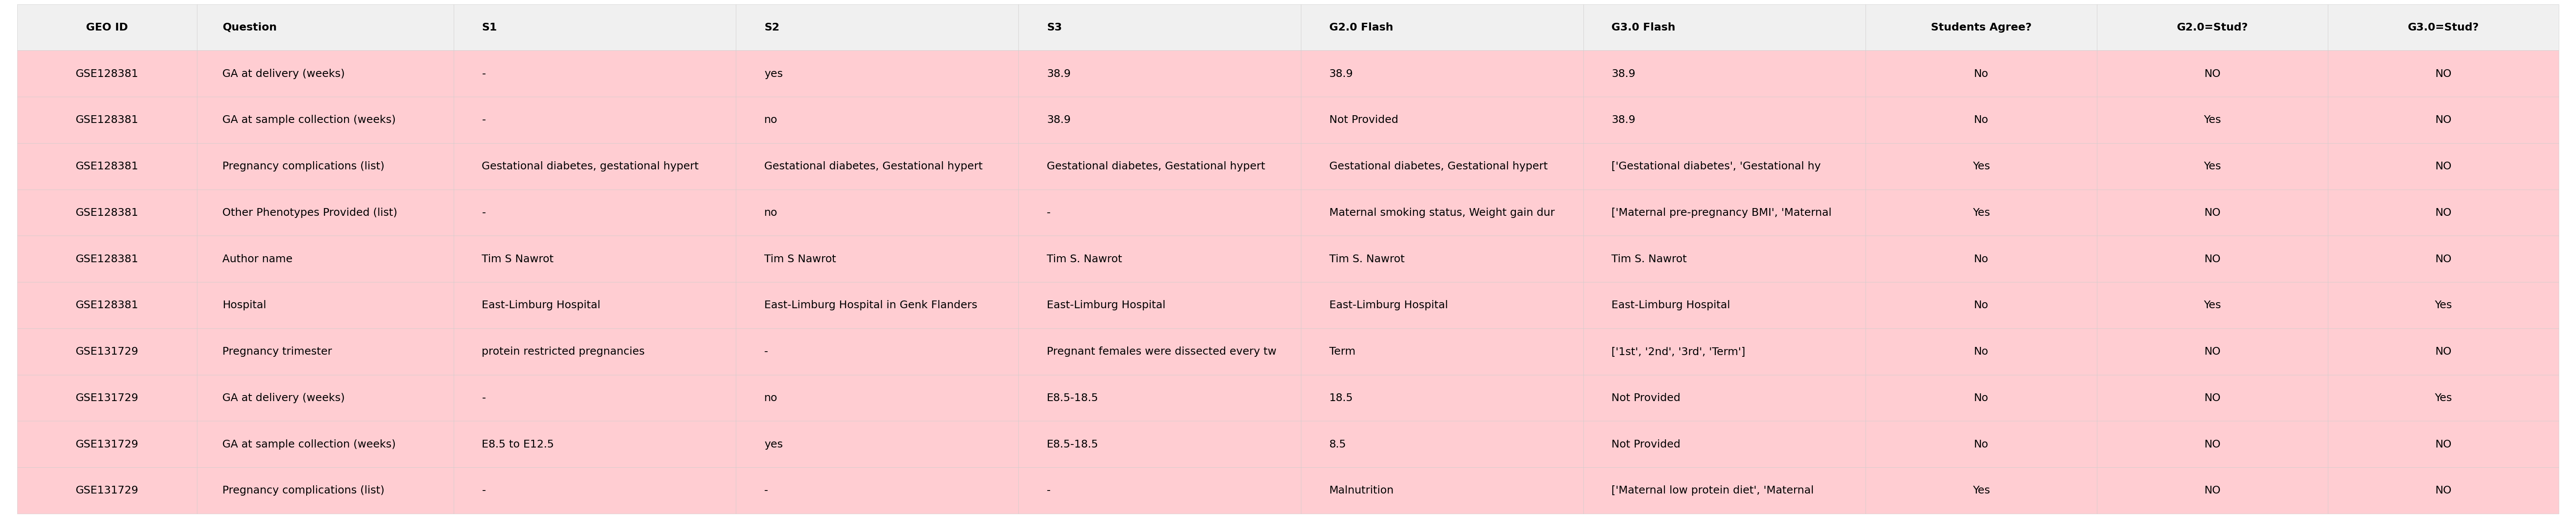

Saved as compare_disagree_top10.png


In [66]:
import matplotlib.pyplot as plt

# ── data build ───────────────────────────────────────────────────────────────
NON_YESNO_COMPARE = [TRIMESTER_QUESTION, COUNTRY_QUESTION] + GA_QUESTIONS + LIST_QUESTIONS + [
    "Supervisor/Contact/Corresponding author name",
    "Hospital/Center where samples were collected",
]

rows = []
for geo_id in PAPERS:
    for q in NON_YESNO_COMPARE:
        s_raw, s_norm = [], []
        for sn in ["Set1", "Set2", "Set3"]:
            rv = str(student_sets[sn][geo_id][q]).strip()
            s_raw.append(rv if rv not in {"nan", ""} else "-")
            s_norm.append(str(student_normalized[sn][geo_id][q]))
        g20_raw = get_raw_ai_fast("gemini-2.0-flash", geo_id, q)
        g30_raw = get_raw_ai_fast("gemini-3.0-flash-preview", geo_id, q)
        g20_norm = str(model_results["gemini-2.0-flash"][geo_id].get(q, "Not Provided"))
        g30_norm = str(model_results["gemini-3.0-flash-preview"][geo_id].get(q, "Not Provided"))
        all_norms = s_norm + [g20_norm, g30_norm]
        all_agree = len(set(all_norms)) == 1
        students_agree = len(set(s_norm)) == 1
        geminis_agree = g20_norm == g30_norm
        s_majority = Counter(s_norm).most_common(1)[0][0]
        g20_match = g20_norm == s_majority
        g30_match = g30_norm == s_majority
        short_q = q.replace(" (1st, 2nd, 3rd, term, premature)", "")
        short_q = short_q.replace(" in data set (list)", " (list)")
        short_q = short_q.replace("Supervisor/Contact/Corresponding author ", "Author ")
        short_q = short_q.replace("Hospital/Center where samples were collected", "Hospital")
        short_q = short_q.replace("Country where samples were collected", "Country")
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "S1": s_raw[0][:40],
            "S2": s_raw[1][:40],
            "S3": s_raw[2][:40],
            "G2.0 Flash": g20_raw[:40],
            "G3.0 Flash": g30_raw[:40],
            "Students Agree?": "Yes" if students_agree else "No",
            "G2.0=Stud?": "Yes" if g20_match else "NO",
            "G3.0=Stud?": "Yes" if g30_match else "NO",
        })

compare_df = pd.DataFrame(rows)

print("NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0")
print(f"Total: {len(compare_df)} rows")
print(f"Students disagree among themselves: {(compare_df['Students Agree?'] == 'No').sum()} rows")
print(f"Gemini 2.0 differs from student majority: {(compare_df['G2.0=Stud?'] == 'NO').sum()} rows")
print(f"Gemini 3.0 differs from student majority: {(compare_df['G3.0=Stud?'] == 'NO').sum()} rows")
print()
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 280)
display(compare_df.head(10))

disagree_mask = (
    (compare_df["Students Agree?"] == "No") |
    (compare_df["G2.0=Stud?"] == "NO") |
    (compare_df["G3.0=Stud?"] == "NO")
)
disagree_compare = compare_df[disagree_mask].reset_index(drop=True)
print(f"\n\nDISAGREEMENTS ONLY — {len(disagree_compare)} rows")
print()
display(disagree_compare.head(10))


# ── figure helper ─────────────────────────────────────────────────────────────
def save_compare_table(df, filename):
    n_rows = len(df)
    fig_height = max(8, n_rows * 1.2)
    fig, ax = plt.subplots(figsize=(60, fig_height))
    ax.axis("off")

    col_widths = [0.07, 0.10, 0.11, 0.11, 0.11, 0.11, 0.11, 0.09, 0.09, 0.09]

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns.tolist(),
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(18)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        cell.set_linewidth(0.5)
        cell.set_height(1.0 / n_rows)

        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold", color="black")
        else:
            r = df.iloc[row - 1]
            is_bad = (r["Students Agree?"] == "No") or (r["G2.0=Stud?"] == "NO") or (r["G3.0=Stud?"] == "NO")
            cell.set_facecolor("#ffcdd2" if is_bad else "white")
            cell.set_text_props(color="black")

        if col in [1, 2, 3, 4, 5, 6]:
            cell.set_text_props(ha="left")
            cell._loc = "left"

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved as {filename}")


# all rows (top 10)
save_compare_table(compare_df.head(10), "compare_all_top10.png")

# disagreements only (top 10)
save_compare_table(disagree_compare.head(10), "compare_disagree_top10.png")

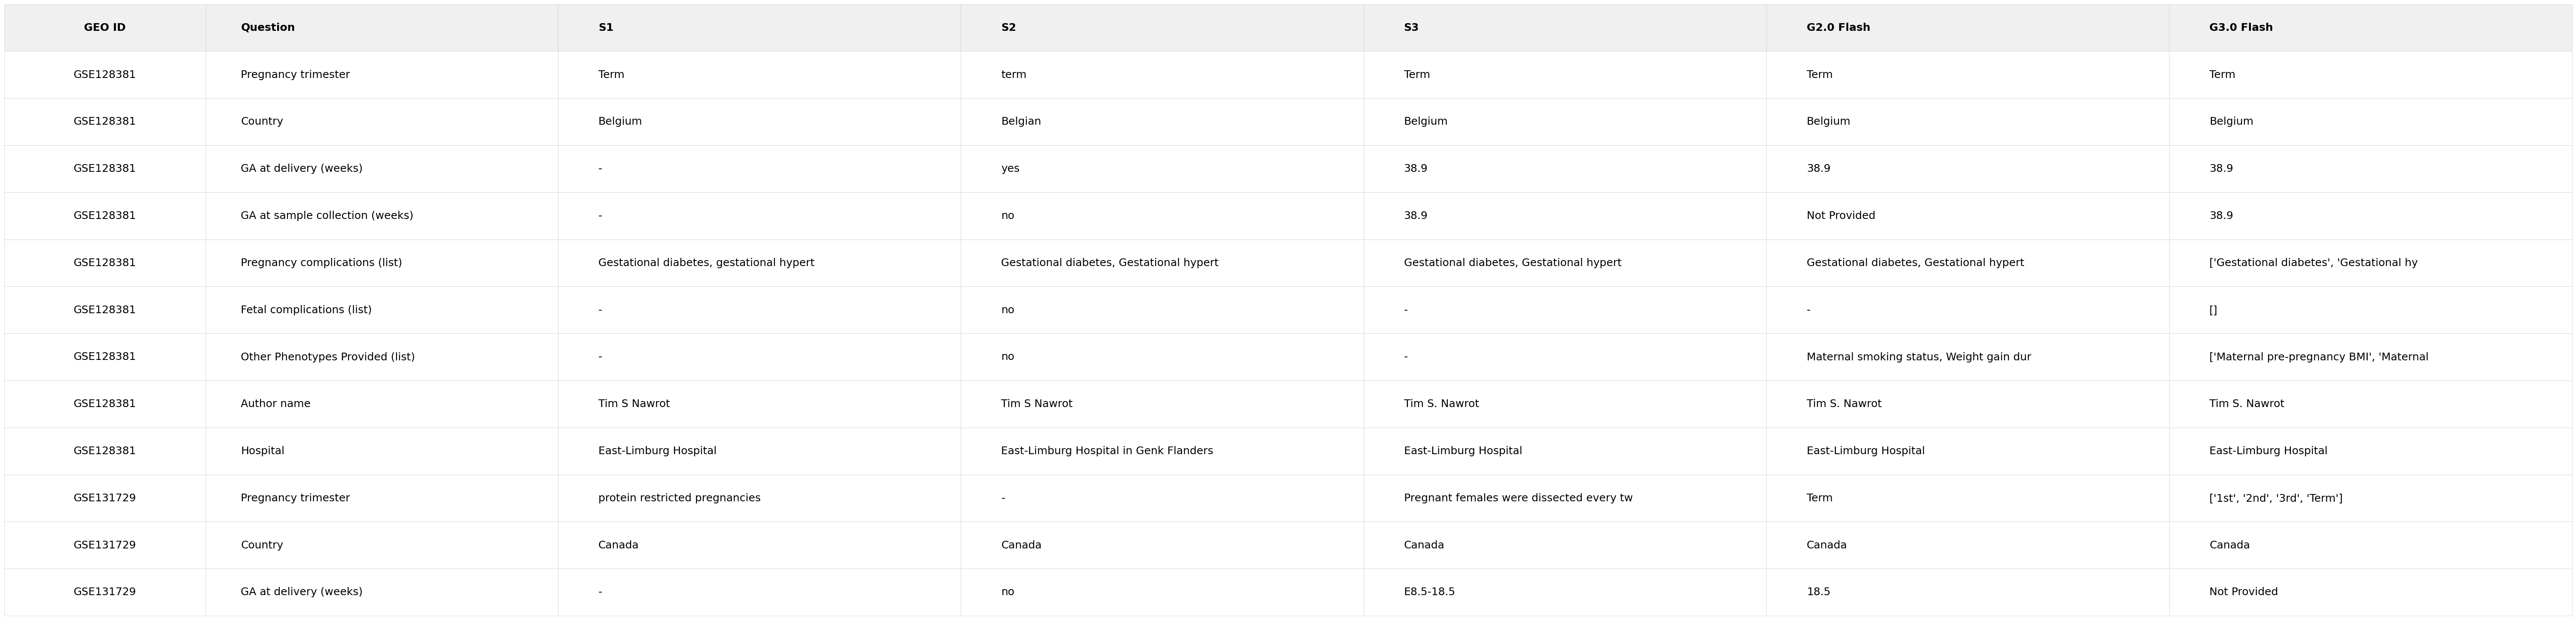

Saved as compare_all_top20.png


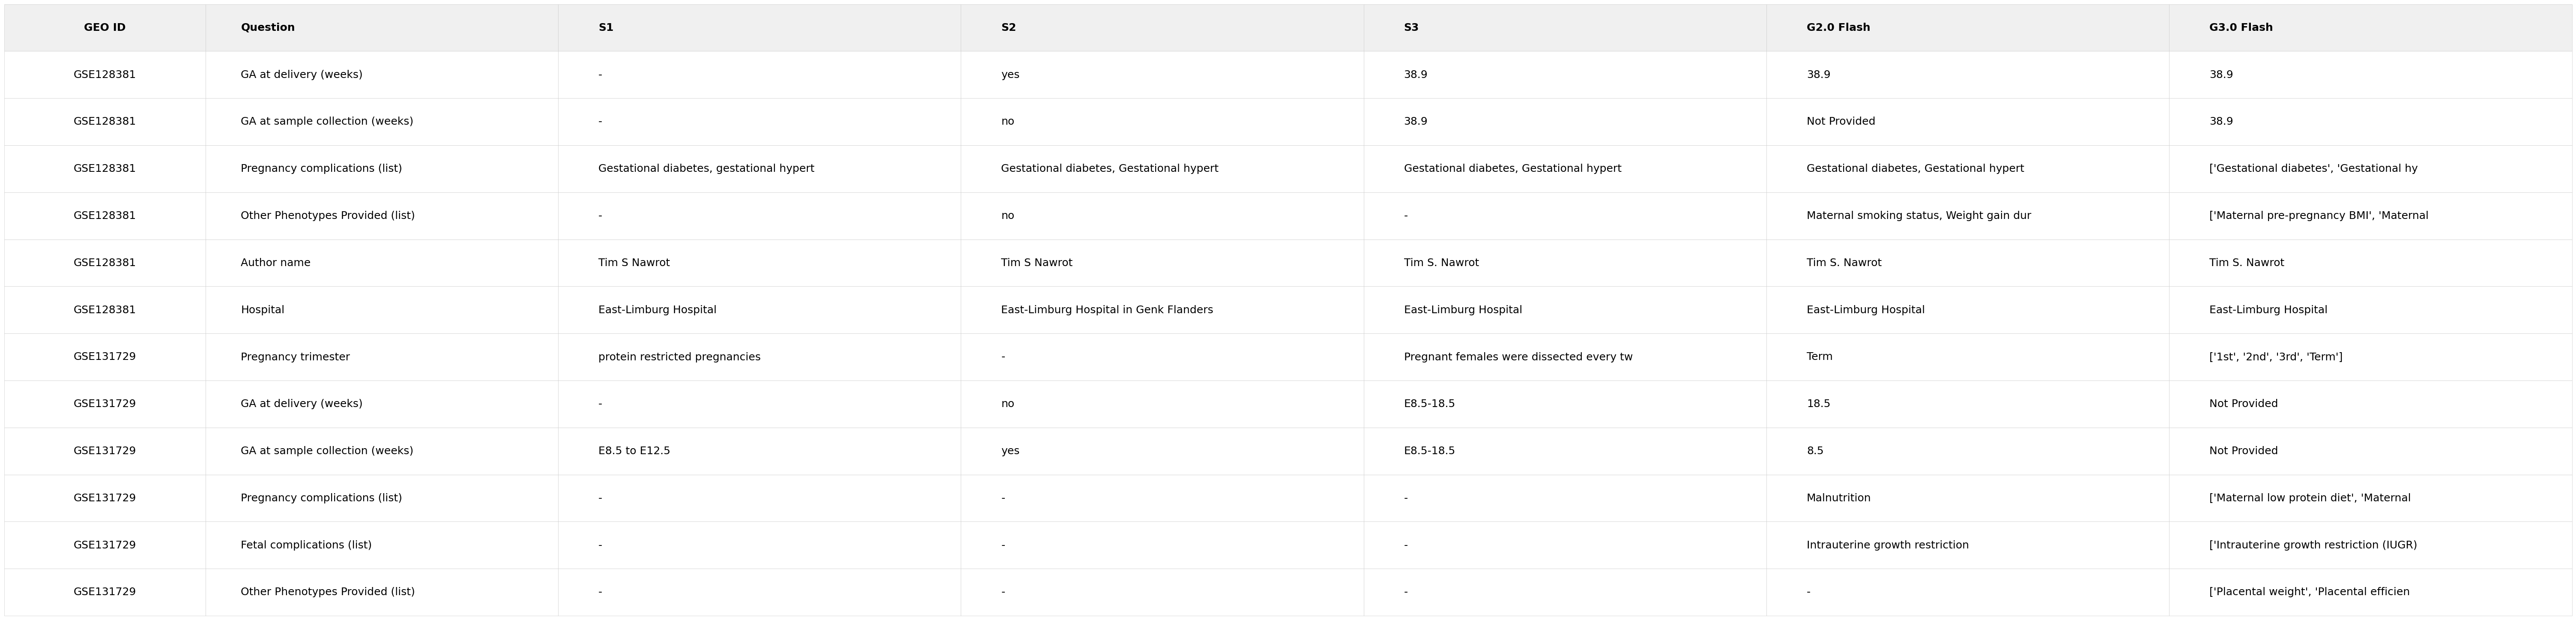

Saved as compare_disagree_top20.png


In [69]:
def save_compare_table(df, filename):
    n_rows = len(df)
    fig_height = max(8, n_rows * 1.2)
    fig, ax = plt.subplots(figsize=(60, fig_height))
    ax.axis("off")

    col_widths = [0.08, 0.14, 0.16, 0.16, 0.16, 0.16, 0.16]

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns.tolist(),
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(18)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        cell.set_linewidth(0.5)
        cell.set_height(1.0 / n_rows)

        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold", color="black")
        else:
            cell.set_facecolor("white")
            cell.set_text_props(color="black")

        if col in [1, 2, 3, 4, 5, 6]:
            cell.set_text_props(ha="left")
            cell._loc = "left"

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved as {filename}")


# drop the agreement columns
cols_to_show = ["GEO ID", "Question", "S1", "S2", "S3", "G2.0 Flash", "G3.0 Flash"]

save_compare_table(compare_df[cols_to_show].head(12), "compare_all_top20.png")
save_compare_table(disagree_compare[cols_to_show].head(12), "compare_disagree_top20.png")

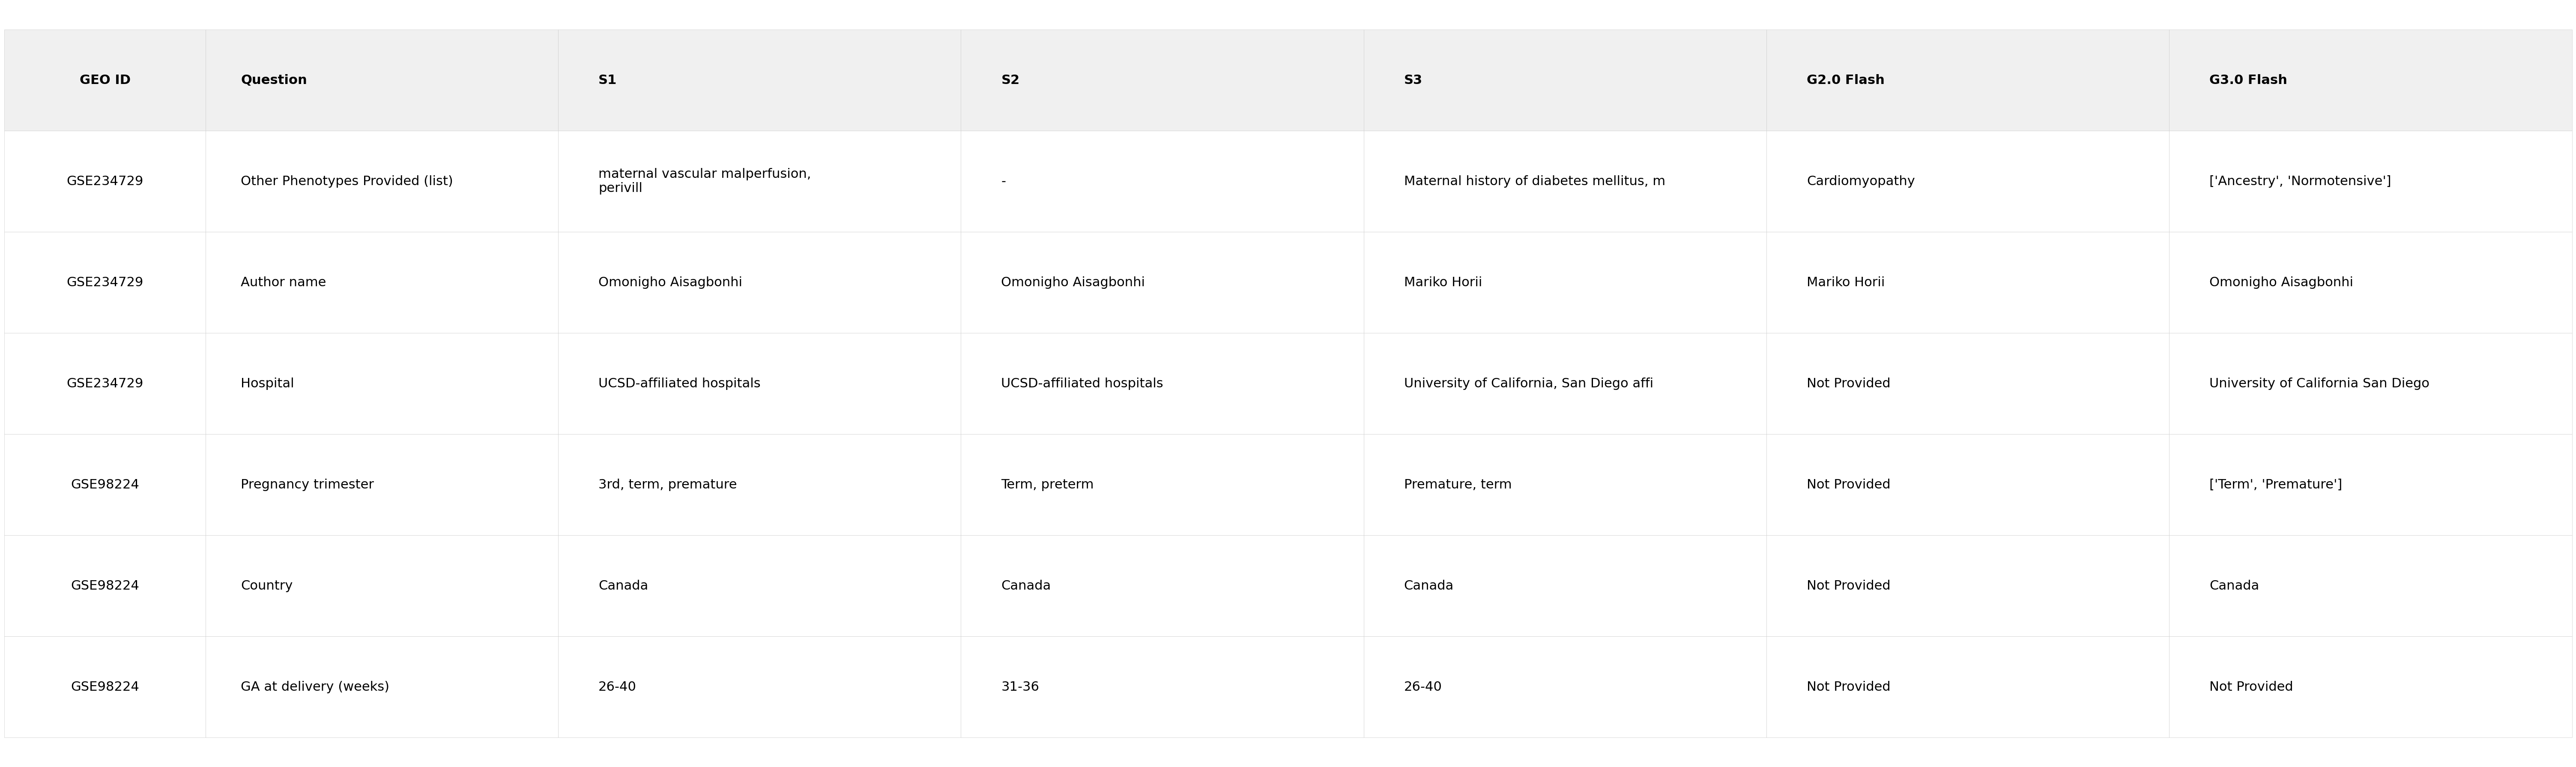

Saved compare_all_page11.png


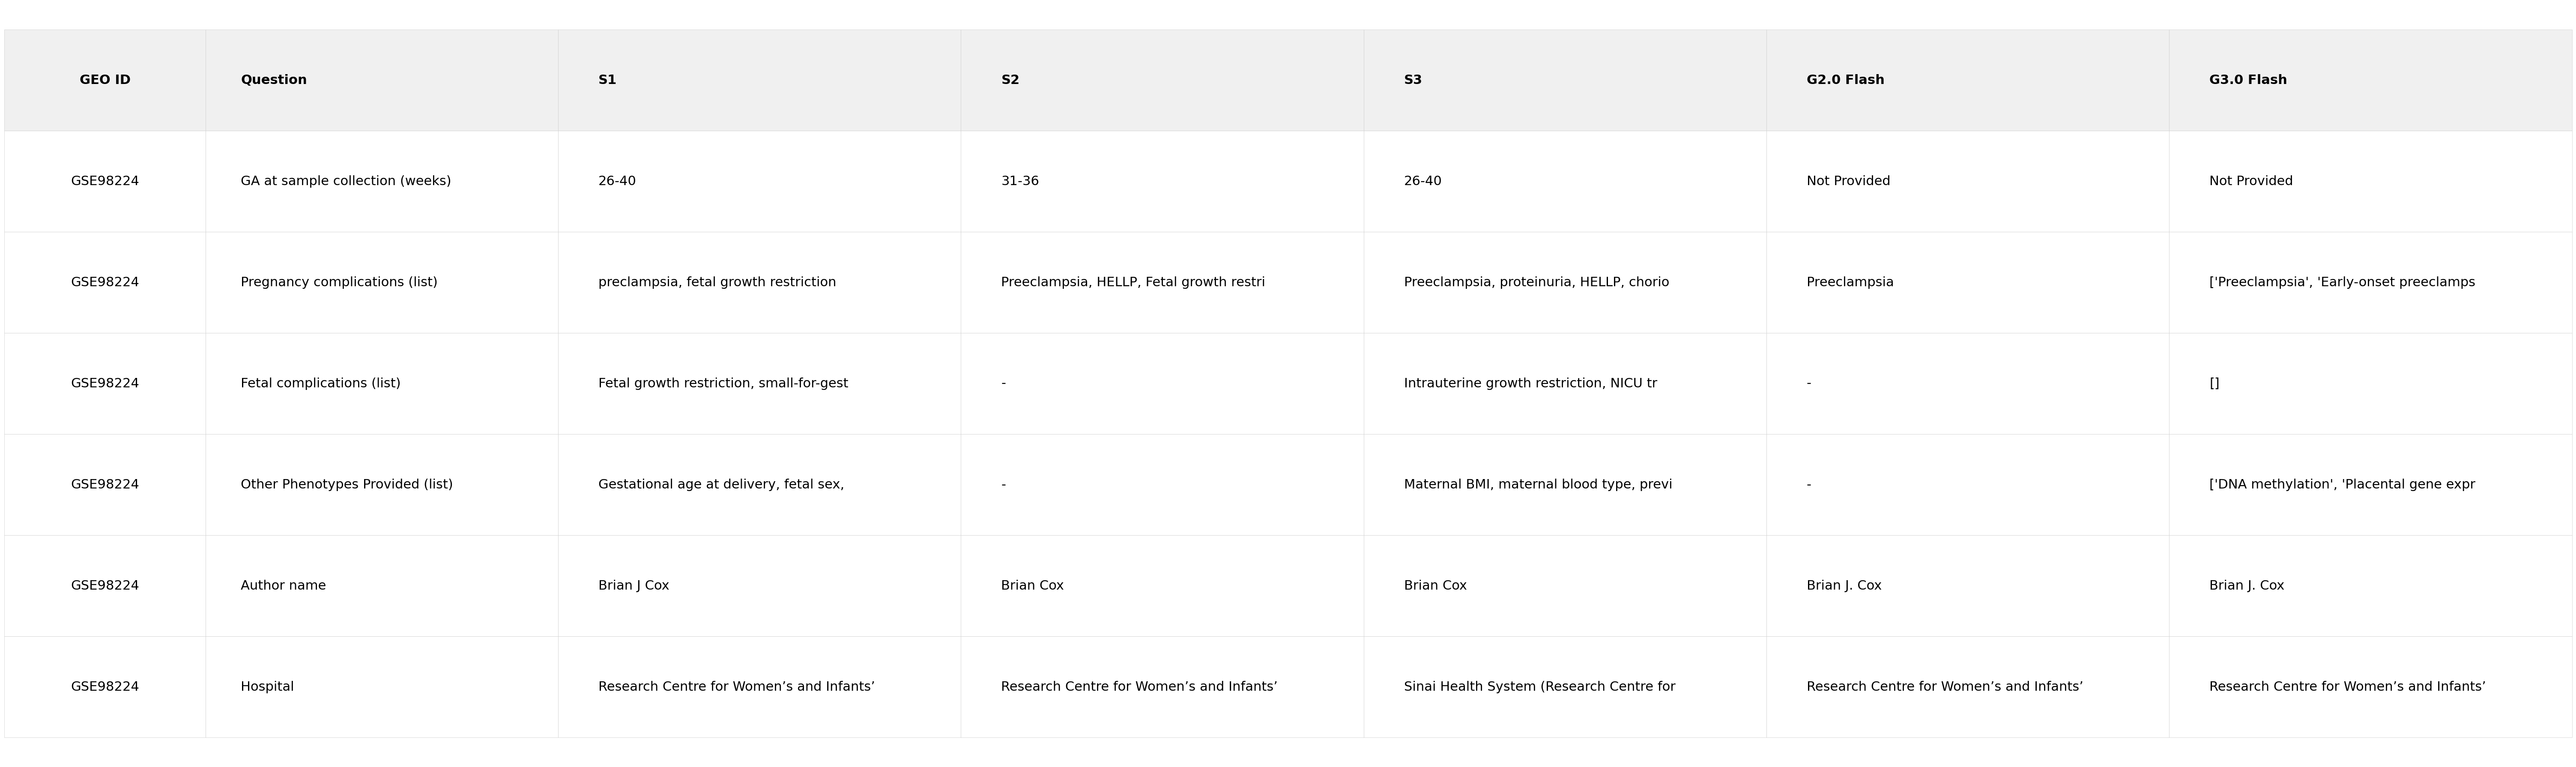

Saved compare_all_page12.png


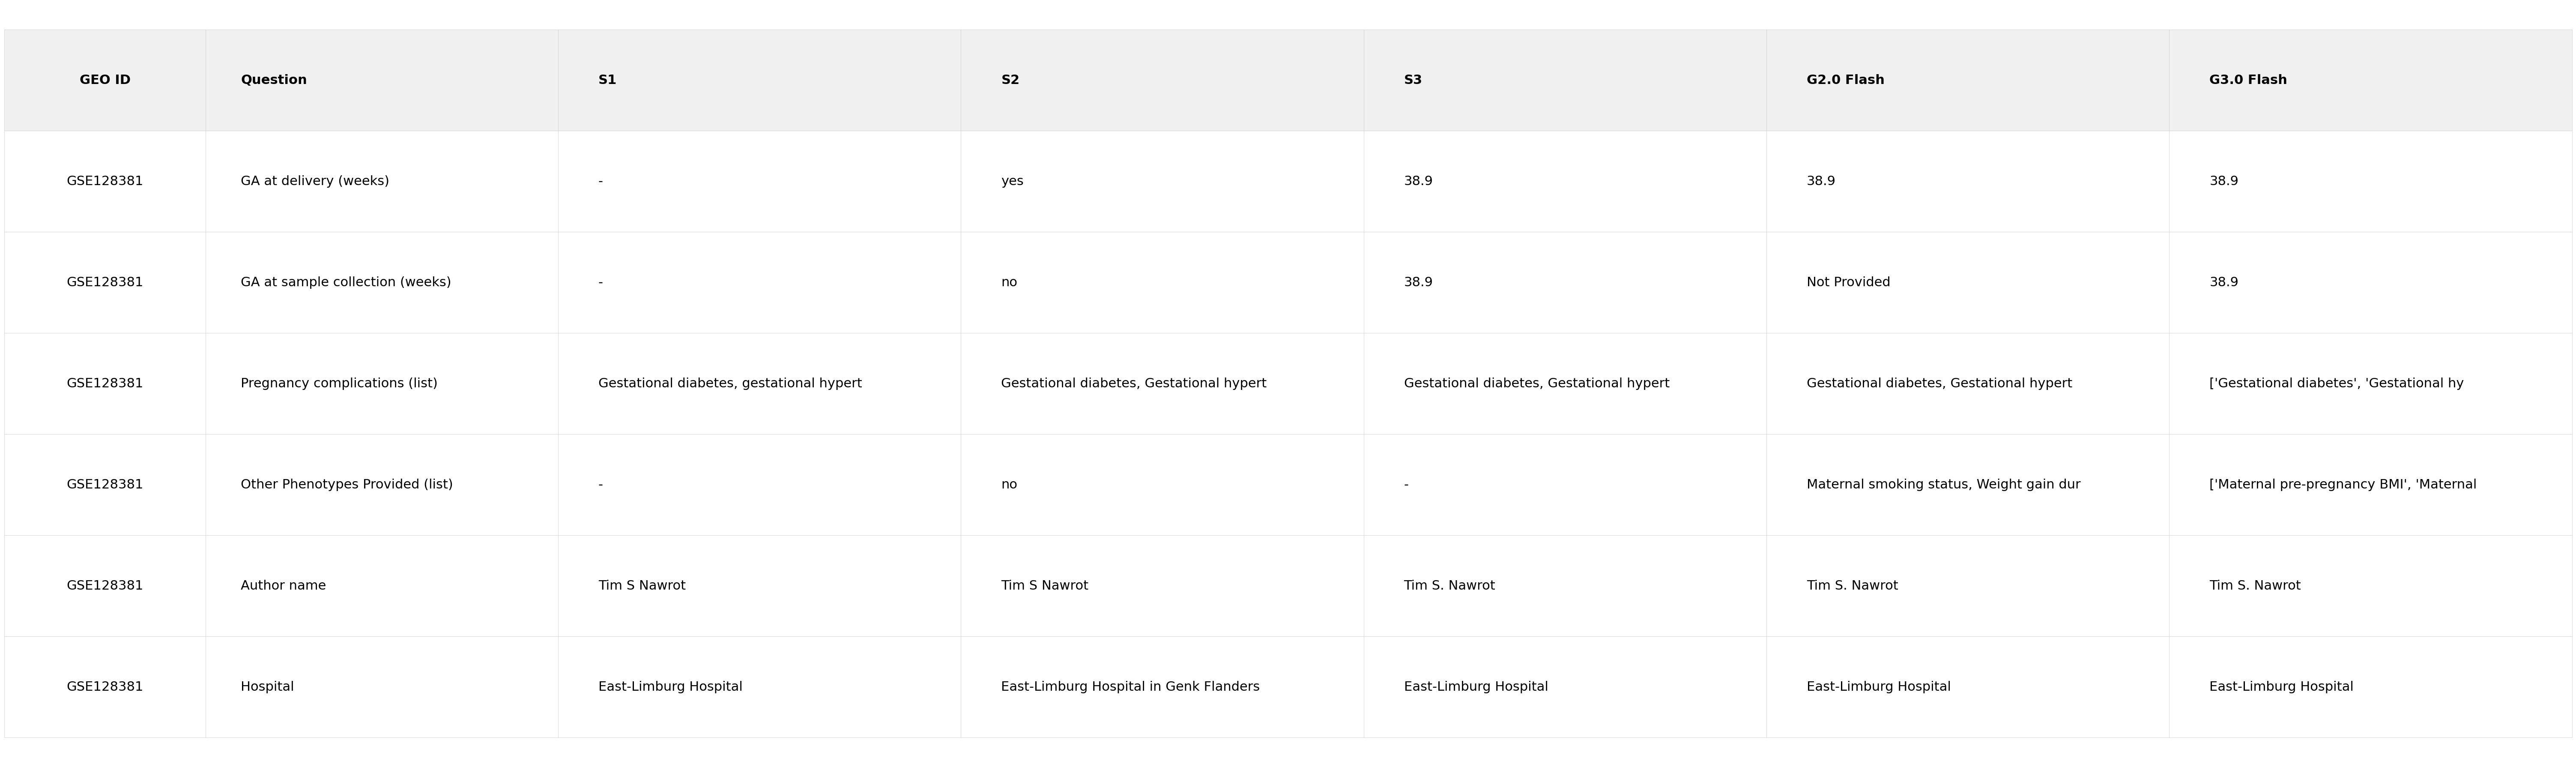

Saved compare_disagree_page1.png


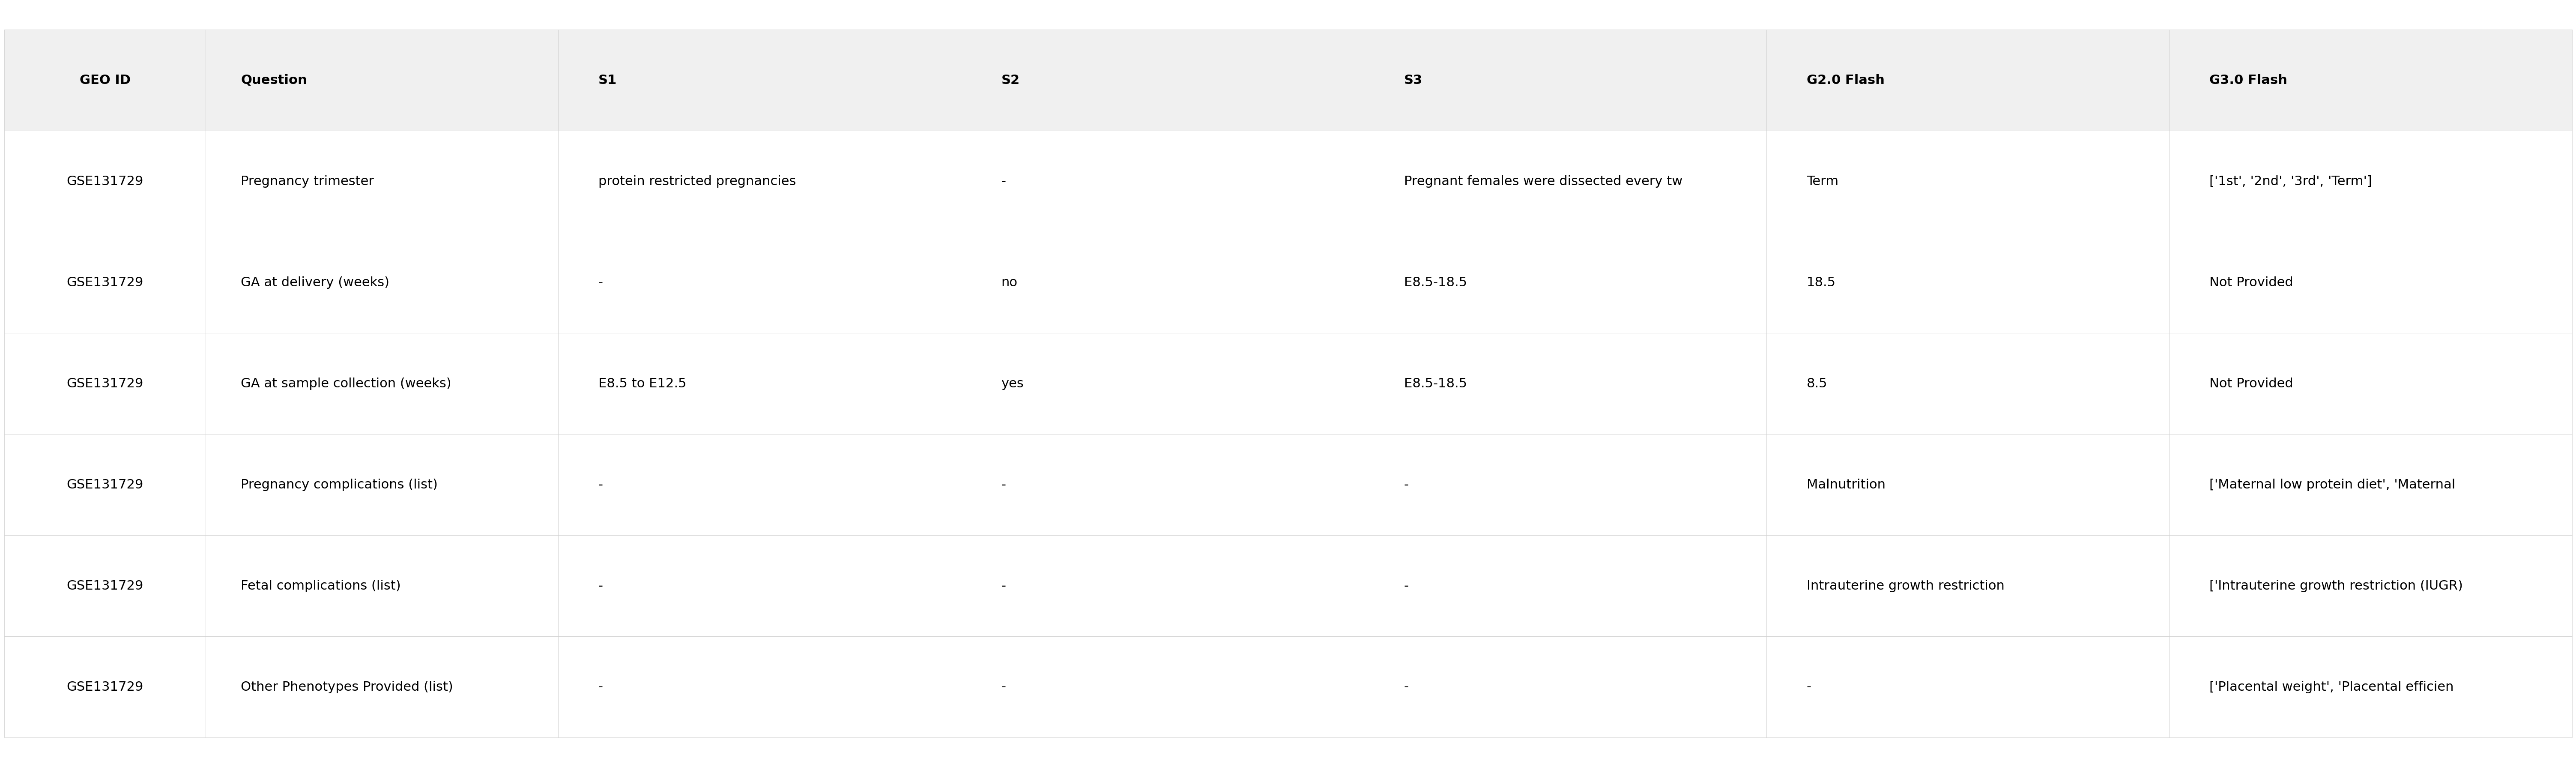

Saved compare_disagree_page2.png


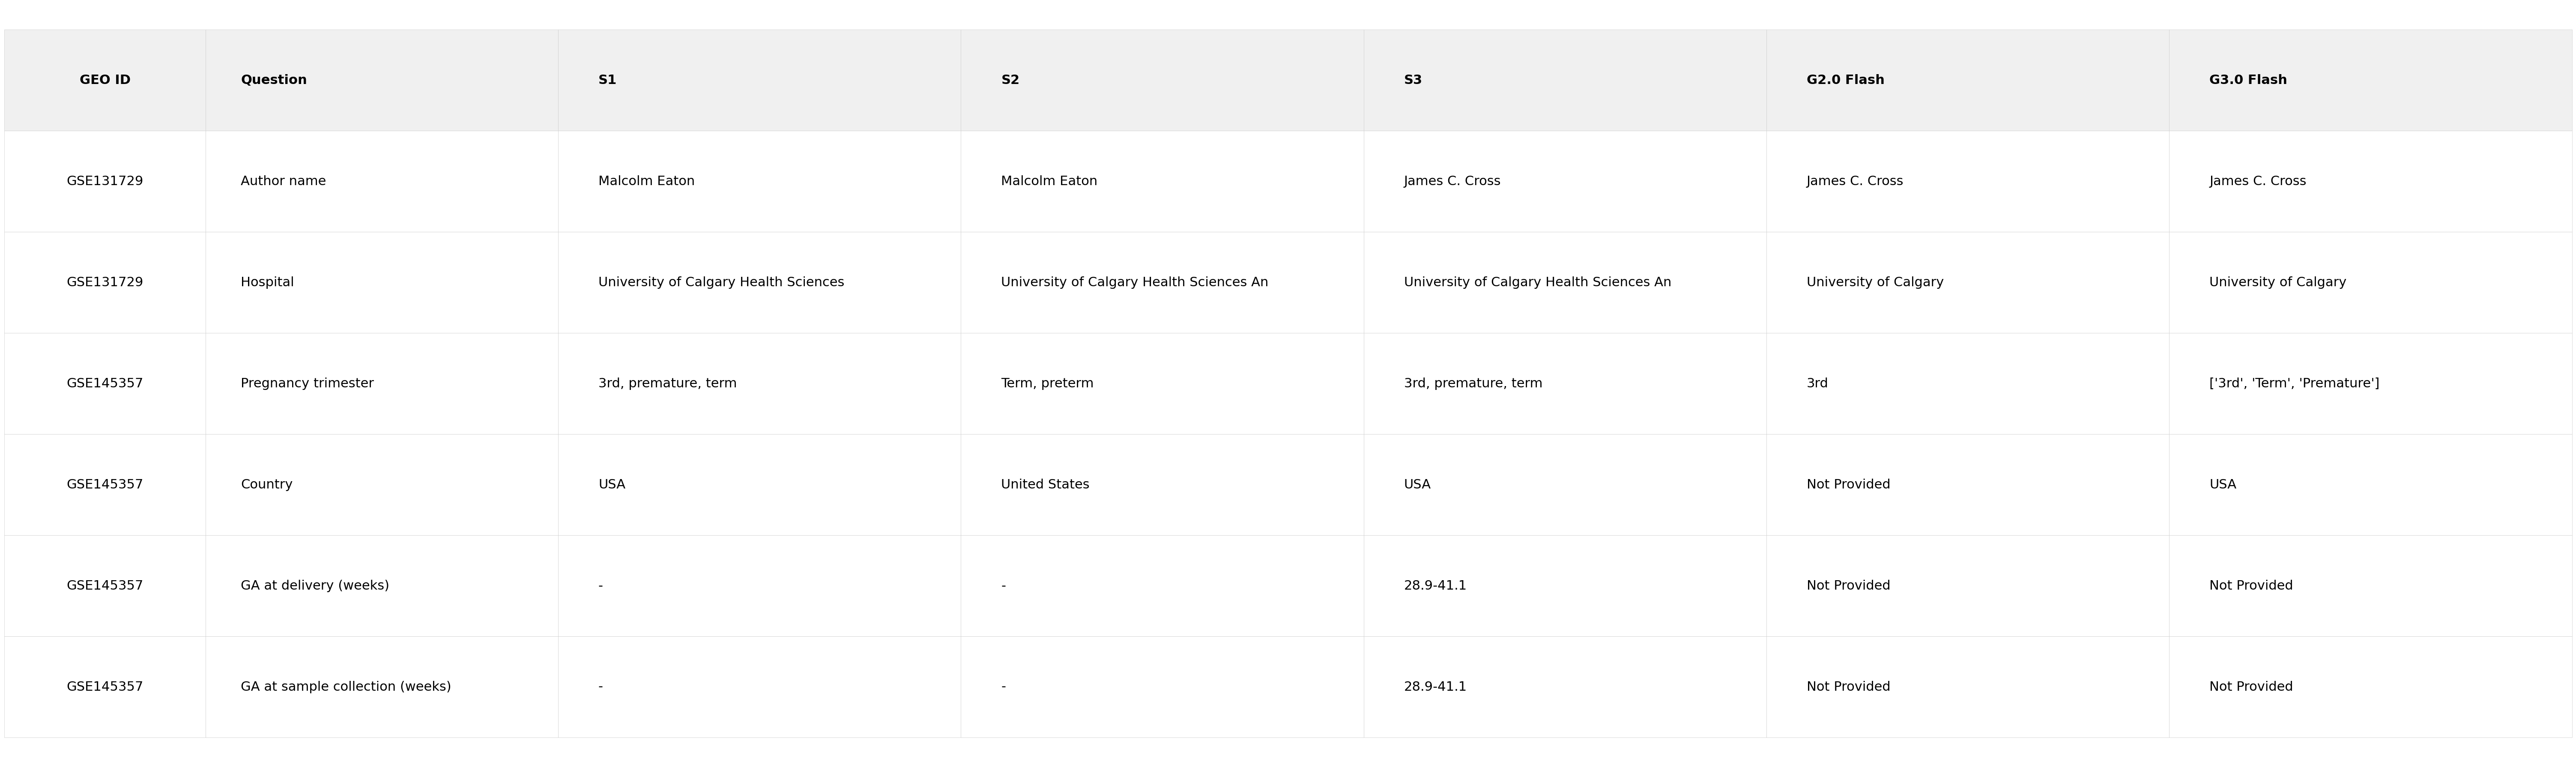

Saved compare_disagree_page3.png


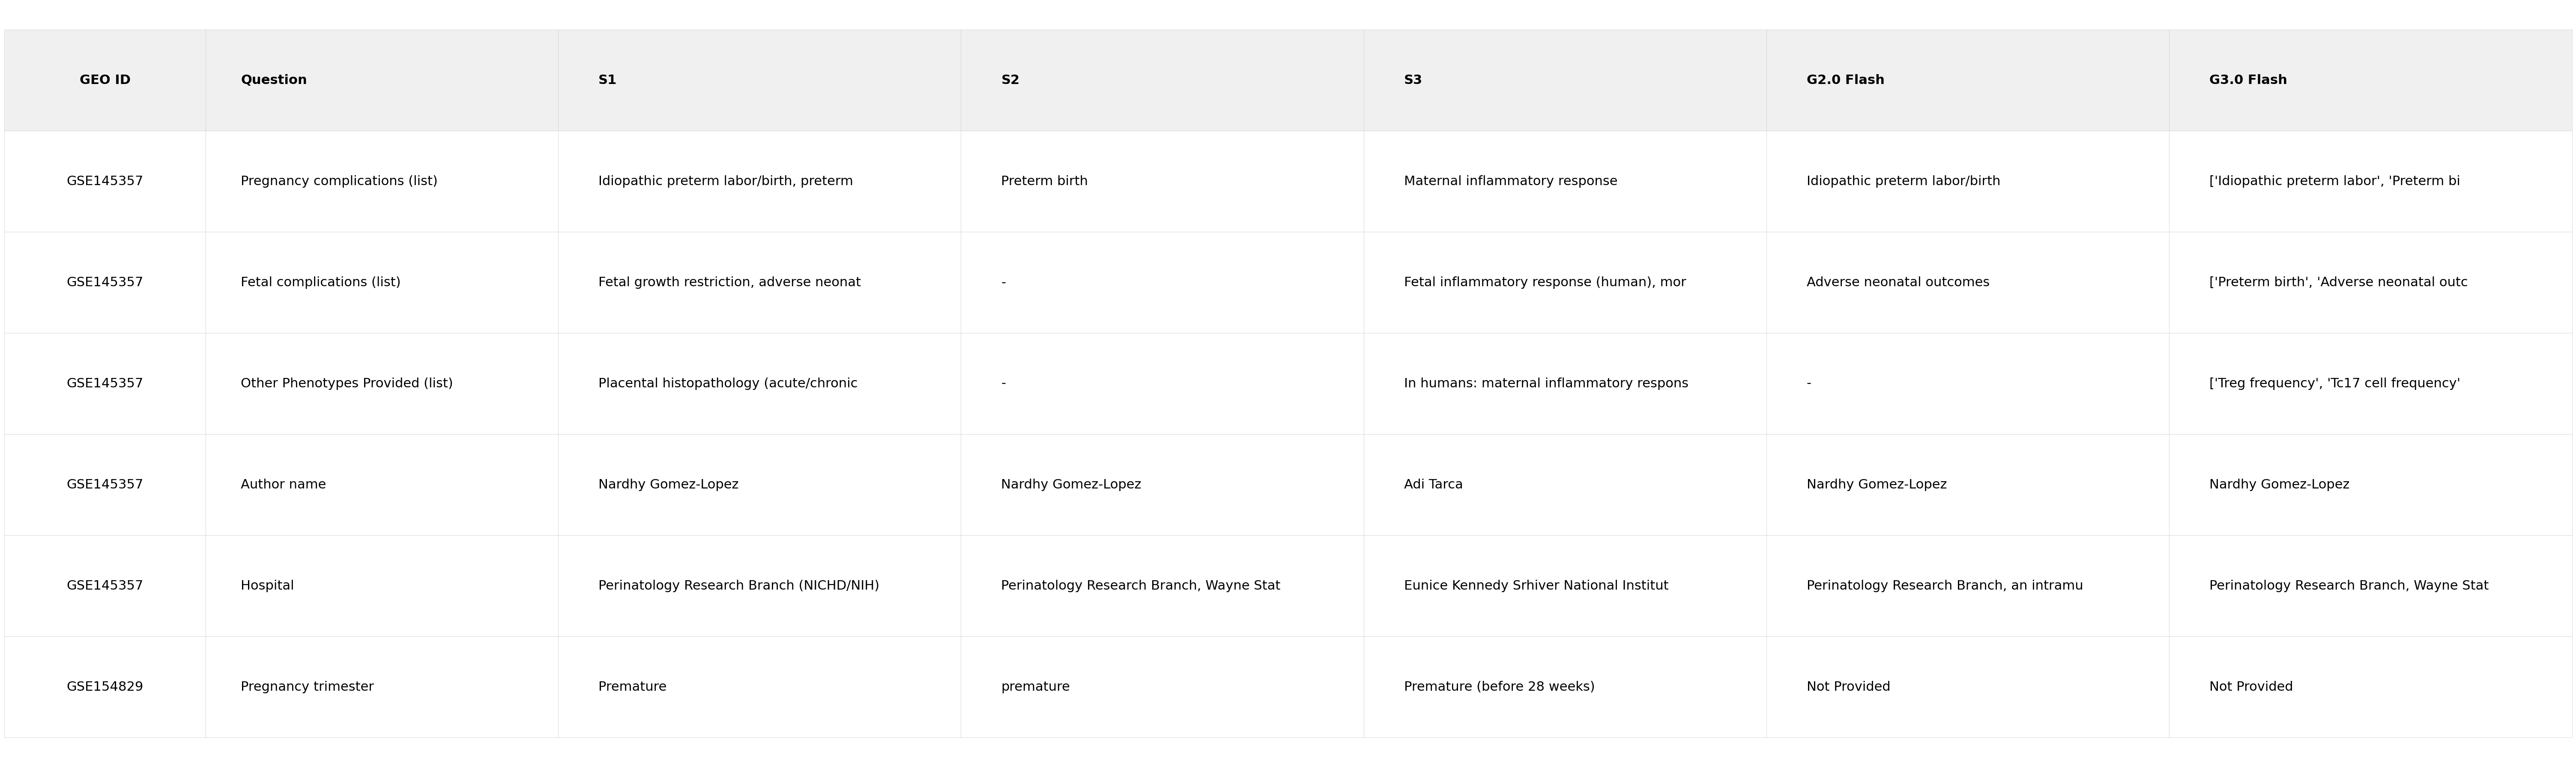

Saved compare_disagree_page4.png


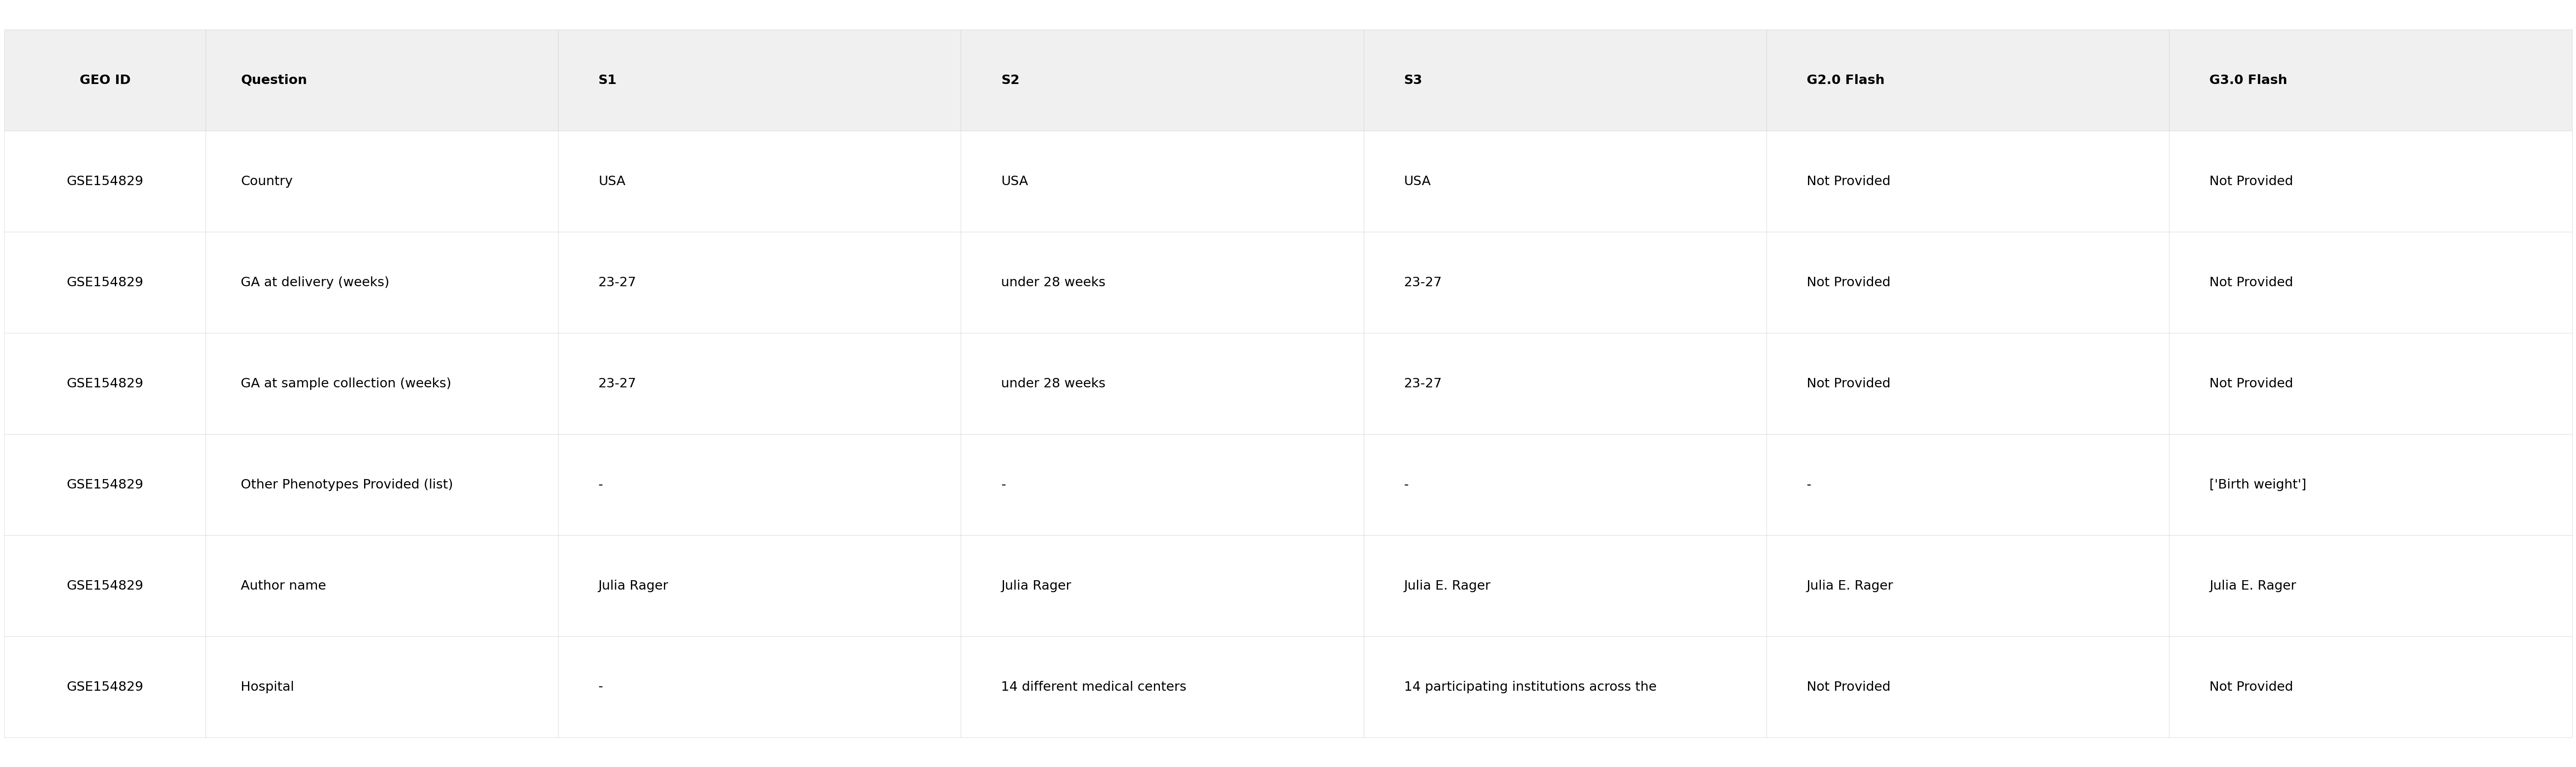

Saved compare_disagree_page5.png


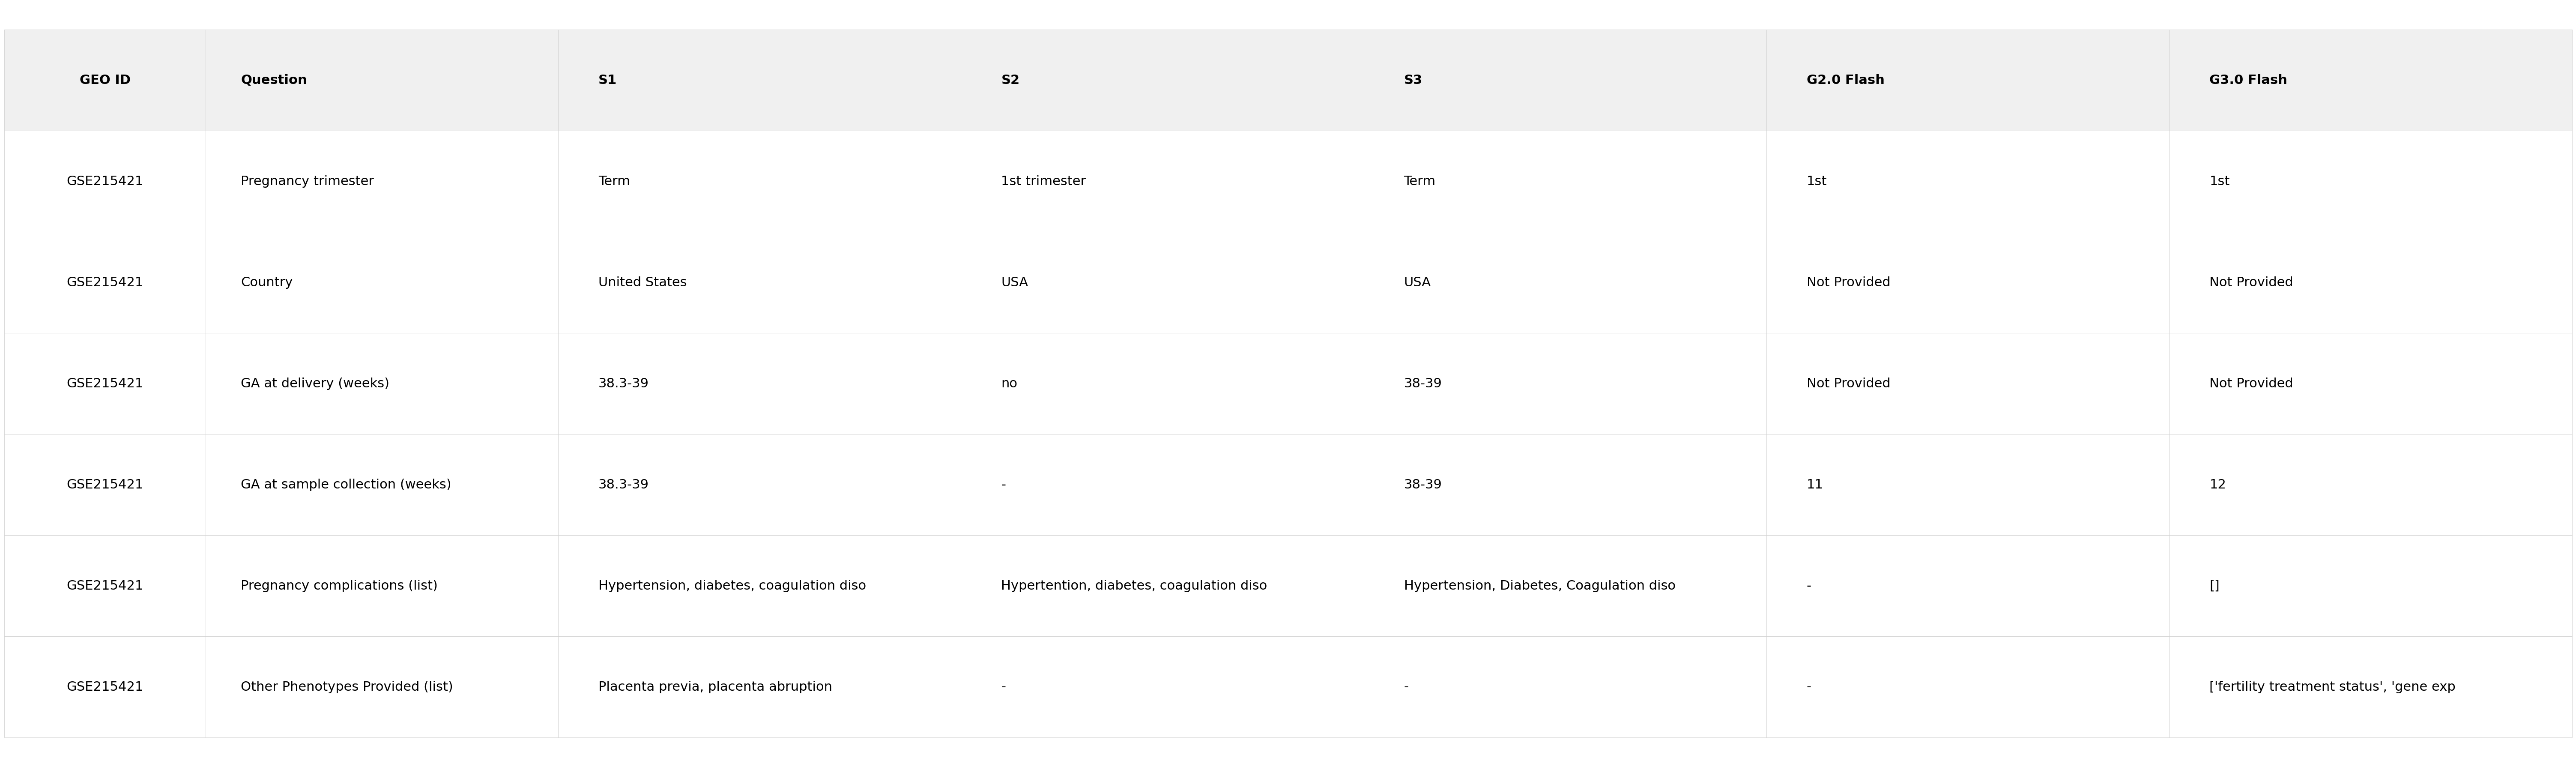

Saved compare_disagree_page6.png


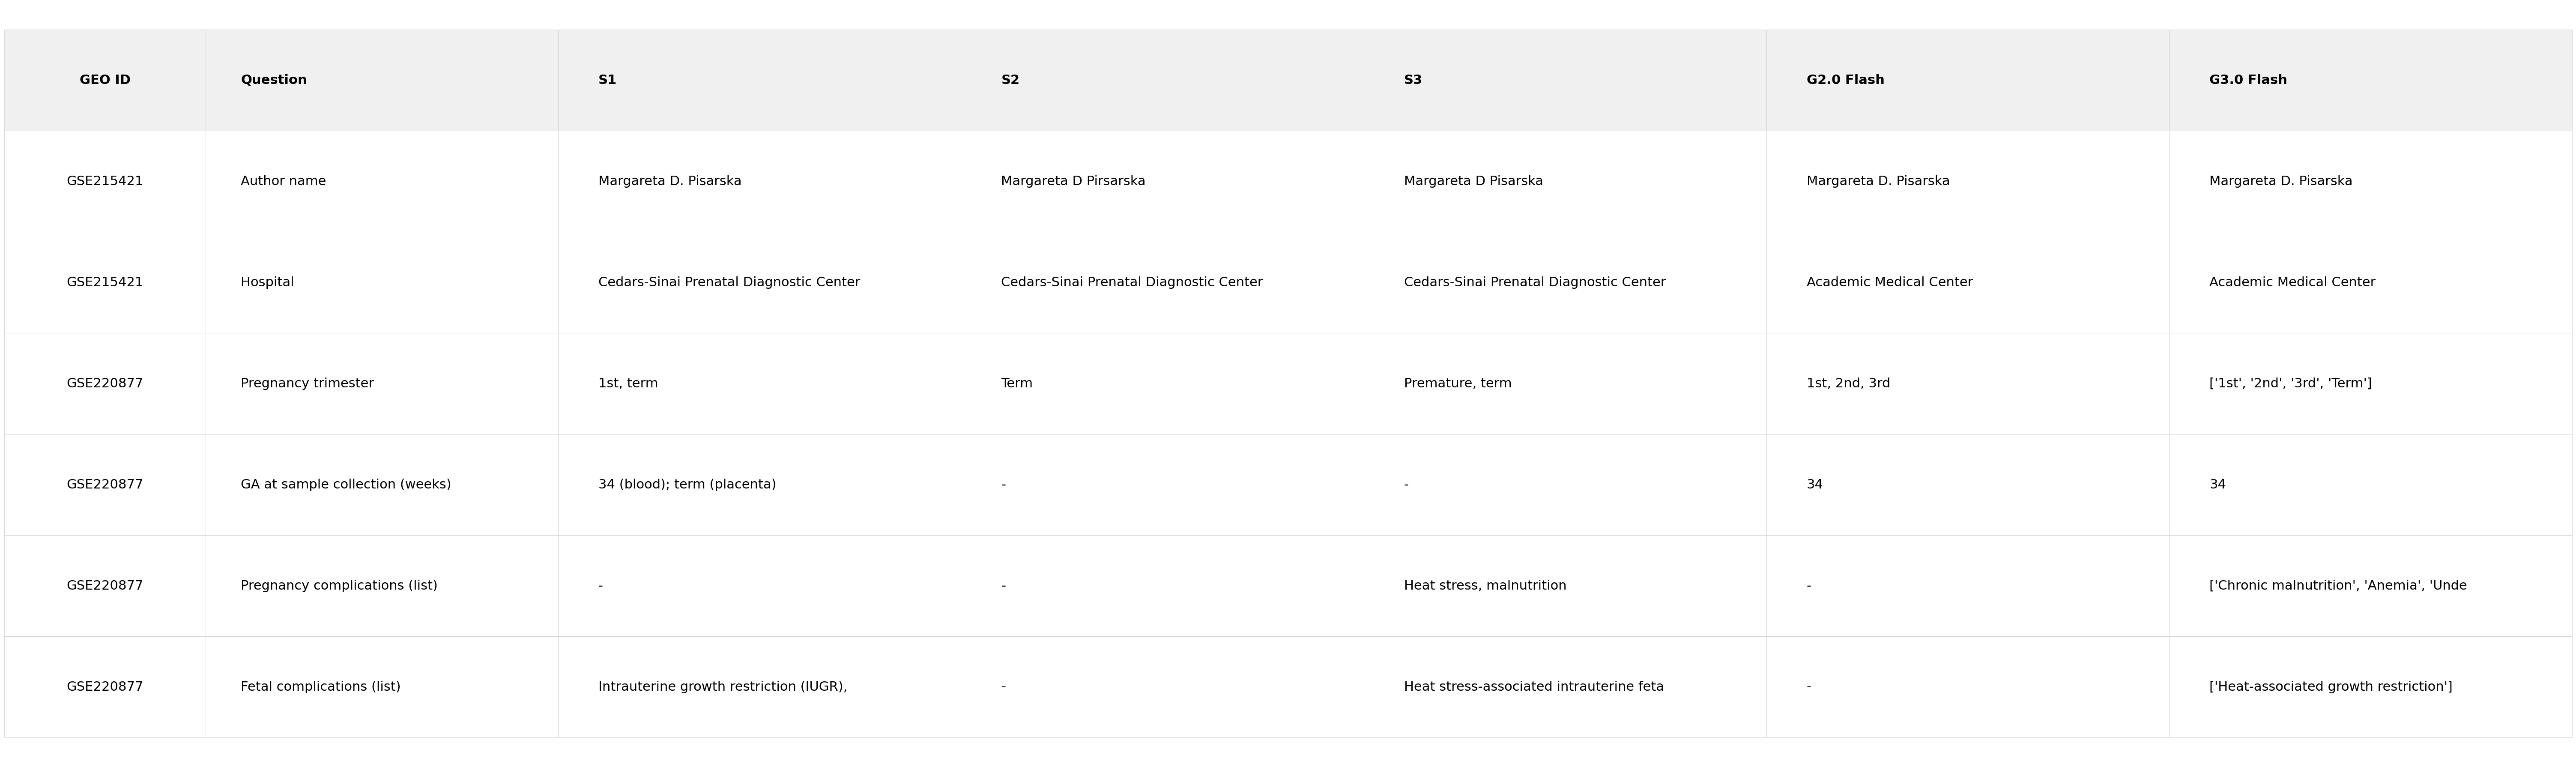

Saved compare_disagree_page7.png


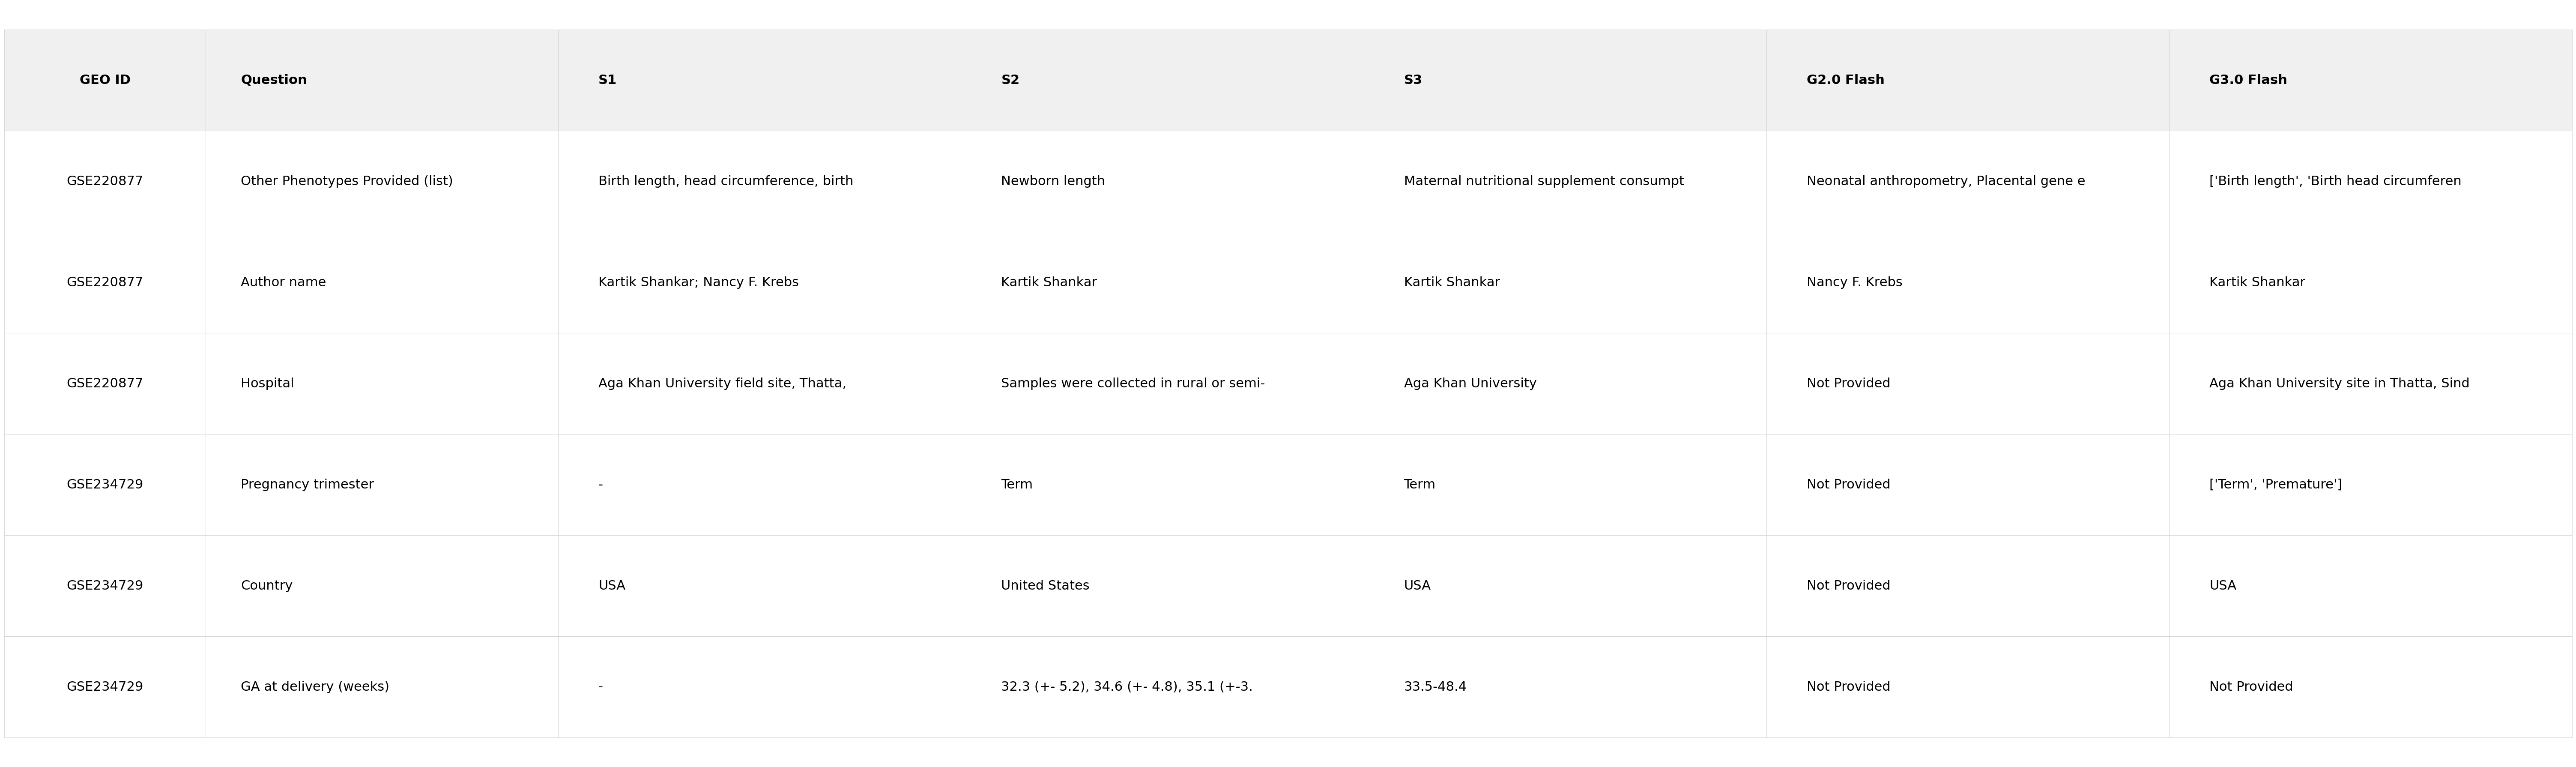

Saved compare_disagree_page8.png


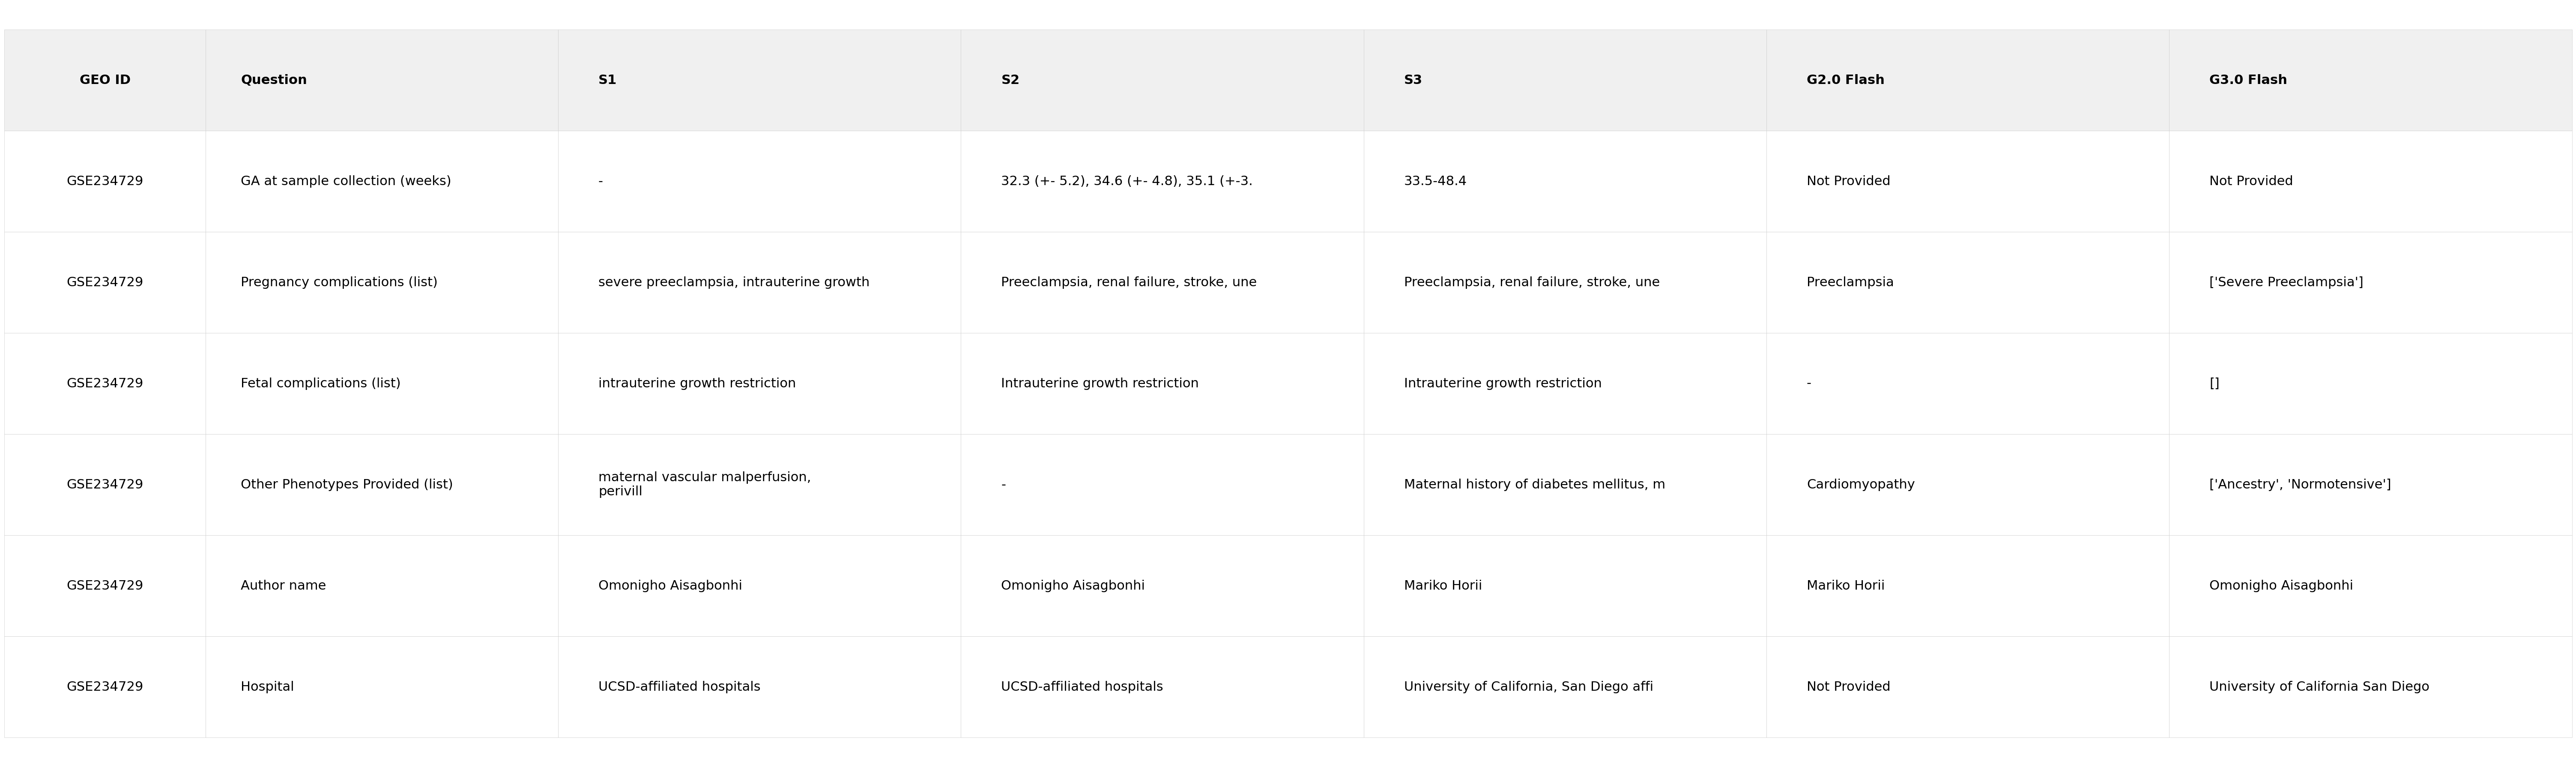

Saved compare_disagree_page9.png


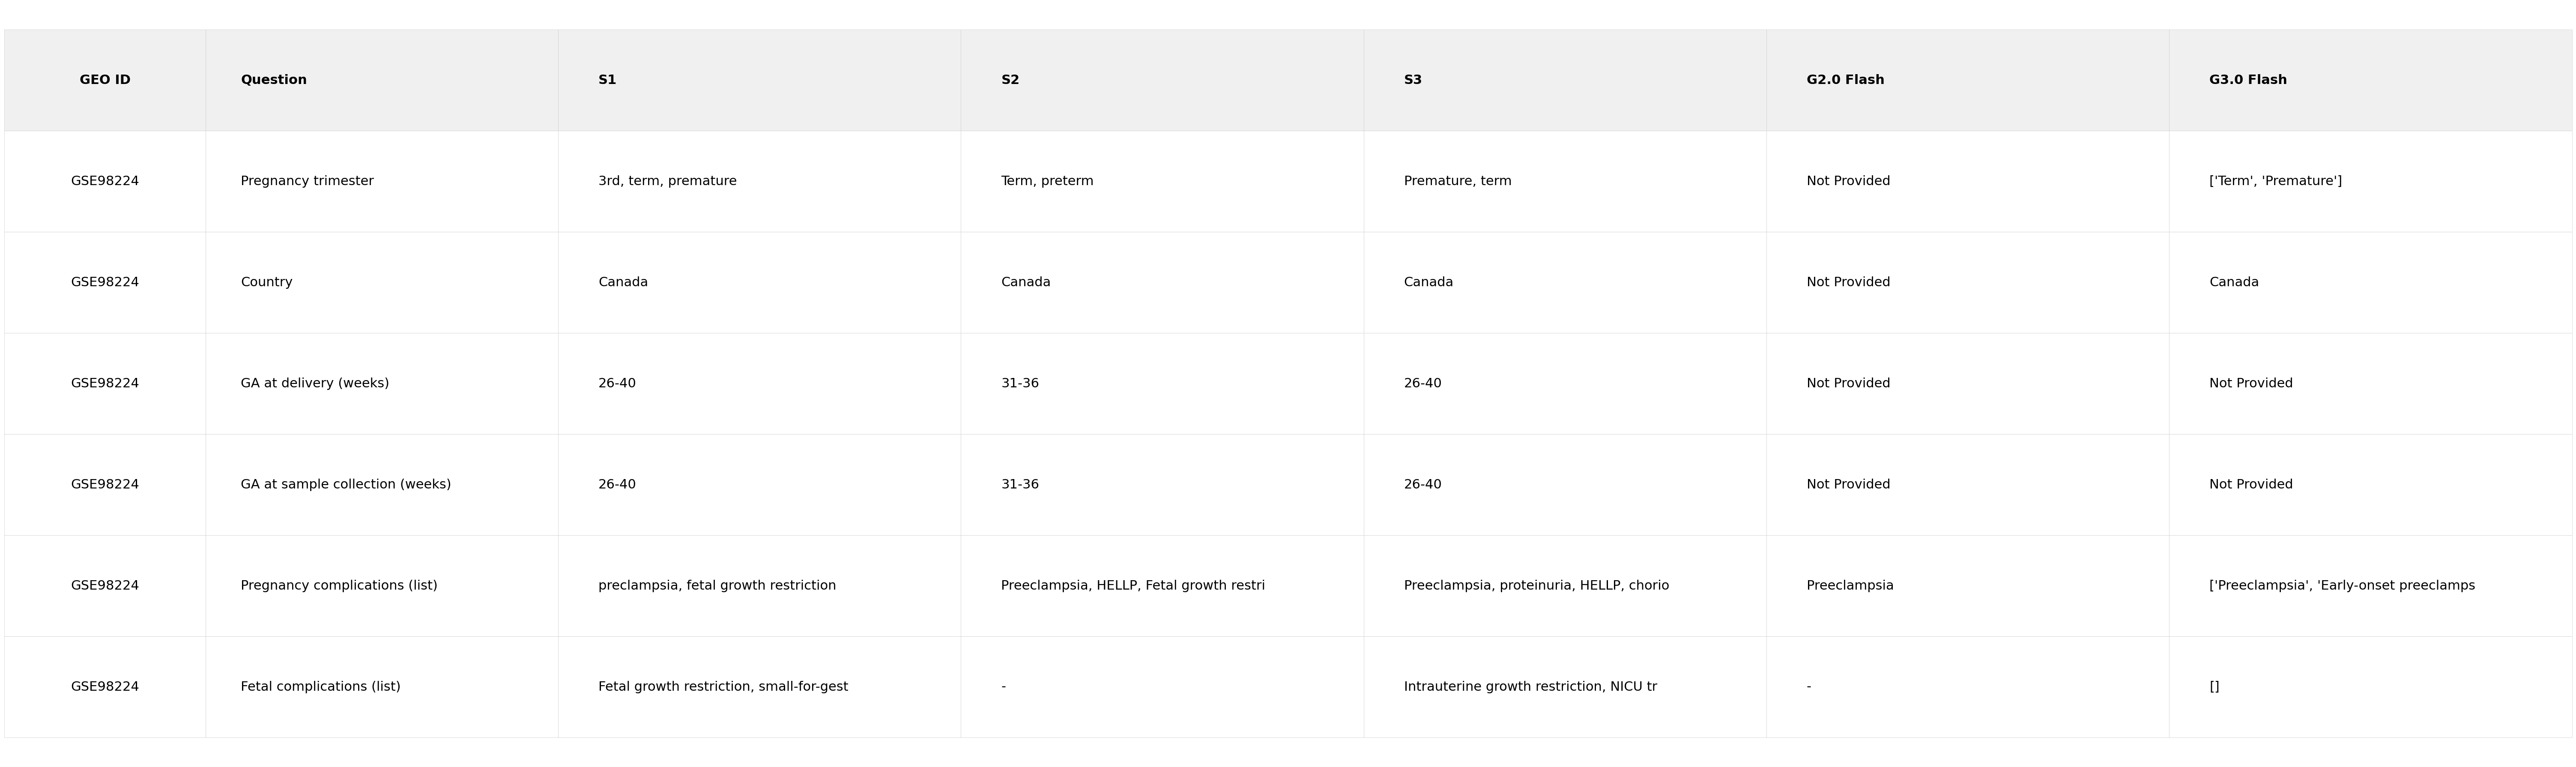

Saved compare_disagree_page10.png


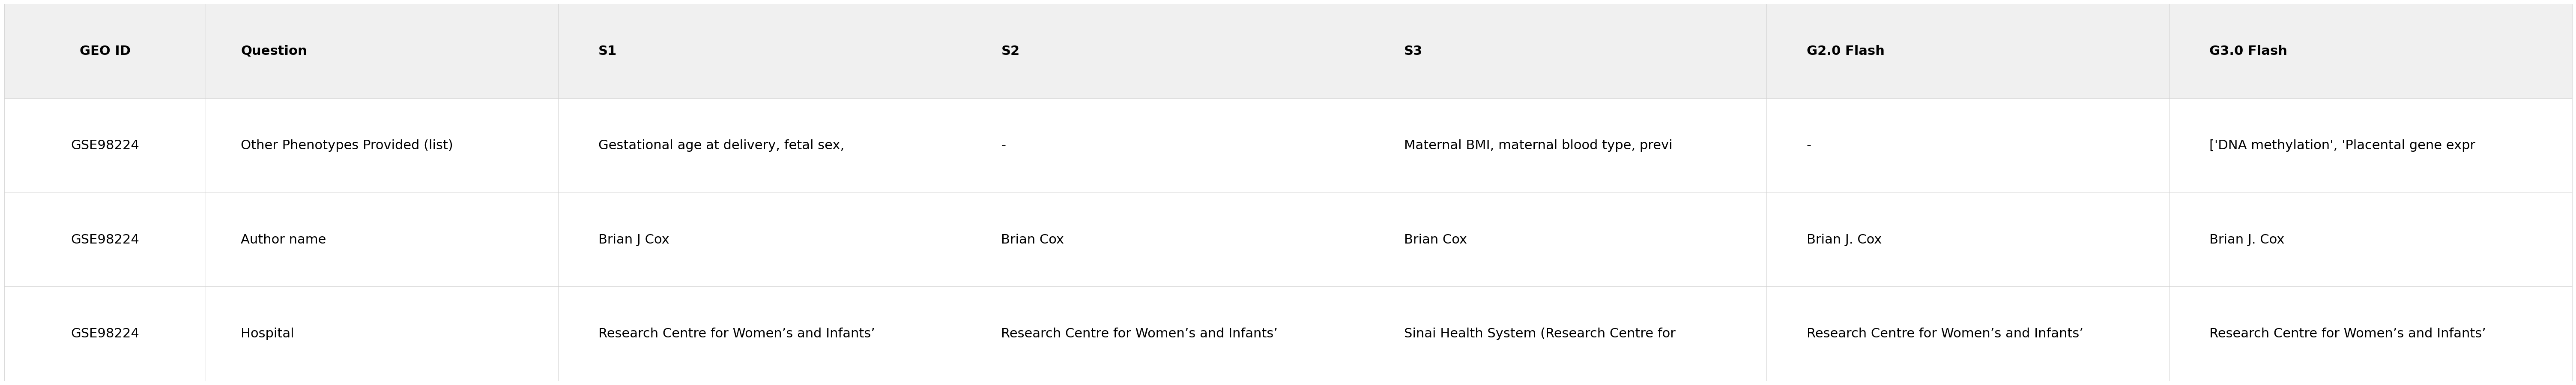

Saved compare_disagree_page11.png


In [70]:
import matplotlib.pyplot as plt
import math

def save_compare_table_paged(df, filename_prefix, rows_per_page=6):
    cols_to_show = ["GEO ID", "Question", "S1", "S2", "S3", "G2.0 Flash", "G3.0 Flash"]
    df = df[cols_to_show].reset_index(drop=True)
    n_pages = math.ceil(len(df) / rows_per_page)

    for page in range(n_pages):
        chunk = df.iloc[page * rows_per_page:(page + 1) * rows_per_page]
        n_rows = len(chunk)

        fig, ax = plt.subplots(figsize=(60, n_rows * 3))
        ax.axis("off")

        col_widths = [0.08, 0.14, 0.16, 0.16, 0.16, 0.16, 0.16]

        table = ax.table(
            cellText=chunk.values,
            colLabels=chunk.columns.tolist(),
            cellLoc="center",
            loc="center",
            colWidths=col_widths,
        )

        table.auto_set_font_size(False)
        table.set_fontsize(22)

        for (row, col), cell in table.get_celld().items():
            cell.set_edgecolor("#cccccc")
            cell.set_linewidth(0.5)
            cell.set_height(0.8 / n_rows)

            if row == 0:
                cell.set_facecolor("#f0f0f0")
                cell.set_text_props(fontweight="bold", color="black")
            else:
                cell.set_facecolor("white")
                cell.set_text_props(color="black")

            if col in [1, 2, 3, 4, 5, 6]:
                cell.set_text_props(ha="left")
                cell._loc = "left"

        plt.tight_layout()
        fname = f"{filename_prefix}_page{page+1}.png"
        plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor="white")
        plt.show()
        plt.close()
        print(f"Saved {fname}")


save_compare_table_paged(compare_df, "compare_all")
save_compare_table_paged(disagree_compare, "compare_disagree")

NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0
Total: 72 rows
Students disagree among themselves: 50 rows
Gemini 2.0 differs from student majority: 48 rows
Gemini 3.0 differs from student majority: 47 rows



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash
0,GSE128381,Pregnancy trimester,Term,term,Term,Term,Term
1,GSE128381,Country,Belgium,Belgian,Belgium,Belgium,Belgium
2,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9
3,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9
4,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy"
5,GSE128381,Fetal complications (list),-,no,-,-,[]
6,GSE128381,Other Phenotypes Provided (list),-,no,-,"Maternal smoking status, Weight gain dur","['Maternal pre-pregnancy BMI', 'Maternal"
7,GSE128381,Author name,Tim S Nawrot,Tim S Nawrot,Tim S. Nawrot,Tim S. Nawrot,Tim S. Nawrot
8,GSE128381,Hospital,East-Limburg Hospital,East-Limburg Hospital in Genk Flanders,East-Limburg Hospital,East-Limburg Hospital,East-Limburg Hospital
9,GSE131729,Pregnancy trimester,protein restricted pregnancies,-,Pregnant females were dissected every tw,Term,"['1st', '2nd', '3rd', 'Term']"




DISAGREEMENTS ONLY — 63 rows



,GEO ID,Question,S1,S2,S3,G2.0 Flash,G3.0 Flash
0,GSE128381,GA at delivery (weeks),-,yes,38.9,38.9,38.9
1,GSE128381,GA at sample collection (weeks),-,no,38.9,Not Provided,38.9
2,GSE128381,Pregnancy complications (list),"Gestational diabetes, gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","Gestational diabetes, Gestational hypert","['Gestational diabetes', 'Gestational hy"
3,GSE128381,Other Phenotypes Provided (list),-,no,-,"Maternal smoking status, Weight gain dur","['Maternal pre-pregnancy BMI', 'Maternal"
4,GSE128381,Author name,Tim S Nawrot,Tim S Nawrot,Tim S. Nawrot,Tim S. Nawrot,Tim S. Nawrot
5,GSE128381,Hospital,East-Limburg Hospital,East-Limburg Hospital in Genk Flanders,East-Limburg Hospital,East-Limburg Hospital,East-Limburg Hospital
6,GSE131729,Pregnancy trimester,protein restricted pregnancies,-,Pregnant females were dissected every tw,Term,"['1st', '2nd', '3rd', 'Term']"
7,GSE131729,GA at delivery (weeks),-,no,E8.5-18.5,18.5,Not Provided
8,GSE131729,GA at sample collection (weeks),E8.5 to E12.5,yes,E8.5-18.5,8.5,Not Provided
9,GSE131729,Pregnancy complications (list),-,-,-,Malnutrition,"['Maternal low protein diet', 'Maternal"


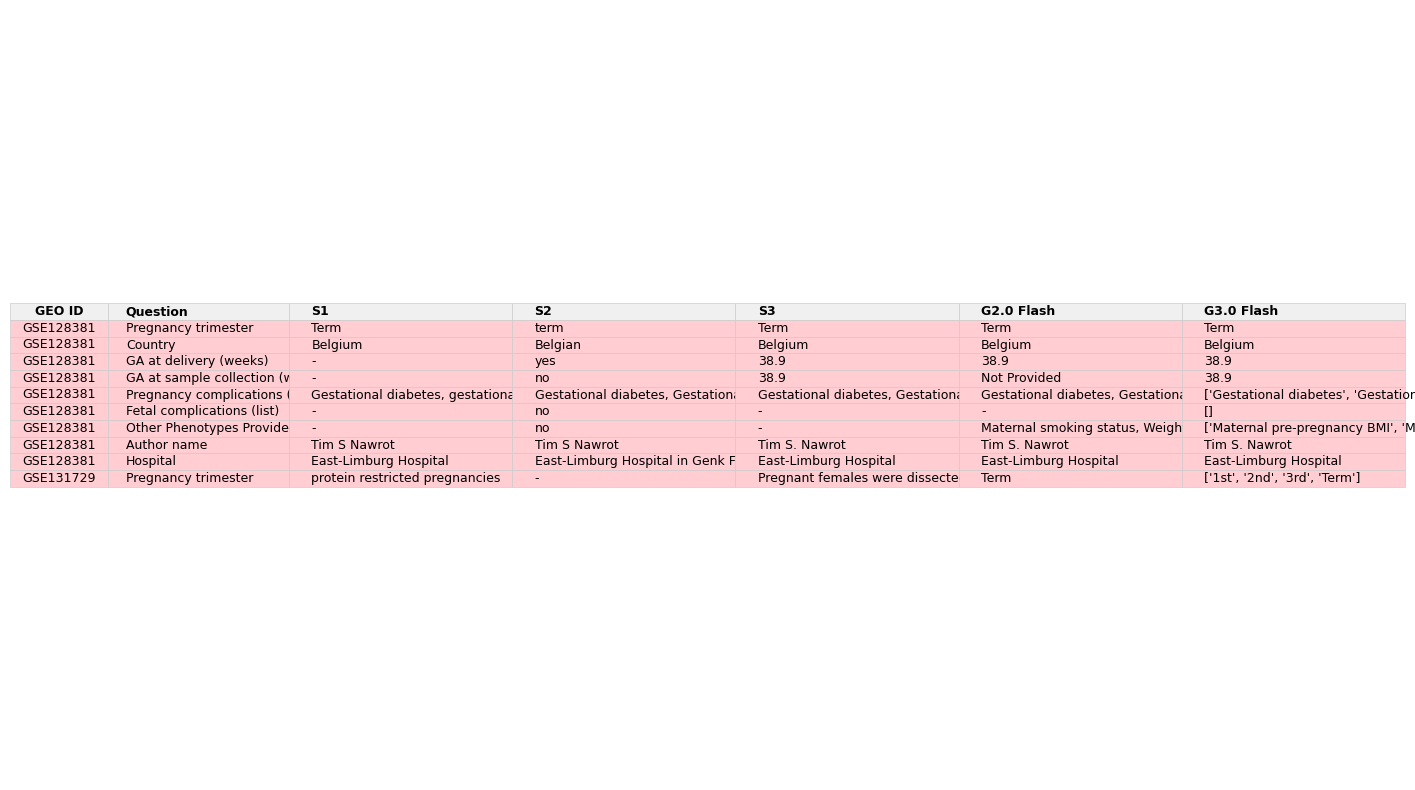

Saved as compare_all_top10.png


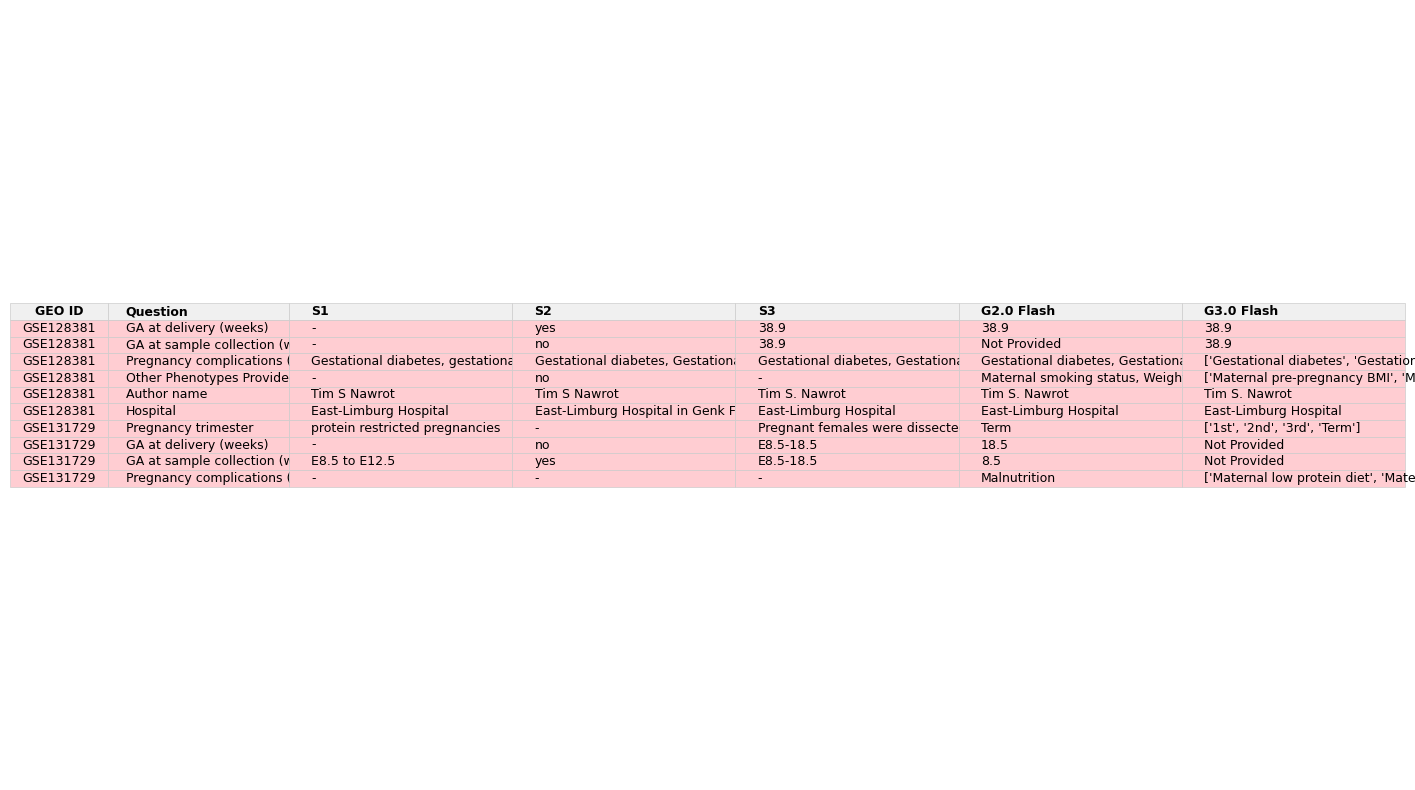

Saved as compare_disagree_top10.png


In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# ── data build ───────────────────────────────────────────────────────────────
NON_YESNO_COMPARE = [TRIMESTER_QUESTION, COUNTRY_QUESTION] + GA_QUESTIONS + LIST_QUESTIONS + [
    "Supervisor/Contact/Corresponding author name",
    "Hospital/Center where samples were collected",
]

rows = []
for geo_id in PAPERS:
    for q in NON_YESNO_COMPARE:
        s_raw, s_norm = [], []
        for sn in ["Set1", "Set2", "Set3"]:
            rv = str(student_sets[sn][geo_id][q]).strip()
            s_raw.append(rv if rv not in {"nan", ""} else "-")
            s_norm.append(str(student_normalized[sn][geo_id][q]))
        g20_raw = get_raw_ai_fast("gemini-2.0-flash", geo_id, q)
        g30_raw = get_raw_ai_fast("gemini-3.0-flash-preview", geo_id, q)
        g20_norm = str(model_results["gemini-2.0-flash"][geo_id].get(q, "Not Provided"))
        g30_norm = str(model_results["gemini-3.0-flash-preview"][geo_id].get(q, "Not Provided"))
        students_agree = len(set(s_norm)) == 1
        s_majority = Counter(s_norm).most_common(1)[0][0]
        g20_match = g20_norm == s_majority
        g30_match = g30_norm == s_majority
        short_q = q.replace(" (1st, 2nd, 3rd, term, premature)", "")
        short_q = short_q.replace(" in data set (list)", " (list)")
        short_q = short_q.replace("Supervisor/Contact/Corresponding author ", "Author ")
        short_q = short_q.replace("Hospital/Center where samples were collected", "Hospital")
        short_q = short_q.replace("Country where samples were collected", "Country")
        rows.append({
            "GEO ID": geo_id,
            "Question": short_q,
            "S1": s_raw[0][:40],
            "S2": s_raw[1][:40],
            "S3": s_raw[2][:40],
            "G2.0 Flash": g20_raw[:40],
            "G3.0 Flash": g30_raw[:40],
            # kept internally for filtering, not shown in figure
            "_students_agree": students_agree,
            "_g20_match": g20_match,
            "_g30_match": g30_match,
        })

compare_df = pd.DataFrame(rows)

print("NON-YES/NO FIELDS: 3 Student Sets vs Gemini 2.0 vs 3.0")
print(f"Total: {len(compare_df)} rows")
print(f"Students disagree among themselves: {(~compare_df['_students_agree']).sum()} rows")
print(f"Gemini 2.0 differs from student majority: {(~compare_df['_g20_match']).sum()} rows")
print(f"Gemini 3.0 differs from student majority: {(~compare_df['_g30_match']).sum()} rows")
print()
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 280)

cols_to_show = ["GEO ID", "Question", "S1", "S2", "S3", "G2.0 Flash", "G3.0 Flash"]
display(compare_df[cols_to_show].head(10))

disagree_mask = (
    (~compare_df["_students_agree"]) |
    (~compare_df["_g20_match"]) |
    (~compare_df["_g30_match"])
)
disagree_compare = compare_df[disagree_mask].reset_index(drop=True)
print(f"\n\nDISAGREEMENTS ONLY — {len(disagree_compare)} rows")
print()
display(disagree_compare[cols_to_show].head(10))


# ── figure ────────────────────────────────────────────────────────────────────
def save_compare_table(df, filename):
    df = df[cols_to_show].reset_index(drop=True)
    col_widths = [0.07, 0.13, 0.16, 0.16, 0.16, 0.16, 0.16]

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns.tolist(),
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#cccccc")
        cell.set_linewidth(0.5)

        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(fontweight="bold", color="black")
        else:
            cell.set_facecolor("#ffcdd2")
            cell.set_text_props(color="black")

        if col in [1, 2, 3, 4, 5, 6]:
            cell.set_text_props(ha="left")
            cell._loc = "left"

    plt.savefig(filename, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved as {filename}")


save_compare_table(compare_df.head(10), "compare_all_top10.png")
save_compare_table(disagree_compare.head(10), "compare_disagree_top10.png")